# M5 forecasting II: a hierarchical count state space model with `numpyro_forecast`

This notebook continues the [M5 baselines notebook](m5_forecasting.html), the port of the three [Pyro M5 Starter Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit) models to `numpyro_forecast`, and asks what a real hierarchical model adds on the same task: the 30,490 daily unit-sales series of the M5 competition (3,049 items in 10 Walmart stores of 3 states), a 28-day horizon, and the weighted scaled CRPS over the 42,840 series of the 12-level hierarchy. On the evaluation window the kit's top-down model scored a WS-CRPS of 0.569, the middle-out model 0.634 and the bottom-up model 0.728, so the top-down model is the one to beat.

The candidate is a single **hierarchical count state space model** of every item in every store, fitted with minibatch SVI. The candidate model has the following components:

- a negative binomial likelihood with item-level dispersion;
- an item intercept centered on the series' level at the forecast origin;
- an end-anchored random walk of the item level over 28-day blocks;
- daily store shocks that sum to zero within every week;
- zero-sum weekday effects per store-department with zero-sum item deviations;
- SNAP and calendar-event effects and yearly seasonality;

all partially pooled across the hierarchy. It is compared with the top-down baseline in the same harness on the three backtest windows of the baselines notebook and on the evaluation window, at every level, with the calibration of the bands alongside the score.

This is the second of the two M5 notebooks; the data loader, the hierarchy, the scoring functions and the baseline are described in the first one and only summarized here.

## Prepare notebook

In [1]:
import warnings
from functools import partial
from time import perf_counter

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
import polars as pl
import preliz as pz
import scipy.sparse as sp
import xarray as xr
from jax import random
from numpyro.infer import SVI, Predictive, Trace_ELBO, init_to_median
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.svi import SVIRunResult

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    evaluate_forecast,
    forecast,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    results_to_dataframe,
)
from numpyro_forecast.datasets import load_m5
from numpyro_forecast.features import fourier_features
from numpyro_forecast.metrics import crps_empirical
from numpyro_forecast.typing import Array, ForecastFn, ForecastModel, Metric

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
numpyro.set_host_device_count(n=4)
rng_key = random.PRNGKey(seed=42)

# The observation site sits under the subsampled `series` plate while its time axis is not
# declared as a plate (`predict` splits it into the observed prefix and the forecast suffix);
# numpyro's model validation warns about the undeclared batch dimension at every trace. The
# baselines notebook explains why the warning is harmless.
warnings.filterwarnings("ignore", message="Missing a plate statement for batch dimension -2")
# The second `plot_lm` call of an overlay reuses the alpha of the first one.
warnings.filterwarnings("ignore", message="When multiple credible intervals are plotted")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Read data

`load_m5()` downloads the [Nixtla mirror](https://github.com/Nixtla/m5-forecasts) of the competition files once and reads them: the daily sales over the training period (`d_1` to `d_1941`) followed by the 28 evaluation days (`d_1942` to `d_1969`), the weekly shelf price of every series repeated over its days (`NaN` when the item was not on the shelf), the series identifiers, the calendar and the official evaluation weights. The [baselines notebook](m5_forecasting.html) describes the files, the hierarchy and the exploratory plots in detail; here the data cells are kept to what the model needs. The calendar carries two event columns; the second one is rare, but one of its five days (Father's Day 2016) falls inside the evaluation window, so both are indexed.

In [2]:
m5 = load_m5()

N_DAYS_TRAIN = 1_941
HORIZON = 28
N_DAYS = N_DAYS_TRAIN + HORIZON
sales = m5.sales
price = m5.price
keys_df = m5.keys
n_series = sales.shape[1]


def is_christmas() -> pl.Expr:
    """Flag December 25, the one day a year every Walmart store is closed."""
    return pl.col("date").dt.month().eq(pl.lit(12)).and_(pl.col("date").dt.day().eq(pl.lit(25)))


def day_of_week_index() -> pl.Expr:
    """Index the weekday from 0 (Monday) to 6 (Sunday)."""
    return pl.col("date").dt.weekday().sub(pl.lit(1))


def event_index(column: str, names: list[str]) -> pl.Expr:
    """Index an event column by its position in ``names``, 0 when there is no event."""
    return pl.col(column).replace_strict(names, list(range(1, len(names) + 1)), default=0)


event_names = sorted(
    set(m5.calendar["event_name_1"].drop_nulls().to_list())
    | set(m5.calendar["event_name_2"].drop_nulls().to_list())
)
calendar_df = (
    m5.calendar.lazy()
    .with_row_index("t")
    .with_columns(
        christmas=is_christmas().cast(pl.Float32),
        dow=day_of_week_index(),
        event_1=event_index("event_name_1", event_names),
        event_2=event_index("event_name_2", event_names),
    )
    .select("t", "date", "dow", "christmas", "event_1", "event_2", "snap_CA", "snap_TX", "snap_WI")
    .collect(engine="streaming")
)

print(f"{n_series} series over {N_DAYS} days, {len(event_names)} event names")

m5.calendar.filter(pl.col("event_name_2").is_not_null()).select(
    "date", "event_name_1", "event_name_2"
)

30490 series over 1969 days, 30 event names


date,event_name_1,event_name_2
date,str,str
2011-04-24,"""OrthodoxEaster""","""Easter"""
2013-05-05,"""OrthodoxEaster""","""Cinco De Mayo"""
2014-04-20,"""Easter""","""OrthodoxEaster"""
2014-06-15,"""NBAFinalsEnd""","""Father's day"""
2016-06-19,"""NBAFinalsEnd""","""Father's day"""


### The hierarchy

The competition scores 42,840 series: the 30,490 items in stores (level 12) and their sums over the 11 coarser groupings. A label and a dense group id per level turn into a sparse `(30,490, 42,840)` summation matrix, so any array of bottom-level values (data or forecast draws) is aggregated to every level with one sparse product. The store, department and store-department ids of every series index the pooled parameters of the model.

In [3]:
LEVELS: dict[str, list[str]] = {
    "Level1": [],
    "Level2": ["state_id"],
    "Level3": ["store_id"],
    "Level4": ["cat_id"],
    "Level5": ["dept_id"],
    "Level6": ["state_id", "cat_id"],
    "Level7": ["state_id", "dept_id"],
    "Level8": ["store_id", "cat_id"],
    "Level9": ["store_id", "dept_id"],
    "Level10": ["item_id"],
    "Level11": ["state_id", "item_id"],
    "Level12": ["item_id", "store_id"],
}


def level_label(columns: list[str]) -> pl.Expr:
    """Label of the aggregate a series belongs to at one level, ``Agg_Level_1/Agg_Level_2``."""
    parts = [pl.col(column) for column in columns] or [pl.lit("Total")]
    if len(parts) == 1:
        parts.append(pl.lit("X"))
    return pl.concat_str(parts, separator="/")


def group_id(label: str) -> pl.Expr:
    """Dense 0-based id of the aggregate named by ``label``, in sorted label order."""
    return pl.col(label).rank("dense").cast(pl.Int64).sub(pl.lit(1))


def add_level_ids(keys: pl.DataFrame) -> pl.DataFrame:
    """Add one label and one group id column per M5 level."""
    return keys.with_columns(
        **{f"{level}_label": level_label(columns) for level, columns in LEVELS.items()}
    ).with_columns(**{level: group_id(f"{level}_label") for level in LEVELS})


def aggregation_matrix(
    hierarchy: pl.DataFrame,
) -> tuple[sp.csr_matrix, list[str], dict[str, slice]]:
    """Sparse ``(n_series, n_aggregates)`` sum matrix over the 12 levels, with labels and slices."""
    rows, cols, labels, slices = [], [], [], {}
    offset = 0

    for level in LEVELS:
        rows.append(np.arange(hierarchy.height))
        cols.append(offset + hierarchy[level].to_numpy())
        level_labels = (
            hierarchy.select(f"{level}_label", level)
            .unique()
            .sort(level)[f"{level}_label"]
            .to_list()
        )
        labels += [f"{level}/{label}" for label in level_labels]
        slices[level] = slice(offset, offset + len(level_labels))
        offset += len(level_labels)

    values = np.ones(hierarchy.height * len(LEVELS), dtype=np.float32)
    matrix = sp.csr_matrix(
        (values, (np.concatenate(rows), np.concatenate(cols))), shape=(hierarchy.height, offset)
    )

    return matrix, labels, slices


hierarchy_df = keys_df.pipe(add_level_ids)
agg_matrix, agg_labels, level_slices = aggregation_matrix(hierarchy_df)
sales_agg = sales @ agg_matrix

# Labels of the stores, departments and store-departments, in the order of their group ids.
store_ids = [
    label.removeprefix("Level3/").removesuffix("/X")
    for label in agg_labels[level_slices["Level3"]]
]
dept_ids = [
    label.removeprefix("Level5/").removesuffix("/X")
    for label in agg_labels[level_slices["Level5"]]
]
group_ids = [label.removeprefix("Level9/") for label in agg_labels[level_slices["Level9"]]]
N_STORES, N_DEPTS, N_GROUPS = len(store_ids), len(dept_ids), len(group_ids)

# The group ids of every series index the pooled parameters inside the model.
state_index = hierarchy_df["Level2"].to_numpy()
store_index = jnp.asarray(hierarchy_df["Level3"].to_numpy(), dtype=jnp.int32)
dept_index = jnp.asarray(hierarchy_df["Level5"].to_numpy(), dtype=jnp.int32)
group_index = jnp.asarray(hierarchy_df["Level9"].to_numpy(), dtype=jnp.int32)

print(
    f"aggregation matrix {agg_matrix.shape}: {N_STORES} stores, {N_DEPTS} departments, "
    f"{N_GROUPS} store-departments"
)

aggregation matrix (30490, 42840): 10 stores, 7 departments, 70 store-departments


## Scoring at every level

The score is the one of the baselines notebook. For a series $s$ at level $\ell$, $c_s$ is the mean CRPS of its 28-day forecast, $w_s$ its share of the dollar sales of the level over the 28 days before the forecast origin and $\sigma_s$ its scale, the mean absolute lag-one difference of the training series after its first nonzero value:

$$
\text{WS-CRPS} = \frac{1}{12} \sum_{\ell=1}^{12} \sum_{s \in \ell} w_s \frac{c_s}{\sigma_s}.
$$

The functions plug into `backtest()`: a `transform` sums the bottom-level draws and the truth to the 42,840 series and `per_window_metrics` returns one weighted scaled CRPS per level for the window's origin. Four coverage metrics come along, the share of series-days inside the central $94\%$ interval of the draws at levels 1, 3, 9 and 12, because a CRPS alone does not say whether a model is sharp or just narrow. The weights need the dollar sales, so the price enters here; it also gives the `saled` flag ("price listed and not Christmas") that the model uses to gate its mean, as the kit's bottom-up model does.

In [4]:
christmas = calendar_df["christmas"].to_numpy()[:N_DAYS]
saled = (~np.isnan(price)).astype(np.float32) * (1.0 - christmas[:, None])
price_filled = np.nan_to_num(price, nan=0.0)


def m5_weights(t1: int) -> np.ndarray:
    """Dollar-sales share of every aggregate over the 28 days before ``t1``, normalized per level."""
    dollars = (sales[t1 - 28 : t1] * price_filled[t1 - 28 : t1]).sum(0) @ agg_matrix
    weights = np.empty_like(dollars)

    for level_slice in level_slices.values():
        weights[level_slice] = dollars[level_slice] / dollars[level_slice].sum()

    return weights


def m5_scales(y: np.ndarray) -> np.ndarray:
    """Mean absolute lag-1 difference of every column of ``y`` over its active period.

    The active period starts at the first nonzero value; the jump from zero on that day is
    excluded, the sum of absolute differences is clamped at one and divided by the number of
    active days minus one (the kit's ``get_metric_scale("pl", ...)``).
    """
    duration, n_columns = y.shape
    active = np.maximum((np.cumsum(y, axis=0) != 0).sum(0), 2)
    start_value = y[duration - active, np.arange(n_columns)]
    lag1_norm = np.abs(np.diff(y, axis=0, prepend=0.0)).sum(0) - np.abs(start_value)
    return np.maximum(lag1_norm, 1.0) / (active - 1)


def aggregate_transform(
    pred: np.ndarray | Array, truth: np.ndarray | Array
) -> tuple[np.ndarray, np.ndarray]:
    """Sum bottom-level draws and truth to the 42,840 aggregates of the 12 M5 levels."""
    n = pred.shape[-1]
    pred_levels = np.asarray(pred, dtype=np.float32).reshape(-1, n) @ agg_matrix
    truth_levels = np.asarray(truth, dtype=np.float32) @ agg_matrix
    return pred_levels.reshape(*pred.shape[:-1], -1), truth_levels


def ws_crps_level(
    pred: Array, truth: Array, *, level_slice: slice, weights: np.ndarray, scales: np.ndarray
) -> Array:
    """Weighted scaled CRPS of one level: weight times mean CRPS over the horizon, over scale."""
    crps = crps_empirical(pred[..., level_slice], truth[..., level_slice]).mean(axis=0)
    return jnp.sum(jnp.asarray(weights) * crps / jnp.asarray(scales))


def coverage_level(pred: Array, truth: Array, *, level_slice: slice, prob: float = 0.94) -> Array:
    r"""Share of the series-days of one level inside the central $94\%$ interval of the draws."""
    tail = (1.0 - prob) / 2.0
    lower, upper = np.quantile(np.asarray(pred[..., level_slice]), [tail, 1.0 - tail], axis=0)
    actual = np.asarray(truth[..., level_slice])
    return jnp.asarray(np.mean((actual >= lower) & (actual <= upper)))


COVERAGE_LEVELS = ["Level1", "Level3", "Level9", "Level12"]


def m5_metrics(t0: int, t1: int, t2: int) -> dict:
    r"""Build the 12 weighted scaled CRPS metrics of a window whose training data ends at ``t1``.

    Four $94\%$ coverage metrics (levels 1, 3, 9 and 12) come along to read the calibration.
    """
    weights = m5_weights(t1)
    scales = m5_scales(sales_agg[:t1])
    metrics: dict[str, Metric] = {
        f"ws_crps_{level}": partial(
            ws_crps_level,
            level_slice=level_slice,
            weights=weights[level_slice],
            scales=scales[level_slice],
        )
        for level, level_slice in level_slices.items()
    }

    for level in COVERAGE_LEVELS:
        metrics[f"coverage_{level}"] = partial(coverage_level, level_slice=level_slices[level])

    return metrics

## Features

The model reads two kinds of inputs. The per-series covariate tensor has two channels stacked with time at axis $-2$: the day index, through which the calendar tables are looked up inside the model, and the `saled` flag, which gates the mean as in the kit. The calendar tables (weekday, SNAP by state, the two event indices and four yearly Fourier harmonics) live outside the tensor, one row per day, so that a subsampled minibatch does not have to carry them. The shelf price is not a feature: a department price elasticity was tried during development and changed nothing (see the model selection below), and a per-item elasticity is unidentified for the many items whose price never moves.

Three constants fix the time bookkeeping: the first backtest origin (day 1,843, the reference day of the windows), the block length of the item random walk (28 days, the competition horizon) and the number of blocks the walk spans (13, one year).

In [5]:
REFERENCE_DAYS = N_DAYS_TRAIN - HORIZON - 2 * 35  # 1,843: the first backtest origin
BLOCK = 28
N_BLOCKS = 13  # one year of 28-day blocks before the origin

The covariate tensor is `(channel, day, series)`: channel 0 the day index (the same for every series), channel 1 the `saled` flag of every series-day.

In [6]:
covariates_np = np.empty((2, N_DAYS, n_series), dtype=np.float32)
covariates_np[0] = np.arange(N_DAYS, dtype=np.float32)[:, None]  # the day index
covariates_np[1] = saled  # price listed and not Christmas
covariates = jnp.asarray(covariates_np)
del covariates_np

print(f"covariates {covariates.shape} (channel, day, series), {covariates.nbytes / 1e9:.2f} GB")

covariates (2, 1969, 30490) (channel, day, series), 0.48 GB


The calendar tables are one row per day and are indexed by the day channel inside the model: the weekday, the SNAP flag of each of the three states, the two event indices (0 for "no event", then the position of the event name) and the yearly Fourier terms. `state_of_store` maps every store to its state, so that the model can pick the SNAP flag of a series' store.

In [7]:
dow_table = jnp.asarray(calendar_df["dow"].to_numpy()[:N_DAYS], dtype=jnp.int32)  # (days,)
snap_table = jnp.asarray(  # (days, state)
    calendar_df.select("snap_CA", "snap_TX", "snap_WI").to_numpy()[:N_DAYS], dtype=jnp.float32
)
event_tables = (  # two (days,) event indices, 0 for no event
    jnp.asarray(calendar_df["event_1"].to_numpy()[:N_DAYS], dtype=jnp.int32),
    jnp.asarray(calendar_df["event_2"].to_numpy()[:N_DAYS], dtype=jnp.int32),
)
N_EVENTS = len(event_names) + 1  # the event names plus "none"

N_HARMONICS = 4
fourier_table = jnp.asarray(  # (days, 2 * harmonics)
    fourier_features(N_DAYS, 365.25, N_HARMONICS), dtype=jnp.float32
)

state_of_store = jnp.asarray(  # (store,): the state of every store, for the SNAP flag
    [state_index[np.argmax(np.asarray(store_index) == s)] for s in range(N_STORES)],
    dtype=jnp.int32,
)

The training counts are the sales times the `saled` flag: the model puts its mean at the floor on the days without a listed price and on Christmas, so the few nonzero sales recorded on such days are set to zero rather than left for the likelihood to explain.

In [8]:
n_zeroed = int((sales * (1 - saled) > 0).sum())

print(f"{n_zeroed} nonzero sales on unlisted or closed days are set to 0 in the training counts")

60 nonzero sales on unlisted or closed days are set to 0 in the training counts


## The model

For item $i$ in store $r(i)$, department $d(i)$ and store-department $j(i)$ (70 groups), on day $t$ with weekday $w(t)$, 28-day block $b(t)$ (counted so that the horizon is one whole block), calendar events $e_1(t)$ and $e_2(t)$ and yearly Fourier terms $\mathbf{f}_t$:

$$
\begin{align*}
y_{i,t} &\sim \text{NegativeBinomial2}\big(\text{saled}_{i,t}\, e^{\eta_{i,t}},\ \phi_i\big), \qquad \log \phi_i \sim \text{Normal}(\log \phi_{j(i)}, \tau_{d(i)}), \\
\eta_{i,t} &= \log m_i + a_{j(i)} + \alpha_i + u_{i,b(t)} + \epsilon_{r(i),t} + s_{j(i),w(t)} + \tilde s_{i,w(t)} + \beta_{j(i)}\,\text{snap}_{r(i),t} + \mathbf{w}_{d(i)}^\top \mathbf{f}_t + \gamma_{d(i),e_1(t)} + \gamma_{d(i),e_2(t)}.
\end{align*}
$$

- **Level at the origin.** $m_i$ is the item's mean sales over its listed days of the last 28 training days (falling back to the last year, then to a floor) and $\alpha_i \sim \text{Normal}(0, \sigma^{\alpha}_{d(i)})$ a partially pooled deviation from it, with a store-department intercept $a_j \sim \text{Normal}(0, 0.3)$ that shifts a whole group at once when the origin level is biased for all its items (for example by the value of the yearly curve at the origin, which the item intercepts would otherwise each have to undo). With the walk anchored at zero on the last training block, $\log m_i + a_{j(i)} + \alpha_i$ is the log level at the forecast origin: the share heuristic of the kit becomes the prior center of a Bayesian item level.
- **Item block walk** $u_{i,b}$: a random walk over the last 13 blocks of 28 days, end-anchored (zero on the last block, earlier blocks minus the innovations that follow them) with a department-level innovation scale $\sigma^{u}_{d}$; the horizon block adds one fresh innovation. This is the local level of a state space model, at the resolution a single item series can support.
- **Weekly store shocks** $\epsilon_{r,t}$: daily shocks shared by every item of a store that sum to zero within each week (`ZeroSumNormal` over the seven days, weeks counted back from the origin), scaled by a store-level $\sigma^{\epsilon}_r$. A zero-sum week cannot absorb a level change, so the shocks carry only the common day-to-day variation of a store; their fresh future weeks give correlated uncertainty to the aggregates.
- **Weekday**: `ZeroSumNormal` effects $s_{j,\cdot}$ per store-department and zero-sum item deviations $\tilde s_{i,\cdot} = \sigma^{s}_{d(i)} z_i$ with $z_i \sim \text{ZeroSumNormal}(1)$ (the distribution does not take a per-item scale).
- **Calendar**: SNAP per store-department, one effect per department and event name (zero for "no event", so $\gamma_{d,e}$ is the lift of event $e$ over an ordinary day) with a shrinkage scale $\sigma^{\gamma}_d$ per department, four yearly harmonics with department-level weights.
- **Likelihood**: negative binomial with an item-level dispersion pooled to the store-department. The log mean is clipped at $\log 2{,}000$; no series sells more than 763 units on a day.

### Priors

The item-level parameters are partially pooled, so the priors that matter are the population scales and the shared effects:

$$
\begin{align*}
\sigma^{\alpha}_d &\sim \text{HalfNormal}(0.5), & \tau_d &\sim \text{HalfNormal}(1), & \sigma^{u}_d &\sim \text{HalfNormal}(0.3), \\
\sigma^{s}_d &\sim \text{HalfNormal}(0.2), & \sigma^{\gamma}_d &\sim \text{HalfNormal}(0.3), & \sigma^{\epsilon}_r &\sim \text{HalfNormal}(0.2), \\
\log \phi_j &\sim \text{Normal}(0, 1), & s_{j,\cdot} &\sim \text{ZeroSumNormal}(0.3), & \beta_j &\sim \text{Normal}(0, 0.3), \\
a_j &\sim \text{Normal}(0, 0.3), & w_{d,k} &\sim \text{Normal}(0, 0.3), & \gamma_{d,e} &\sim \text{Normal}(0, \sigma^{\gamma}_d).
\end{align*}
$$

Everything lives on the log scale of the sales, where 0.3 is a factor of $e^{0.3} \approx 1.35$. The half-normal scales are weakly informative in that unit: the intercept deviations $\sigma^{\alpha}$ get a prior standard deviation of 0.5 (the last-28-day level can be off by a factor of two for an item, but not routinely by ten), the dispersion spread $\tau$ a standard deviation of 1 (item dispersions within a store-department can differ by a factor of $e$), the block-walk innovations 0.3 per 28 days, the item weekday deviations 0.2 (small next to the store-department pattern they refine), the event effects 0.3 (a holiday can halve or double a department) and the store shocks 0.2 (a common daily shock of $\pm 20\%$ is large for a store total). The shared effects have fixed scales because the hierarchy already pools them: a store-department intercept shift of 0.3, a weekday effect of 0.3, a SNAP lift of 0.3, Fourier weights of 0.3 per harmonic and a group log dispersion of 1 around zero (a dispersion of 1 is a geometric Poisson-Gamma mixture with variance $m + m^2$). The prior predictive check of the focus items below shows what these priors allow before the data speak. The figure shows the half-normal scales, with the fixed Normal(0, 0.3) of the shared effects for comparison.

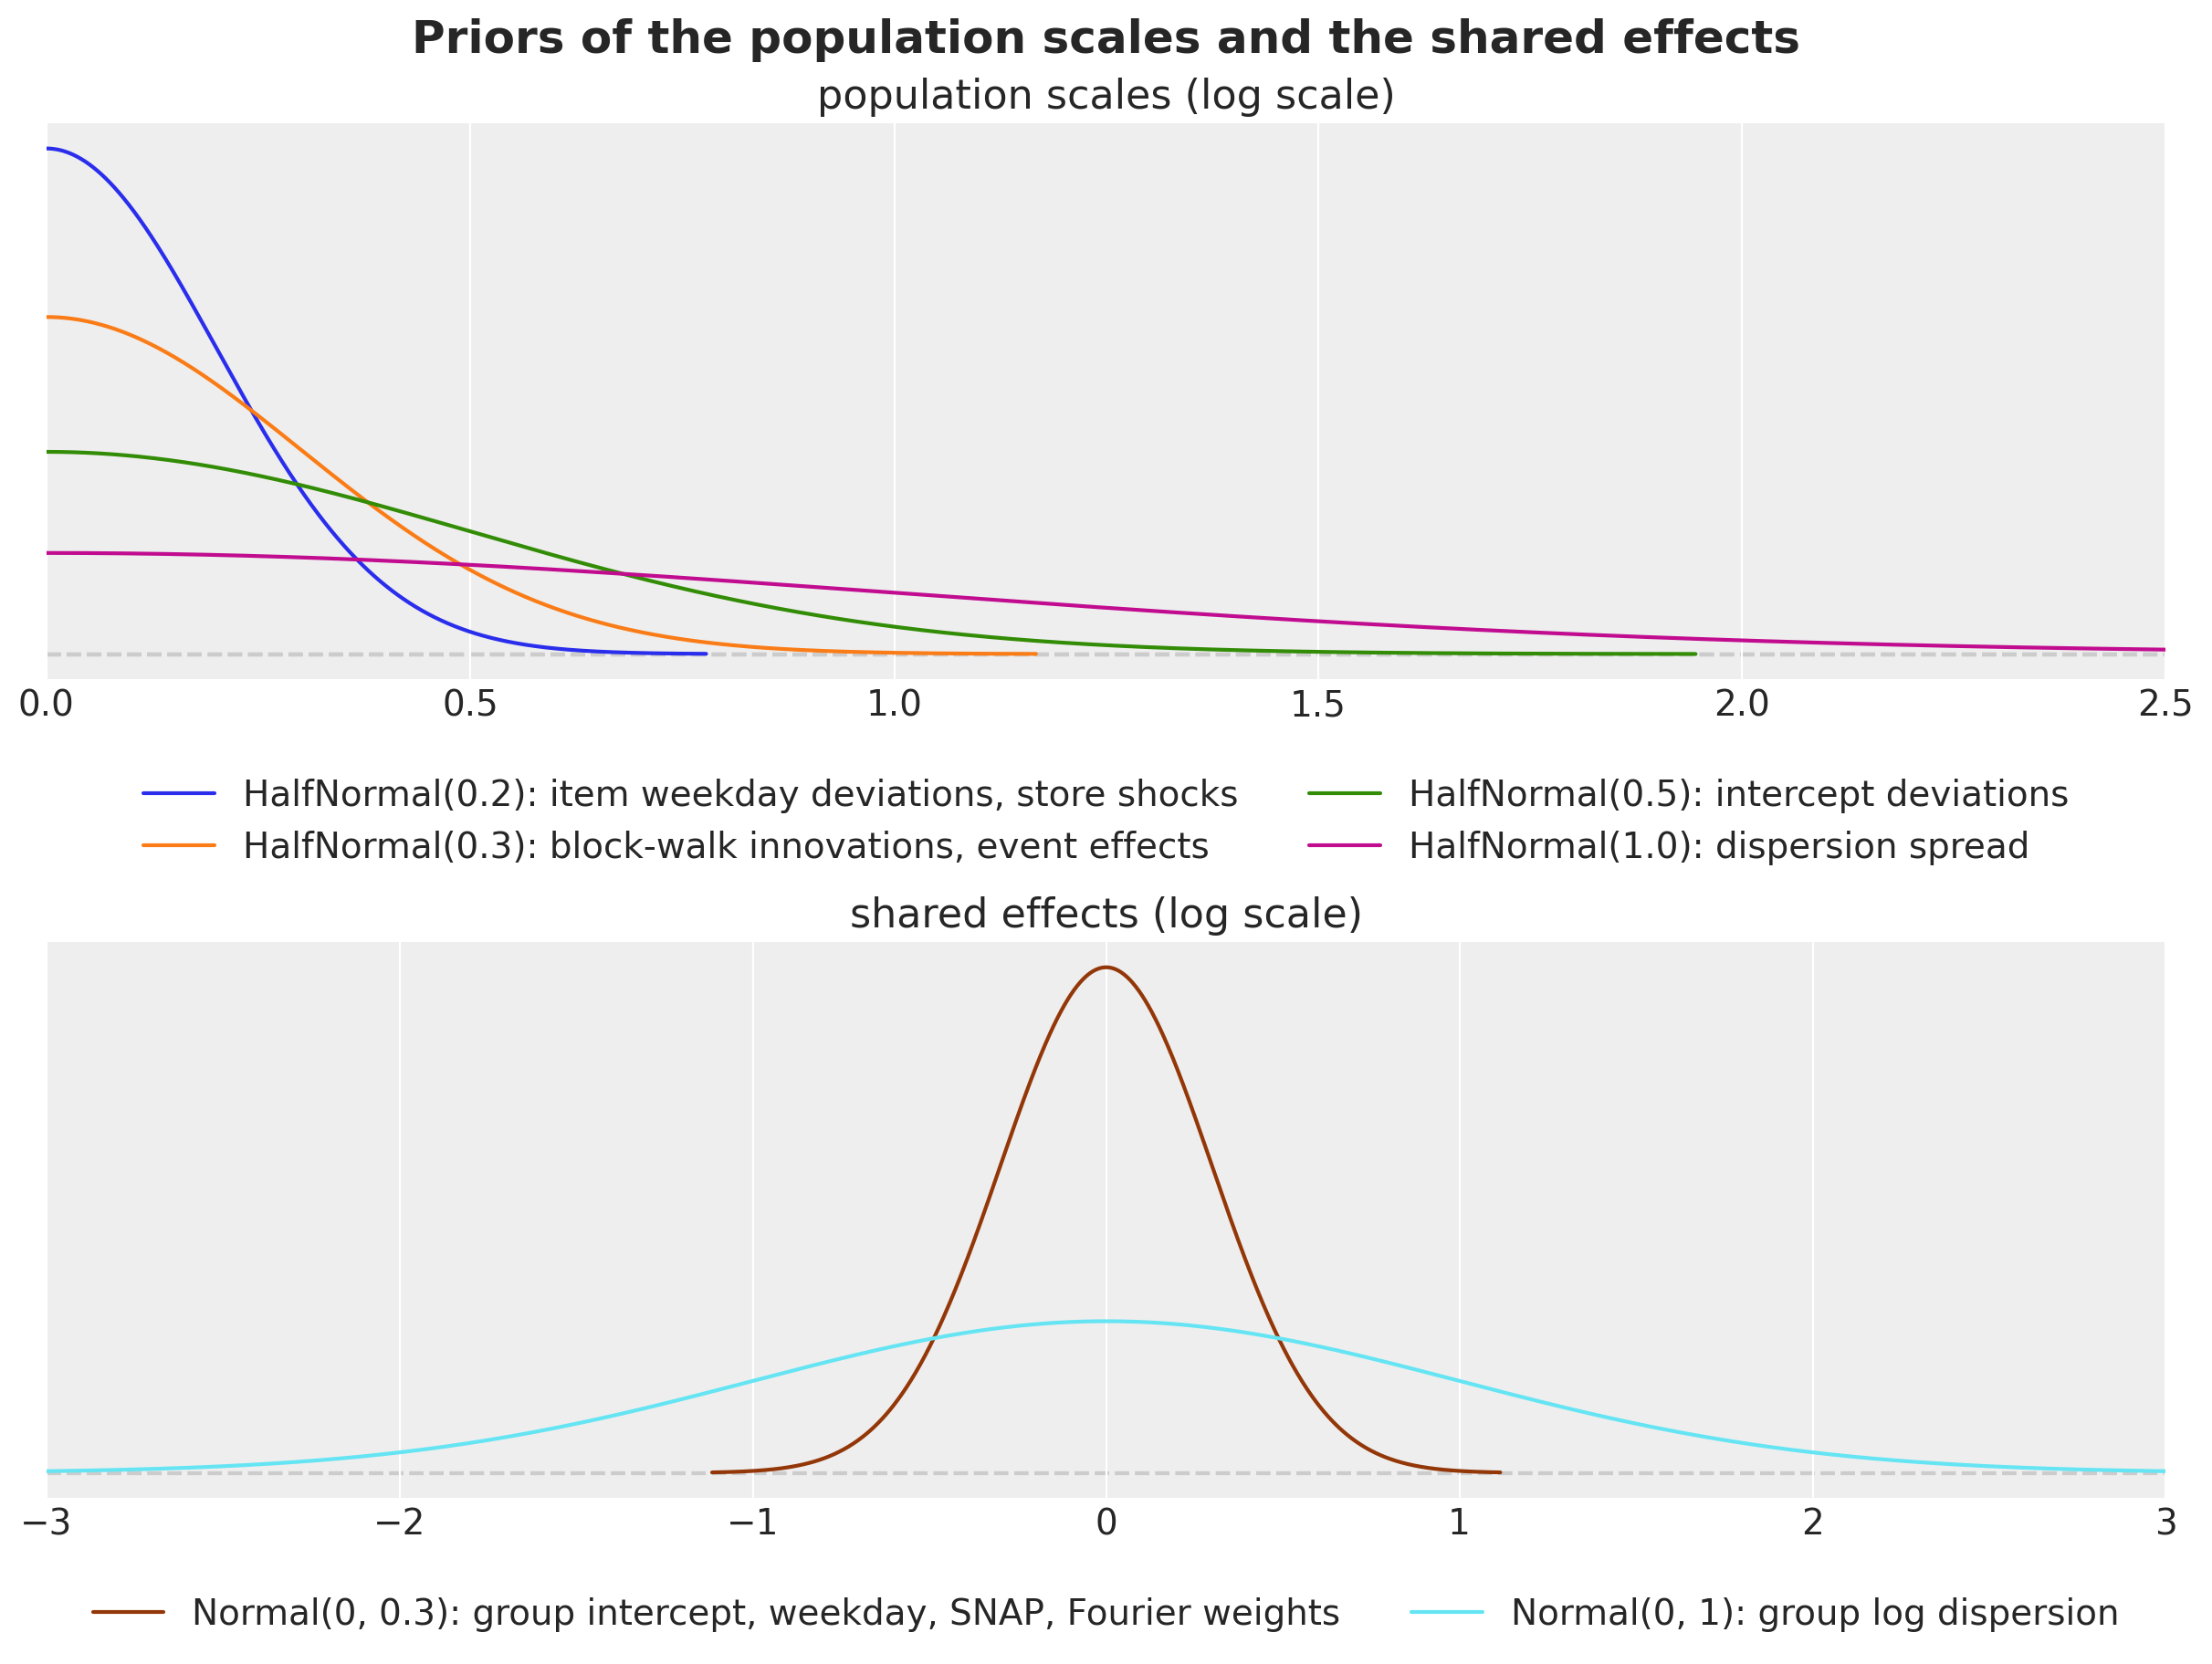

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9), layout="constrained")

# Top: the half-normal priors of the population scales, one color per scale.
for scale, color, label in [
    (0.2, "C0", "item weekday deviations, store shocks"),
    (0.3, "C1", "block-walk innovations, event effects"),
    (0.5, "C2", "intercept deviations"),
    (1.0, "C3", "dispersion spread"),
]:
    pz.HalfNormal(scale).plot_pdf(ax=axes[0], color=color, legend=None)
    axes[0].lines[-1].set_label(f"HalfNormal({scale}): {label}")

axes[0].set(title="population scales (log scale)", xlim=(0, 2.5))
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)

# Bottom: the fixed priors of the shared effects.
pz.Normal(0, 0.3).plot_pdf(ax=axes[1], color="C4", legend=None)
axes[1].lines[-1].set_label("Normal(0, 0.3): group intercept, weekday, SNAP, Fourier weights")
pz.Normal(0, 1).plot_pdf(ax=axes[1], color="C5", legend=None)
axes[1].lines[-1].set_label("Normal(0, 1): group log dispersion")
axes[1].set(title="shared effects (log scale)", xlim=(-3, 3))
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=2)
fig.suptitle(
    "Priors of the population scales and the shared effects", fontsize=18, fontweight="bold"
);

### Why these components

The model was built up one component at a time during development, with the same code, on a selection window whose forecast origin is day 1,878 (250 draws; a second SVI seed of one variant moved the score by 0.002). The figure is the model selection ladder that chose the components, from the literal scores of those runs; it is not re-run in this notebook. The last rung is the model of this notebook. Two details were changed afterwards without moving its score: the event effects are now the lift over an ordinary day (the selection runs carried a free "no event" effect per department, which acted as a department intercept; that role now belongs to the explicit store-department intercept $a_j$, and the score on this window is 0.514 either way), and the store-shock prior was widened from a half-normal scale of 0.05 to 0.2 (the posterior scales do not move, 0.07 to 0.11 under both).

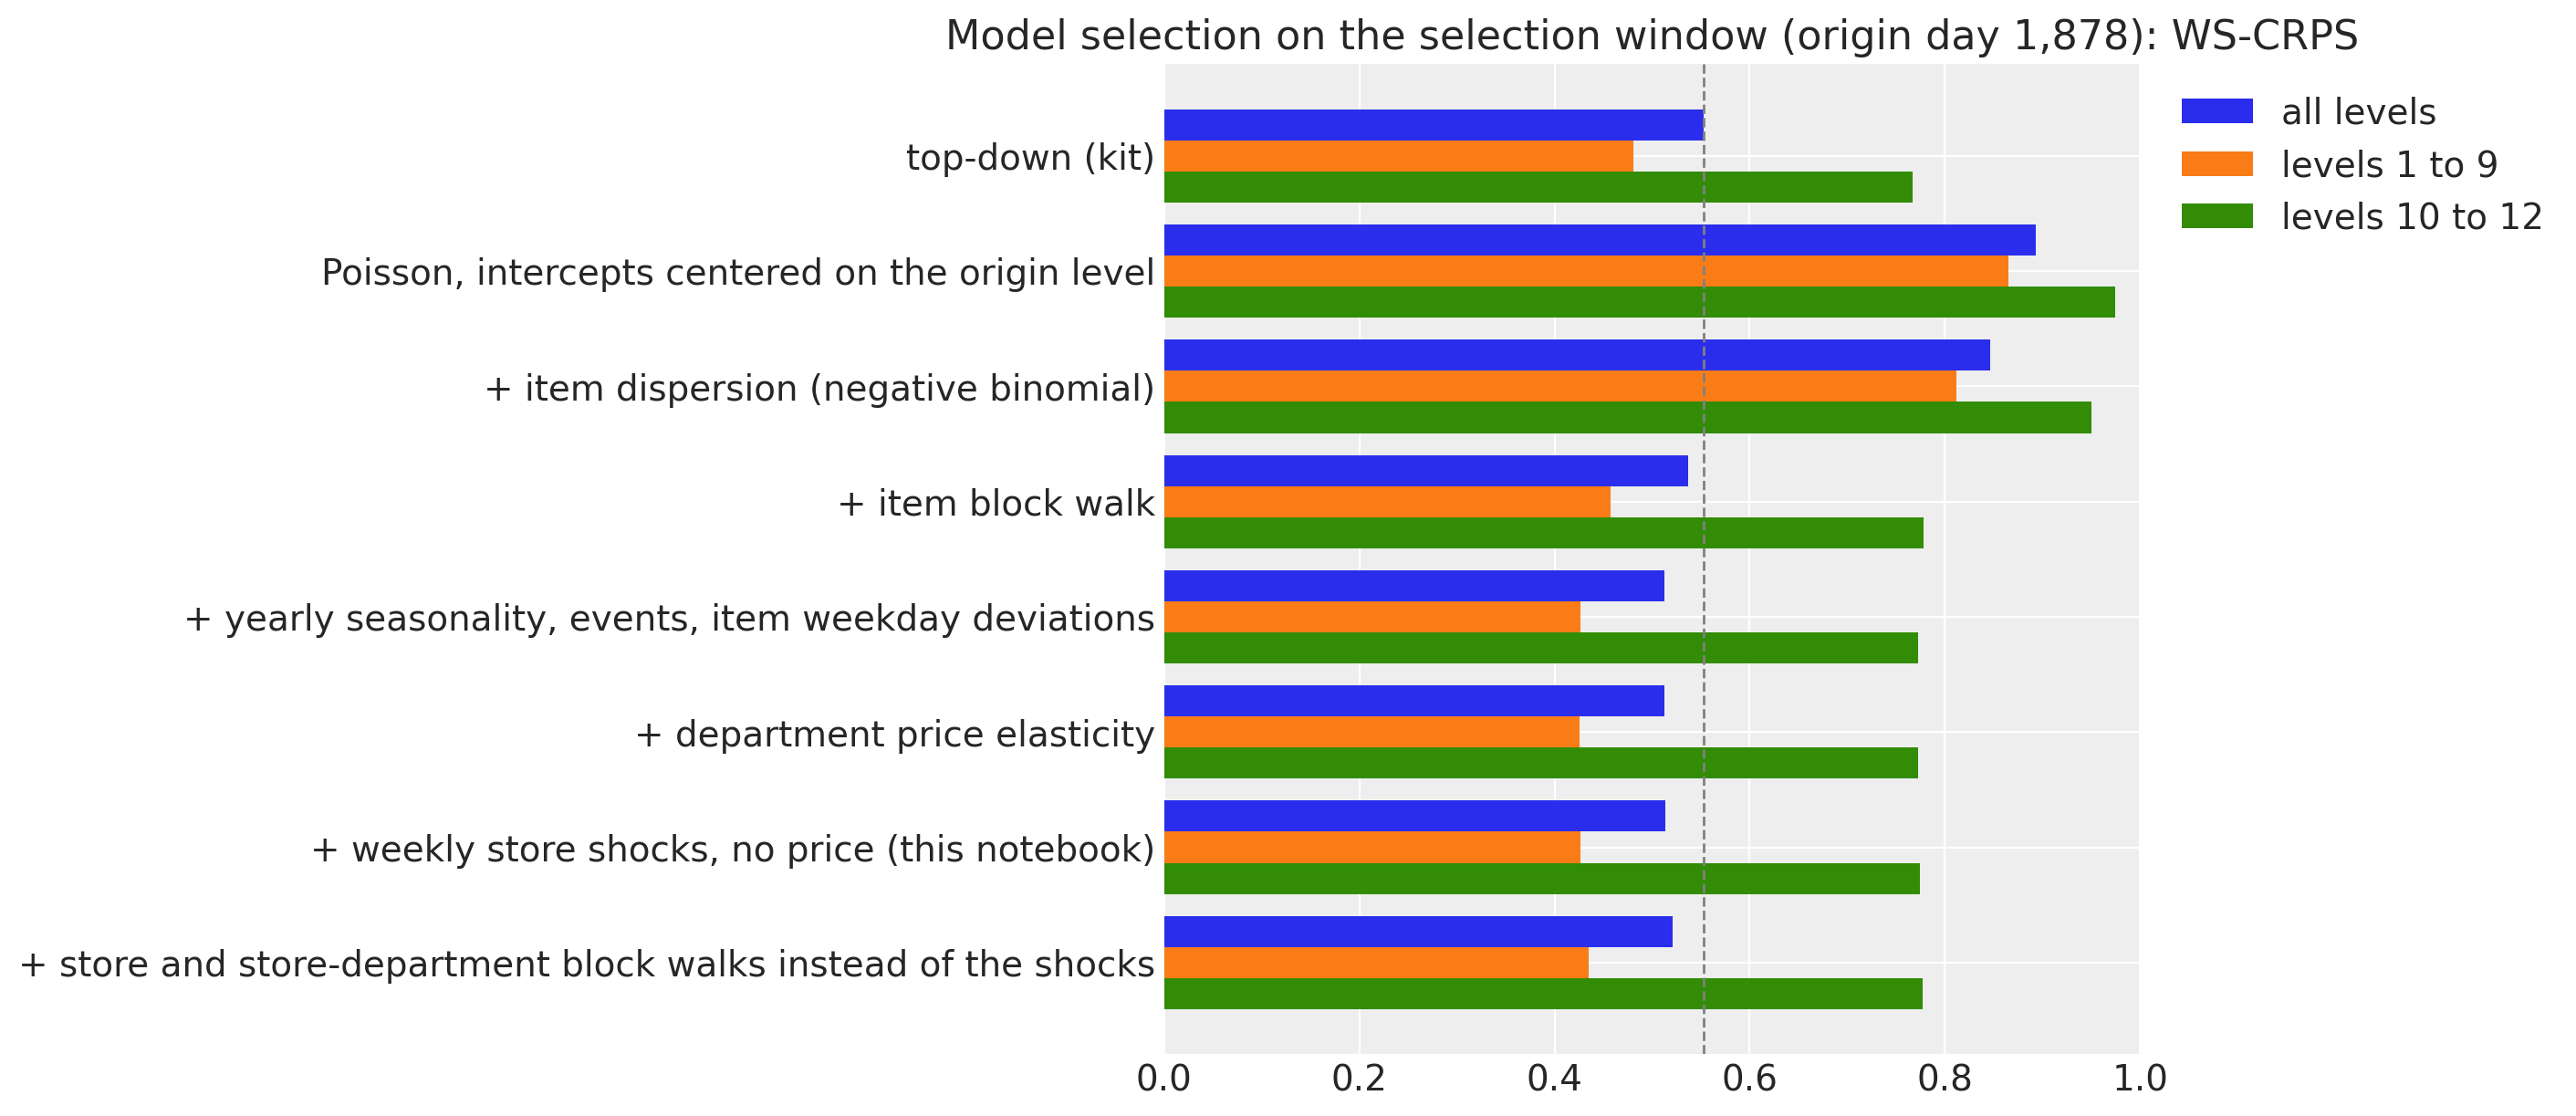

In [10]:
ladder = pl.DataFrame(
    {
        "model": [
            "top-down (kit)",
            "Poisson, intercepts centered on the origin level",
            "+ item dispersion (negative binomial)",
            "+ item block walk",
            "+ yearly seasonality, events, item weekday deviations",
            "+ department price elasticity",
            "+ weekly store shocks, no price (this notebook)",
            "+ store and store-department block walks instead of the shocks",
        ],
        "all levels": [0.553, 0.893, 0.846, 0.537, 0.513, 0.513, 0.514, 0.521],
        "levels 1 to 9": [0.481, 0.865, 0.812, 0.457, 0.427, 0.426, 0.427, 0.435],
        "levels 10 to 12": [0.767, 0.975, 0.950, 0.778, 0.773, 0.773, 0.774, 0.777],
    }
)

fig, ax = plt.subplots(figsize=(14, 6), layout="constrained")
y = np.arange(ladder.height)
height = 0.27

for k, column in enumerate(["all levels", "levels 1 to 9", "levels 10 to 12"]):
    ax.barh(y + (k - 1) * height, ladder[column].to_numpy(), height, label=column)

ax.set_yticks(y, ladder["model"].to_list())
ax.invert_yaxis()
ax.axvline(0.553, color="gray", ls="--", lw=1)
ax.set(title="Model selection on the selection window (origin day 1,878): WS-CRPS", xlim=(0, 1.0))
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0));

Here are three observations:

- **The block walk is the component that makes the item model work.** Without a level process, a two-year intercept is the wrong level for most items and the model loses to the baseline (the dashed line) by a wide margin. Yearly seasonality, events and item weekday deviations buy the next 0.024, almost all at the aggregate levels.
- **Shared level processes and the price add nothing.** The price elasticity changes nothing, and shared block walks at the store and store-department level cost 0.007: what a store's level does over 13 blocks is already in its items.
- **The weekly shocks are for calibration.** They do not move the CRPS, but on the selection window the $94\%$ coverage at level 1 went from 0.54 to 0.68, at level 3 from 0.70 to 0.95 and at level 9 from 0.81 to 0.90, with the items unchanged. They are kept because a hierarchical forecast that is right on average but wrong about its own uncertainty at the store level is not a state space model, and the backtest below reports the coverage so the reader can judge.

### The model function

The model is one function of `(covariates, data)` on `Horizon.from_data` and `predict()`. The item-level sites sit inside the `series` plate, which the guide subsamples with `create_plates` (1,500 series per step); `numpyro.subsample` picks the matching columns of the data, the covariates, the index arrays and the origin levels, and the observed log density is scaled by $30{,}490 / 1{,}500$. The block and week sites use explicit plates at `dim=-2` instead of `innovations()`, because `AutoNormal` keeps one size per plate name and the daily `time` plate is already taken by `predict()`. With `forecast_only=True` the same function evaluates the item terms over the horizon rows only and exposes the horizon mean and dispersion as deterministic sites: that is how the notebook draws the 30,490-series forecast, because the `NegativeBinomial2` sampler behind `forecast()` (a Gamma and a Poisson draw in JAX) costs minutes per window on this CPU where NumPy needs seconds. `forecast()` itself is used on the seven focus items for the plots.

Two helpers hold the state space components. `block_walk` samples the 12 innovations of the training blocks under a `blocks` plate, accumulates them backwards so that the last training block is zero, and adds one fresh innovation for the horizon block when the horizon is open. `weekly_shocks` samples one `ZeroSumNormal` week per row under a `weeks` plate, with the weeks counted back from the origin so that the last training week ends there, and fresh weeks for the horizon.

In [11]:
SUBSAMPLE_SIZE = 1_500
HISTORY_DAYS = 730  # the model trains on the last two years before the forecast origin
MAX_LOG_MEAN = float(np.log(2_000.0))  # no series sells more than 763 units on a day


def block_index(h: Horizon) -> Array:
    """Index of the 28-day block of every day, counted so that the horizon is block ``N_BLOCKS``.

    The last training block ends at the forecast origin; days more than ``N_BLOCKS`` blocks
    before the origin share block 0.
    """
    t = jnp.arange(h.duration)
    return jnp.clip((t - h.t_obs) // BLOCK + N_BLOCKS, 0, N_BLOCKS)


def block_walk(name: str, scale: Array, h: Horizon) -> Array:
    """Random walk over 28-day blocks that is zero on the last training block.

    Earlier blocks are minus the innovations that follow them, so the intercepts carry the
    level at the origin; when forecasting, one more innovation moves the horizon block. The
    site is sampled under a ``blocks`` plate at ``dim=-2`` and inherits the enclosing
    (subsampled) series plate.
    """
    # (blocks - 1, series): the innovation between consecutive training blocks.
    with numpyro.plate(f"{name}_blocks", N_BLOCKS - 1, dim=-2):
        drift = numpyro.sample(name, dist.Normal(0.0, scale))

    # (blocks, series): block k is minus the sum of the innovations after it, the last is 0.
    walk = jnp.concatenate(
        [-jnp.flip(jnp.cumsum(jnp.flip(drift, 0), 0), 0), jnp.zeros_like(drift[:1])]
    )

    if h.future > 0:
        with numpyro.plate(f"{name}_future_blocks", 1, dim=-2):
            future = numpyro.sample(f"{name}_future", dist.Normal(0.0, scale))

        walk = jnp.concatenate([walk, future], axis=0)

    return walk


def weekly_shocks(name: str, scale: Array, h: Horizon, size: int) -> Array:
    """Daily shocks that sum to zero within every week, one week per row.

    A zero-sum week cannot absorb a level change, so the shocks carry only the common
    day-to-day variation of the series that share them; the horizon gets fresh weeks.
    """
    # (weeks, size, 7): one zero-sum week per row; the first week may be partial.
    n_weeks = -(-h.t_obs // 7)

    with numpyro.plate(f"{name}_weeks", n_weeks, dim=-2):
        shock = numpyro.sample(name, dist.ZeroSumNormal(1.0, event_shape=(7,)))

    if h.future > 0:
        with numpyro.plate(f"{name}_future_weeks", (h.future + 6) // 7, dim=-2):
            future = numpyro.sample(f"{name}_future", dist.ZeroSumNormal(1.0, event_shape=(7,)))

        shock = jnp.concatenate([shock, future], axis=0)

    # Scale per series, lay the weeks out as consecutive days: (weeks * 7, size).
    days = jnp.transpose(scale[:, None] * shock, (0, 2, 1)).reshape(-1, size)

    # Drop the leading days of the partial first week so that the weeks end at the origin.
    return days[n_weeks * 7 - h.t_obs :][: h.duration]


def make_model(
    level_at_origin: Array,
    *,
    store_index: Array = store_index,
    group_index: Array = group_index,
    dept_index: Array = dept_index,
    forecast_only: bool = False,
) -> ForecastModel:
    """Build the hierarchical negative binomial state space model of the M5 series.

    ``level_at_origin`` is the log of every series' mean sales over the last 28 listed
    training days: the prior center of the item intercepts, which the end-anchored walk
    makes the level at the forecast origin. With ``forecast_only=True`` the item-level terms
    are evaluated over the horizon rows only and exposed as the deterministic sites
    ``mean_future`` and ``concentration`` instead of the likelihood, which is how the
    notebook draws the 30,490-series forecast.
    """
    n_series = store_index.shape[0]

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        t_index = covariates[0, :, 0].astype(jnp.int32)  # (days,): the calendar row of each day
        rows = slice(h.t_obs, None) if forecast_only else slice(None)
        dow = dow_table[t_index][rows]  # (rows,)

        # Department-level population scales and shared effects: (dept,) each, the Fourier
        # weights (dept, 2 * harmonics) and the event effects (dept, events).
        with numpyro.plate("dept", N_DEPTS):
            sigma_alpha = numpyro.sample("sigma_alpha", dist.HalfNormal(0.5))
            tau_phi = numpyro.sample("tau_phi", dist.HalfNormal(1.0))
            sigma_walk = numpyro.sample("sigma_walk", dist.HalfNormal(0.3))
            sigma_item_dow = numpyro.sample("sigma_item_dow", dist.HalfNormal(0.2))
            w_fourier = numpyro.sample(
                "w_fourier", dist.Normal(0.0, 0.3).expand([2 * N_HARMONICS]).to_event(1)
            )
            sigma_event = numpyro.sample("sigma_event", dist.HalfNormal(0.3))
            gamma_named = numpyro.sample(
                "gamma_event",
                dist.Normal(0.0, sigma_event[:, None]).expand([N_DEPTS, N_EVENTS - 1]).to_event(1),
            )

        # Index 0 of the event tables is "no event": its effect is zero by construction.
        gamma_event = jnp.concatenate([jnp.zeros((N_DEPTS, 1)), gamma_named], axis=1)

        # Store-level shock scales (store,) and the zero-sum weekly shocks (rows, store).
        with numpyro.plate("store", N_STORES):
            store_shock_scale = numpyro.sample("store_shock_scale", dist.HalfNormal(0.2))
            store_shock = weekly_shocks("store_shock", store_shock_scale, h, N_STORES)

        # Store-department effects, (group,) each except the weekday pattern (group, 7): log
        # dispersion, weekday, SNAP and the intercept shift of the group.
        with numpyro.plate("group", N_GROUPS):
            log_phi_group = numpyro.sample("log_phi_group", dist.Normal(0.0, 1.0))
            seasonal_group = numpyro.sample(
                "seasonal_group", dist.ZeroSumNormal(0.3, event_shape=(7,))
            )
            snap_group = numpyro.sample("snap_group", dist.Normal(0.0, 0.3))
            alpha_group = numpyro.sample("alpha_group", dist.Normal(0.0, 0.3))

        block = block_index(h)[rows]  # (rows,)

        # Item-level sites and the likelihood, under the plate the guide subsamples.
        with numpyro.plate("series", n_series):
            # (channel, days, n), (days, n) and (n,) each: the minibatch columns.
            batch = numpyro.subsample(covariates, event_dim=0)
            y = None if data is None else numpyro.subsample(data, event_dim=0)
            store = numpyro.subsample(store_index, event_dim=0)
            group = numpyro.subsample(group_index, event_dim=0)
            dept = numpyro.subsample(dept_index, event_dim=0)
            offset = numpyro.subsample(level_at_origin, event_dim=0)

            # Item intercept around the origin level, item log dispersion around its group.
            alpha = offset + numpyro.sample("alpha", dist.Normal(0.0, sigma_alpha[dept]))
            log_phi = numpyro.sample("log_phi", dist.Normal(log_phi_group[group], tau_phi[dept]))

            # (n, 7): zero-sum weekday deviations of every item, scaled by its department.
            item_dow = sigma_item_dow[dept][:, None] * numpyro.sample(
                "item_dow", dist.ZeroSumNormal(1.0, event_shape=(7,))
            )

            # The log mean, (rows, n), one term at a time: level, group shift and walk, store shocks,
            # weekday, SNAP, yearly harmonics and events.
            eta = alpha + alpha_group[group] + block_walk("item_walk", sigma_walk[dept], h)[block]
            eta = eta + store_shock[rows][:, store]
            eta = eta + seasonal_group[group][:, dow].T + item_dow[:, dow].T
            eta = eta + snap_group[group] * snap_table[t_index][rows][:, state_of_store[store]]
            eta = eta + fourier_table[t_index][rows] @ w_fourier[dept].T

            for event_table in event_tables:
                eta = eta + gamma_event[dept][:, event_table[t_index][rows]].T

            # The saled flag gates the mean; the floor keeps the likelihood finite.
            mean = batch[1][rows] * jnp.exp(jnp.clip(eta, -12.0, MAX_LOG_MEAN)) + 1e-6
            concentration = jnp.exp(log_phi)

            if forecast_only:
                numpyro.deterministic("mean_future", mean)
                numpyro.deterministic("concentration", concentration)
            else:
                predict(
                    Horizon.from_data(batch, y),
                    lambda m: dist.NegativeBinomial2(m, concentration),
                    mean,
                )

    return model


def create_series_plates(covariates: Array, data: Array | None = None) -> numpyro.plate:
    """Subsample the series plate in the guide; the model replays the same indices."""
    return numpyro.plate("series", n_series, subsample_size=SUBSAMPLE_SIZE)

## Prior predictive check

Before any fit, we check what the priors allow. The check needs the one input the model takes besides the data, the origin levels $\log m_i$: `recent_level` computes them as the mean sales of every series over its listed days of the last 28 training days, with the fallbacks described above.

In [12]:
def recent_level(train_counts: Array, train_saled: Array, days: int = BLOCK) -> Array:
    """Log of the mean sales of every series over its listed days of the last ``days`` days.

    Series with no listed day in that window fall back to the last 13 blocks (a year); series
    with no listed day at all get the floor.
    """
    listed_recent = train_saled[-days:].sum(0)
    mean_recent = train_counts[-days:].sum(0) / jnp.maximum(listed_recent, 1.0)
    listed_year = train_saled[-N_BLOCKS * BLOCK :].sum(0)
    mean_year = train_counts[-N_BLOCKS * BLOCK :].sum(0) / jnp.maximum(listed_year, 1.0)
    mean = jnp.where(listed_recent > 0, mean_recent, jnp.where(listed_year > 0, mean_year, 0.0))

    return jnp.log(mean + 0.05)

The arrays of the evaluation window are built here, because the prior predictive check and, later, the final fit and the backtest all use them: the last two years of training data, their counts, the origin levels of the last 28 training days and the model instance centered on them.

In [13]:
sales_train = jnp.asarray(sales[:N_DAYS_TRAIN])
covariates_final = covariates[:, N_DAYS_TRAIN - HISTORY_DAYS :]
counts_final = jnp.rint(sales_train[-HISTORY_DAYS:] * covariates_final[1, :HISTORY_DAYS]).astype(
    jnp.int32
)
level_final = recent_level(counts_final, covariates_final[1, :HISTORY_DAYS])
final_model = make_model(level_final)

The check is run on seven focus items, the best seller of each department in store CA_1 over the last training year: the same seven as in the baselines notebook, where the kit's bottom-up model missed their level. A seven-series instance of the model (the model is built from the group ids and origin levels of the series it covers, so any subset is an instance) gives the prior predictive through `Predictive`.

In [14]:
dates = calendar_df["date"].to_numpy()[:N_DAYS]
date_num = np.asarray(mdates.date2num(dates.astype("datetime64[s]").astype(object)))
split_date = date_num[N_DAYS_TRAIN]
plot_start = N_DAYS_TRAIN - 16 * 7  # the last sixteen training weeks, the window of every zoom

last_year_sales = sales[N_DAYS_TRAIN - 365 : N_DAYS_TRAIN].sum(0)
focus_df = (
    hierarchy_df.with_row_index("n")
    .with_columns(last_year=pl.Series(last_year_sales))
    .filter(pl.col("store_id").eq(pl.lit("CA_1")))
    .sort("last_year", descending=True)
    .group_by("dept_id", maintain_order=True)
    .head(1)
    .sort("dept_id")
)
focus_index = focus_df["n"].to_numpy()
focus_labels = focus_df["id"].to_list()

focus_model = make_model(
    level_final[focus_index],
    store_index=store_index[focus_index],
    group_index=group_index[focus_index],
    dept_index=dept_index[focus_index],
)
covariates_focus = covariates_final[:, :, focus_index]

`plot_series_panel` is the faceted band plot of the baselines notebook: one panel per series, the in-sample bands in blue, the forecast bands in orange and the observed series in black, with the $94\%$ and $50\%$ HDIs.

In [15]:
HDI_PROBS = (0.94, 0.5)
HDI_ALPHAS = (0.3, 0.6)


def hdi_label(prob: float) -> str:
    r"""Legend label of an HDI band, for example ``$94\%$ HDI``."""
    return rf"${prob:.0%}$ HDI".replace("%", r"\%")


def plot_series_panel(
    train_draws: np.ndarray | Array | None,
    test_draws: np.ndarray | Array,
    truth: np.ndarray,
    labels: list[str],
    x_train: np.ndarray,
    x_test: np.ndarray,
    *,
    ylabel: str,
    suptitle: str,
    col_wrap: int = 2,
    figsize: tuple[float, float] = (15.0, 10.0),
    group: str = "posterior_predictive",
) -> None:
    """Facet the predictive bands of a few series over a window, with the observed series.

    ``train_draws`` (in-sample, blue) may be ``None``; ``test_draws`` (forecast, orange) are
    always drawn. ``truth`` covers ``x_train`` followed by ``x_test``.
    """
    visuals = {
        "ci_band": {"color": "C0"},
        "observed_scatter": False,
        "pe_line": False,
        "xlabel": False,
        "ylabel": False,
    }

    # First `plot_lm` call: the in-sample bands (blue), or the forecast bands (orange) when
    # there is no in-sample window. It creates the facet grid.
    first_draws, first_x = (test_draws, x_test) if train_draws is None else (train_draws, x_train)
    pc = az.plot_lm(
        predictions_to_datatree(
            np.asarray(first_draws, dtype=np.float32), first_x, labels, group=group
        ),
        y="obs",
        x="t",
        plot_dim="time",
        group=group,
        ci_kind="hdi",
        ci_prob=HDI_PROBS,
        smooth=False,
        col_wrap=col_wrap,
        visuals=visuals if train_draws is not None else {**visuals, "ci_band": {"color": "C1"}},
        aes={"alpha": ["prob"]},
        alpha=HDI_ALPHAS,
        figure_kwargs={"figsize": figsize},
    )

    # The legend handles are the band artists of the first panel; the second `plot_lm` call
    # replaces them in `pc.viz`, so the in-sample ones are collected before it runs.
    handles = []

    if train_draws is not None:
        for prob in HDI_PROBS:
            band = pc.viz["ci_band"]["t"].sel(series=labels[0], prob=prob).item()
            band.set_label(f"in-sample {hdi_label(prob)}")
            handles.append(band)

        # Second call on the same grid: the forecast bands after the in-sample ones.
        az.plot_lm(
            predictions_to_datatree(
                np.asarray(test_draws, dtype=np.float32), x_test, labels, group=group
            ),
            y="obs",
            x="t",
            plot_dim="time",
            group=group,
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=HDI_PROBS,
            smooth=False,
            visuals={**visuals, "ci_band": {"color": "C1"}},
        )

    band_prefix = "forecast " if train_draws is not None else ""

    for prob in HDI_PROBS:
        band = pc.viz["ci_band"]["t"].sel(series=labels[0], prob=prob).item()
        band.set_label(f"{band_prefix}{hdi_label(prob)}")
        handles.append(band)

    # The observed series over both windows, mapped onto every facet.
    x_all = np.concatenate([x_train, x_test]) if train_draws is not None else x_test
    truth_da = xr.DataArray(
        np.asarray(truth)[-len(x_all) :],
        dims=["time", "series"],
        coords={"time": x_all, "series": labels},
    ).rename("t")
    x_da = xr.DataArray(x_all, dims=["time"], coords={"time": x_all})
    pc.map(
        az.visuals.line_xy,
        "truth",
        data=truth_da,
        x=x_da,
        ignore_aes=pc.aes_set,
        color="black",
        lw=1,
    )

    # Panel titles and compact date ticks.
    for label in labels:
        ax = pc.get_target("t", {"series": label})
        ax.set_title(label, fontsize=11)
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    # One legend for the whole figure, below the panels.
    truth_line = pc.viz["truth"]["t"].sel(series=labels[0]).item()
    truth_line.set_label("observed")
    fig = pc.viz["figure"].item()
    fig.legend(
        handles=[*handles, truth_line],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.0),
        ncols=len(handles) + 1,
    )
    fig.supylabel(ylabel)
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=1.02)

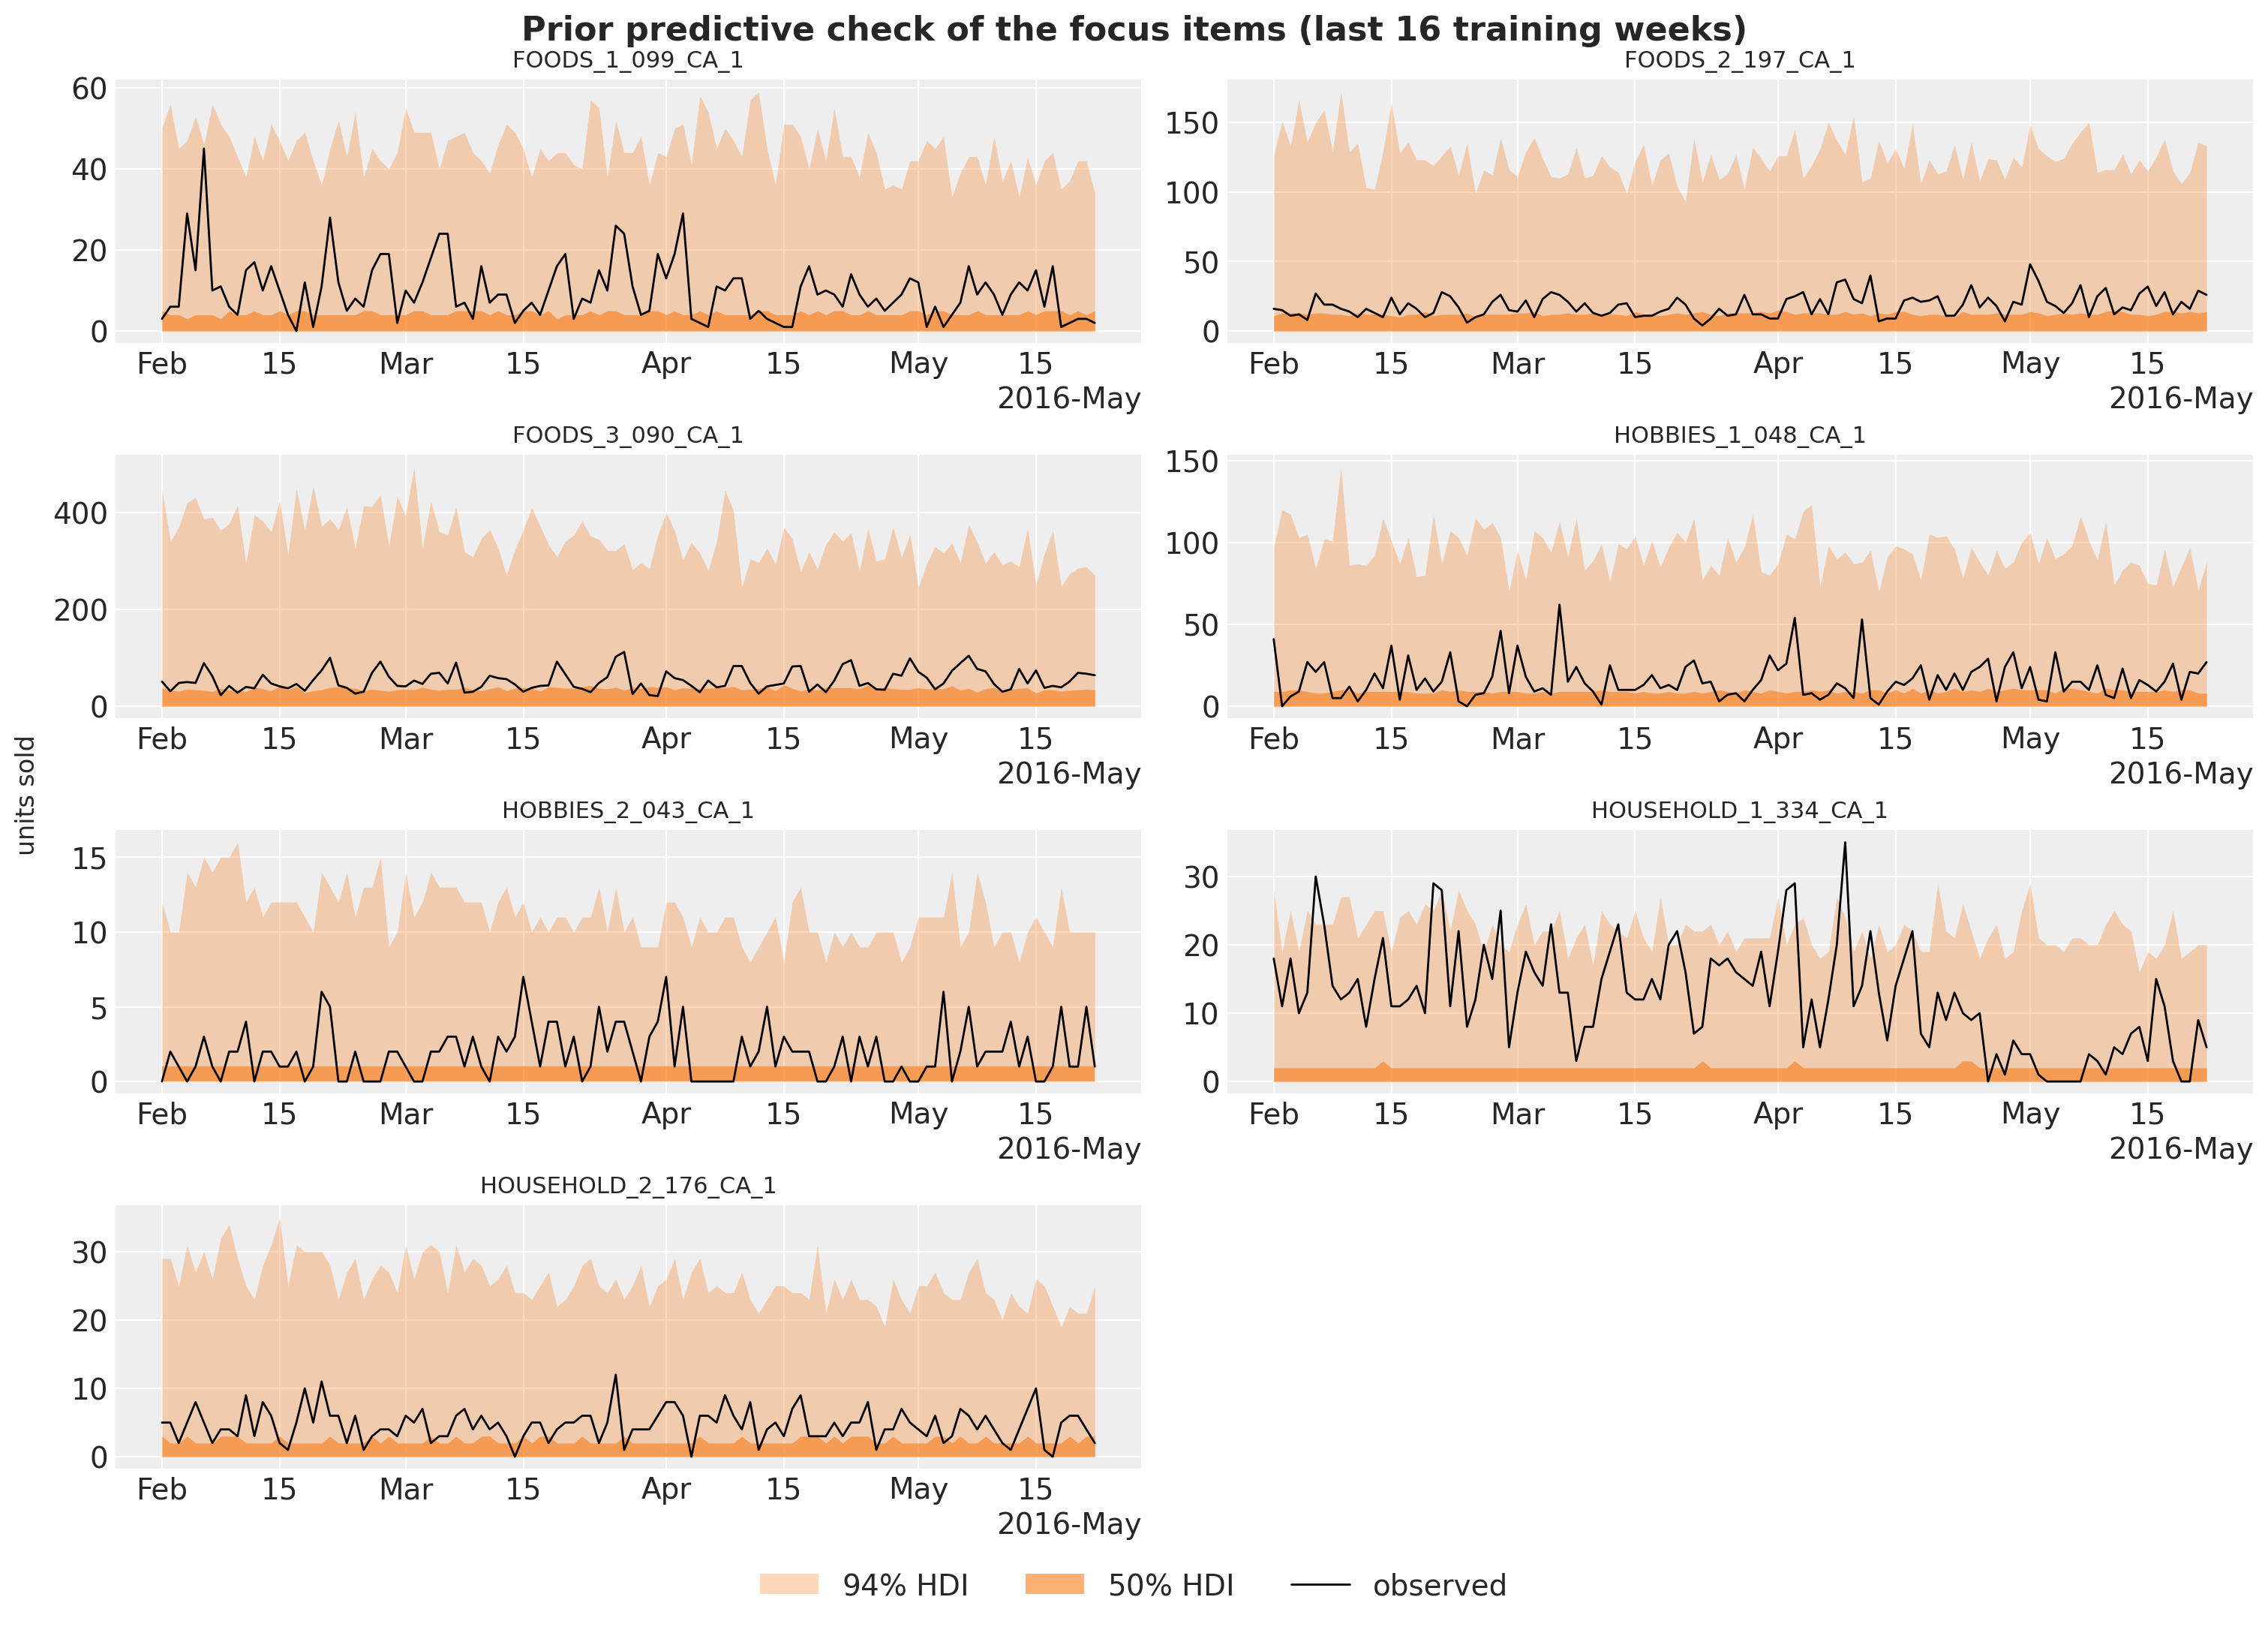

In [16]:
key_prior = random.PRNGKey(seed=0)  # a side key: the fits below keep their own stream
prior_focus = Predictive(focus_model, num_samples=500, return_sites=["obs"])(
    key_prior, covariates_focus[:, :HISTORY_DAYS]
)["obs"]

plot_series_panel(
    None,
    prior_focus[:, -16 * 7 :],
    sales[plot_start:N_DAYS_TRAIN, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[plot_start:N_DAYS_TRAIN],
    ylabel="units sold",
    suptitle="Prior predictive check of the focus items (last 16 training weeks)",
    group="prior_predictive",
)

del prior_focus

The prior predictive check shows what the priors allow before seeing the data: $94\%$ bands that reach 10 to 20 times the observed level, with the $50\%$ band around the observed level itself. Wide, but not absurd for a count model whose intercept is centered on the recent level: the prior knows where each item is and does not know how much it moves.

## Fitting and forecasting

`fit_model` runs `AutoNormal` with the median initialization (the uniform default overflows the exponential of a sum of ten log-scale terms) and a one-cycle Adam schedule peaking at 0.03 with clipped gradients, 3,000 steps over the last two years of training data. Two years, rather than the five of the baselines, halve the cost of a step and let every series be visited about 150 times; a walk anchored at the origin has no use for older history, and the yearly terms see two cycles.

In [17]:
NUM_STEPS = 3_000
PEAK_LR = 0.03


def fit_model(
    rng_key: Array,
    model: ForecastModel,
    train_covariates: Array,
    train_counts: Array,
    *,
    num_steps: int = NUM_STEPS,
) -> tuple[AutoNormal, SVIRunResult, float]:
    """Fit the model with subsampled SVI; return the guide, the result and the wall time."""
    guide = AutoNormal(model, init_loc_fn=init_to_median, create_plates=create_series_plates)
    schedule = optax.linear_onecycle_schedule(
        transition_steps=num_steps,
        peak_value=PEAK_LR,
        pct_start=0.2,
        pct_final=0.8,
        div_factor=10,
        final_div_factor=10,
    )
    optimizer = optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))
    svi = SVI(model, guide, optimizer, Trace_ELBO())

    start = perf_counter()
    result = svi.run(rng_key, num_steps, train_covariates, train_counts, progress_bar=False)
    jax.block_until_ready(result.losses)

    return guide, result, perf_counter() - start

`forecast_bottom_level` draws the bottom-level forecast of all 30,490 series: 50 posterior draws at a time from the guide, run through the forecast-only instance of the model for the horizon mean and dispersion of every series, sampled with NumPy's negative binomial (parametrized by the number of successes $\phi$ and the probability $\phi / (\phi + m)$, which is the `NegativeBinomial2` of the model), then discarded. The draws are what the scoring `transform` sums up the hierarchy.

In [18]:
def forecast_bottom_level(
    rng_key: Array,
    guide: AutoNormal,
    params: dict,
    train_counts: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    chunk: int = 50,
) -> np.ndarray:
    """Draw ``num_samples`` bottom-level forecasts of every series, ``chunk`` posterior draws at a time.

    Each chunk draws the posterior, runs the forecast-only model for the horizon mean and
    dispersion of every series, and samples the negative binomial counts with NumPy.
    """
    model_fc = make_model(
        recent_level(train_counts, full_covariates[1][: train_counts.shape[0]]),
        forecast_only=True,
    )
    n_days = full_covariates.shape[1] - train_counts.shape[0]
    draws = np.empty((num_samples, n_days, train_counts.shape[1]), dtype=np.float32)
    generator = np.random.default_rng(int(rng_key[1]))

    for start in range(0, num_samples, chunk):
        key_post, key_pred = random.split(random.fold_in(rng_key, start))
        posterior = draw_posterior(key_post, guide, params, min(chunk, num_samples - start))
        pred = Predictive(model_fc, posterior, return_sites=["mean_future", "concentration"])(
            key_pred, full_covariates, train_counts
        )
        mean = np.asarray(pred["mean_future"], dtype=np.float64)  # (chunk, horizon, series)
        concentration = np.asarray(pred["concentration"], dtype=np.float64)[:, None, :]
        draws[start : start + mean.shape[0]] = generator.negative_binomial(
            concentration, concentration / (concentration + mean)
        )

    return draws

## The baseline in the same harness

The kit's top-down model (a StudentT regression on the log of the total with a trend, weekday and day-of-month effects, split to the items with their last-28-day shares and Poisson noise) is re-run in this notebook with the same windows and the same number of draws, so the comparison is exact; the other two baselines are quoted from the baselines notebook. Its covariates are the ones of the baselines notebook: the time in years, the weekday index and the 31 day-of-month dummies, one row per day.

In [19]:
day_of_month = calendar_df["date"].dt.day().to_numpy()[:N_DAYS]
covariates_top = jnp.asarray(  # (days, 33)
    np.column_stack(
        [
            np.arange(N_DAYS, dtype=np.float32) / 365.0,  # column 0: time in years
            calendar_df["dow"].to_numpy()[:N_DAYS].astype(np.float32),  # column 1: weekday
            np.stack([(day_of_month == day).astype(np.float32) for day in range(1, 32)], axis=-1),
        ]
    )
)


def top_down_model(covariates: Array, data: Array | None = None) -> None:
    """Kit model 1: trend, weekday and day-of-month effects on the log of the total sales."""
    h = Horizon.from_data(covariates, data)
    time = covariates[:, 0]
    dow = covariates[:, 1].astype(jnp.int32)
    feature = covariates[:, 2:]

    bias = numpyro.sample("bias", dist.Normal(0.0, 10.0))
    trend = numpyro.sample("trend", dist.LogNormal(-2.0, 1.0))
    weight = numpyro.sample(
        "weight", dist.Normal(0.0, 1.0).expand([feature.shape[-1]]).to_event(1)
    )

    with numpyro.plate("day_of_week", 7):
        seasonal = numpyro.sample("seasonal", dist.Normal(0.0, 5.0))

    prediction = bias + trend * time + seasonal[dow] + feature @ weight
    dof = numpyro.sample("dof", dist.Uniform(1.0, 10.0))
    noise_scale = numpyro.sample("noise_scale", dist.LogNormal(-2.0, 1.0))
    predict(h, dist.StudentT(dof, 0.0, noise_scale), prediction[:, None])


def forecast_fn_top_down(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """Fit the kit's top-down model and split its forecast to the items with Poisson noise."""
    key_fit, key_post, key_fc = random.split(rng_key, 3)

    # The kit's fit: 1,001 steps of clipped Adam with a tenfold learning-rate decay.
    y = jnp.log(train_data.sum(-1, keepdims=True))
    guide = AutoNormal(model)
    schedule = optax.exponential_decay(0.1, transition_steps=1_001, decay_rate=0.1)
    optimizer = optax.chain(optax.clip_by_global_norm(10.0), optax.adam(schedule))
    svi = SVI(model, guide, optimizer, Trace_ELBO())
    result = svi.run(key_fit, 1_001, train_covariates, y, progress_bar=False)

    # Forecast the total in units and split it to the items with their last-28-day shares.
    posterior = draw_posterior(key_post, guide, result.params, num_samples)
    total = np.exp(np.asarray(forecast(key_fc, model, posterior, y, full_covariates)))
    last_28 = np.asarray(train_data[-28:]).sum(0)
    shares = (last_28 / last_28.sum()).astype(np.float32)
    generator = np.random.default_rng(int(train_data.shape[0]))
    draws = np.empty((num_samples, total.shape[1], shares.size), dtype=np.float32)

    for start in range(0, num_samples, 50):
        draws[start : start + 50] = generator.poisson(total[start : start + 50] * shares)

    return draws

## Backtest against the baseline

Both models are backtested on the three windows of the baselines notebook (forecast origins on days 1,843, 1,878 and 1,913, 28 days each, 250 draws) with `backtest()`: it slices the windows, times the closures, sums the draws up the hierarchy and scores every level. The closure of the state space model, `forecast_fn_item`, receives the raw bottom-level sales of the window, keeps the last two years, builds the training counts and the origin levels, fits and forecasts; the `model` argument that `backtest()` passes is not used, because the intercept centers depend on the window, so each window rebuilds its own model instance (`backtest()` still needs a model factory, which returns the evaluation window's instance).

Besides the mean over the 12 levels, `summarize_backtest` reports the means over levels 1 to 9 (the aggregates) and 10 to 12 (the items), because the two halves reward different things: calibrated common uncertainty at the top, a sharp level per item at the bottom.

In [20]:
def forecast_fn_item(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> np.ndarray:
    """`backtest` closure of the item model: build the counts and the levels, fit, forecast."""
    key_fit, key_fc = random.split(rng_key)
    t1 = train_data.shape[0]

    # The last two years of the window: covariates (2, 730, series) and counts (730, series).
    train_covariates = train_covariates[:, -HISTORY_DAYS:]
    train_counts = jnp.rint(train_data[-HISTORY_DAYS:] * train_covariates[1]).astype(jnp.int32)

    model = make_model(recent_level(train_counts, train_covariates[1]))
    guide, result, _ = fit_model(key_fit, model, train_covariates, train_counts)

    return forecast_bottom_level(
        key_fc,
        guide,
        result.params,
        train_counts,
        full_covariates[:, t1 - HISTORY_DAYS :],
        num_samples,
    )

In [21]:
NUM_SAMPLES_WINDOW = 250
BACKTEST_ORIGINS = [REFERENCE_DAYS + 35 * k for k in range(3)]  # 1,843, 1,878 and 1,913
LEVEL_COLUMNS = [f"metric_ws_crps_{level}" for level in LEVELS]
TOP_LEVELS = LEVEL_COLUMNS[:9]
ITEM_LEVELS = LEVEL_COLUMNS[9:]
COVERAGE_COLUMNS = [f"metric_coverage_{level}" for level in COVERAGE_LEVELS]


def summarize_backtest(results: list, name: str) -> pl.DataFrame:
    """One row per window with the mean WS-CRPS over all levels, levels 1 to 9 and levels 10 to 12."""
    return (
        pl.from_pandas(results_to_dataframe(results))
        .with_columns(
            model=pl.lit(name),
            ws_crps=pl.mean_horizontal(LEVEL_COLUMNS),
            ws_crps_1_9=pl.mean_horizontal(TOP_LEVELS),
            ws_crps_10_12=pl.mean_horizontal(ITEM_LEVELS),
        )
        .select(
            "model",
            "t1",
            "t2",
            "walltime",
            "ws_crps",
            "ws_crps_1_9",
            "ws_crps_10_12",
            *LEVEL_COLUMNS,
            *COVERAGE_COLUMNS,
        )
    )


def run_backtest(
    rng_key: Array,
    name: str,
    model: ForecastModel,
    covariates_model: Array,
    forecast_fn: ForecastFn,
) -> pl.DataFrame:
    """Backtest a model on the kit's three windows (forecast origins 1,843, 1,878 and 1,913)."""
    results = backtest(
        rng_key,
        lambda: model,
        sales_train,
        covariates_model[..., :N_DAYS_TRAIN, :],
        forecast_fn=forecast_fn,
        test_window=HORIZON,
        stride=35,
        min_train_window=REFERENCE_DAYS,
        num_samples=NUM_SAMPLES_WINDOW,
        transform=aggregate_transform,
        per_window_metrics=m5_metrics,
    )

    return summarize_backtest(results, name)


rng_key, key_top, key_item = random.split(rng_key, 3)
backtest_df = pl.concat(
    [
        run_backtest(
            key_top, "top-down (kit)", top_down_model, covariates_top, forecast_fn_top_down
        ),
        run_backtest(key_item, "state space (NB)", final_model, covariates, forecast_fn_item),
    ]
).sort("t1", "model")

The figure reads the backtest: the WS-CRPS per window, the means over the three windows for all levels and the two halves of the hierarchy, the per-level scores averaged over the windows, and the $94\%$ coverage at the four levels, window by window, against the nominal 0.94.

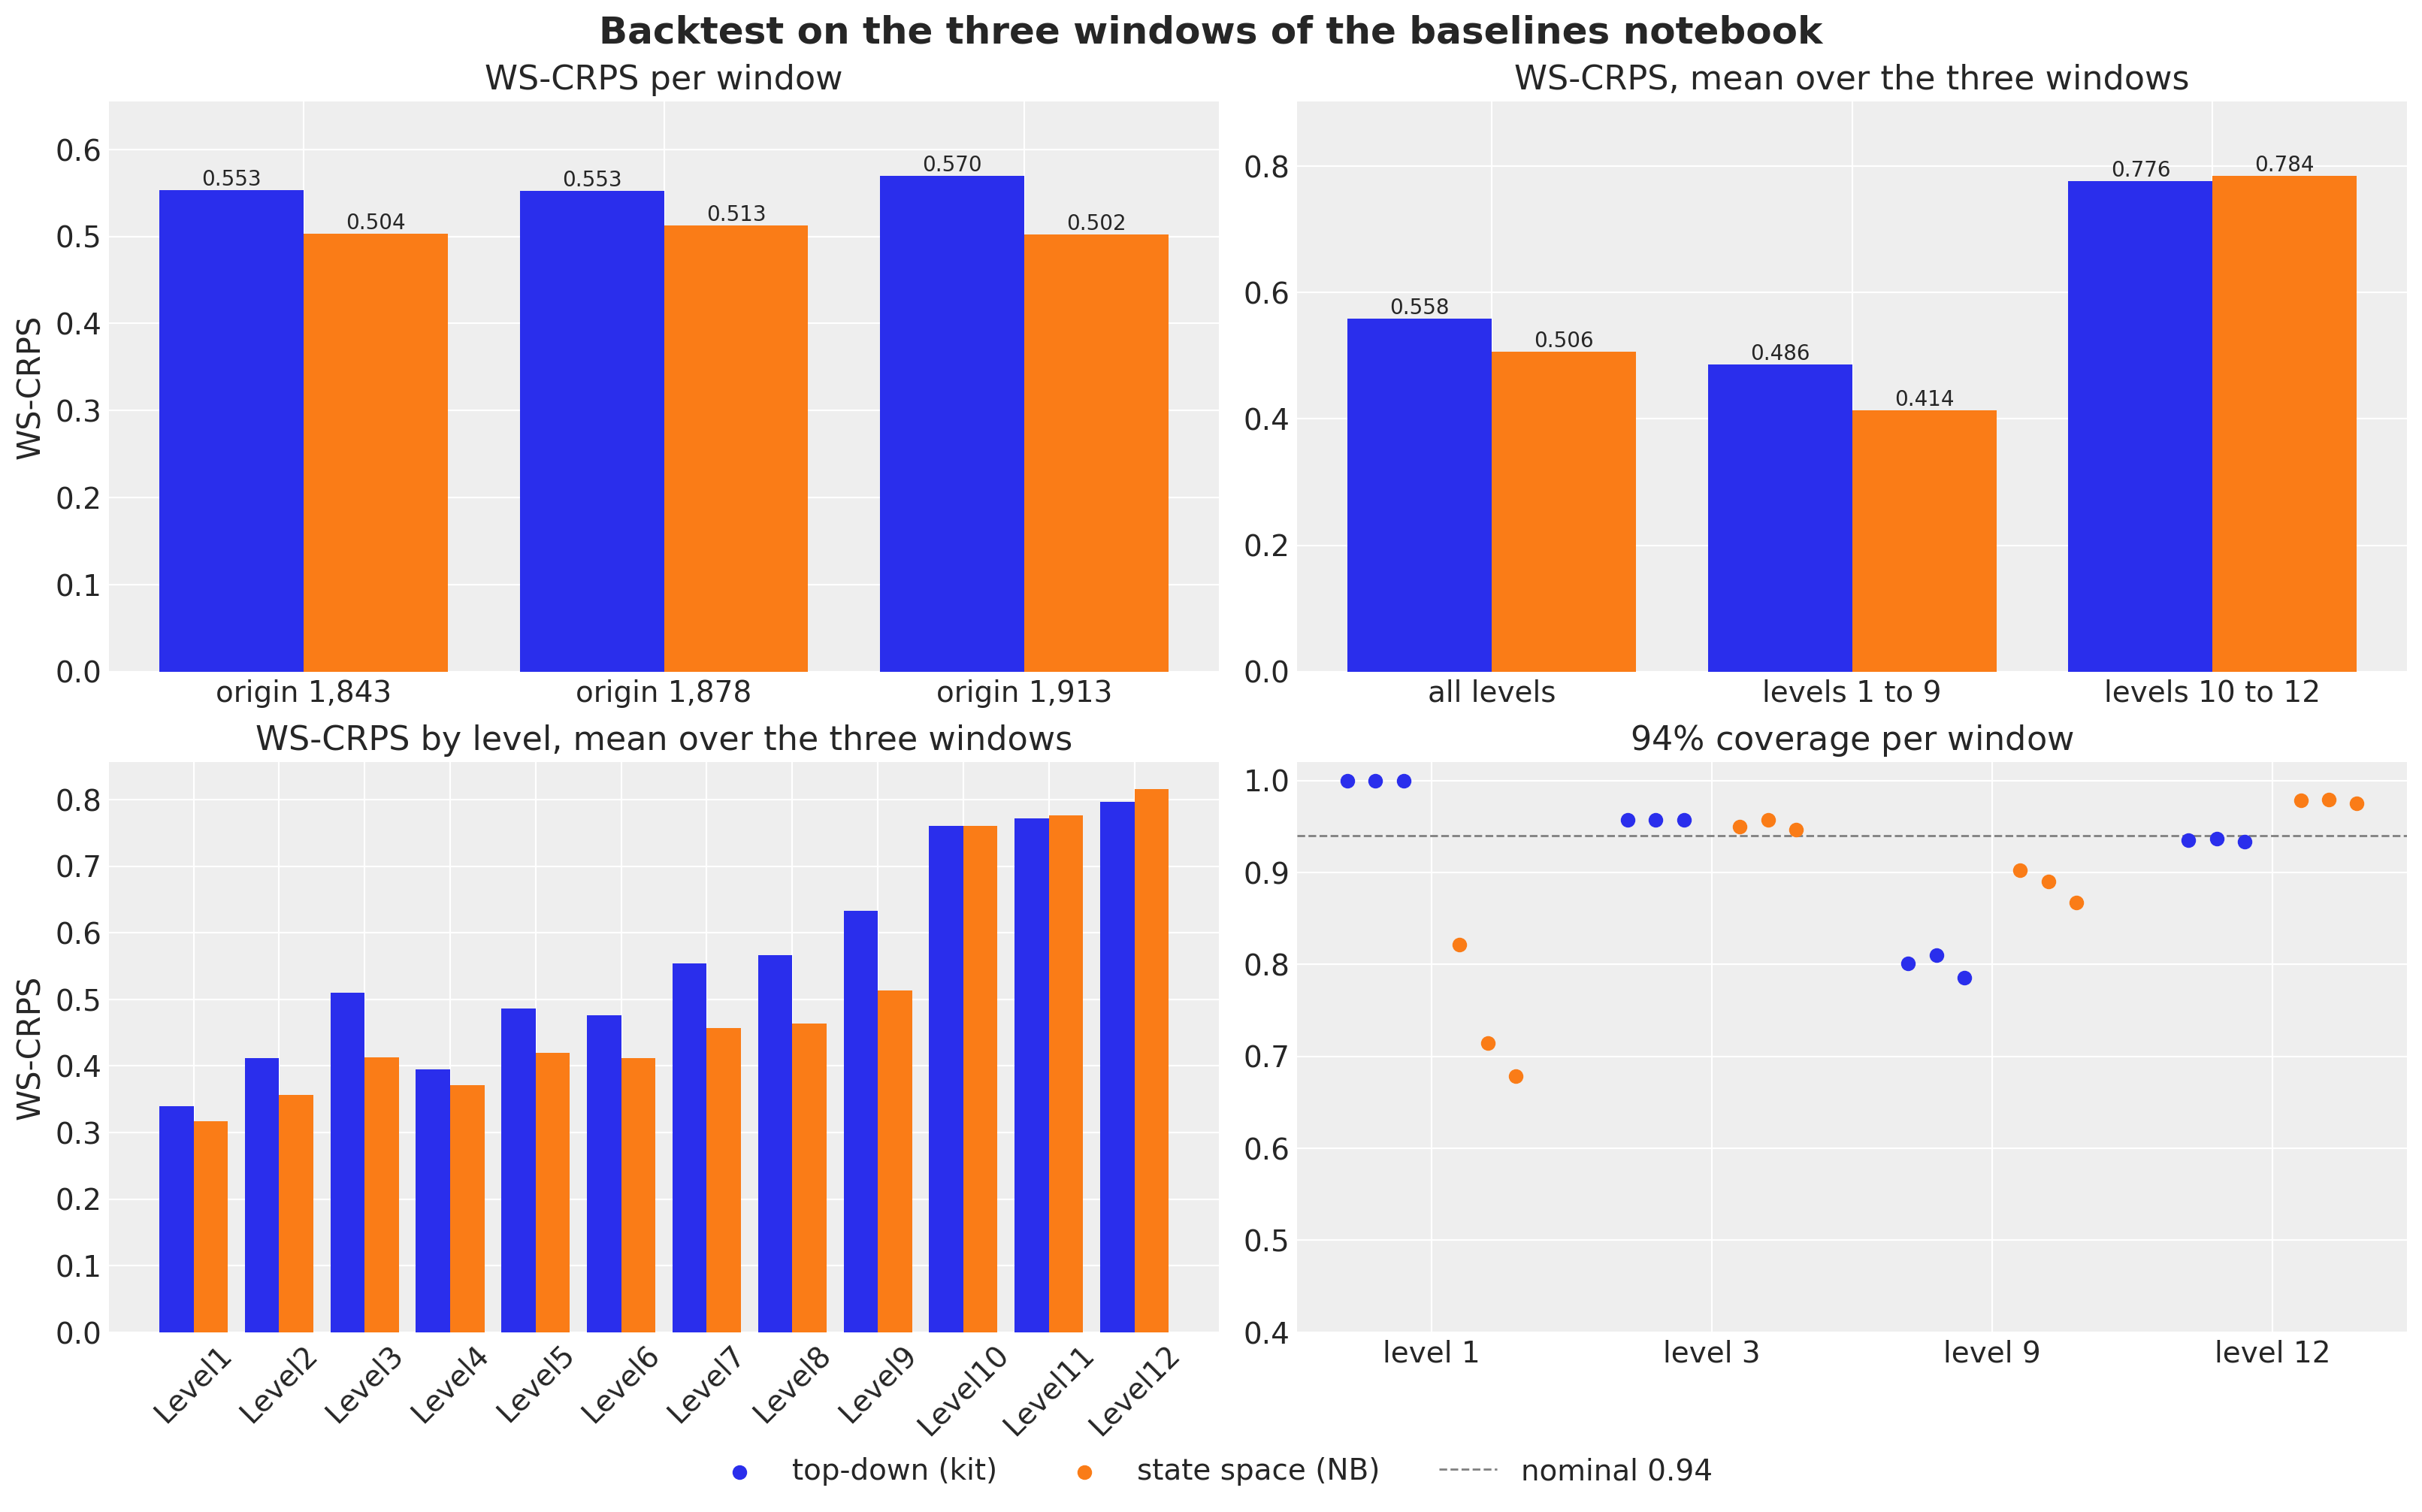

In [22]:
MODELS = ["top-down (kit)", "state space (NB)"]
SUMMARY_COLUMNS = {
    "ws_crps": "all levels",
    "ws_crps_1_9": "levels 1 to 9",
    "ws_crps_10_12": "levels 10 to 12",
}
backtest_mean = backtest_df.group_by("model", maintain_order=True).agg(
    pl.col(*SUMMARY_COLUMNS, *LEVEL_COLUMNS, *COVERAGE_COLUMNS).mean()
)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), layout="constrained")
width = 0.4

# Top left: the headline score per window.
x = np.arange(len(BACKTEST_ORIGINS))

for k, name in enumerate(MODELS):
    rows = backtest_df.filter(pl.col("model").eq(pl.lit(name))).sort("t1")
    bars = axes[0, 0].bar(x + (k - 0.5) * width, rows["ws_crps"].to_numpy(), width, label=name)
    axes[0, 0].bar_label(bars, fmt="%.3f", fontsize=10)

axes[0, 0].set_xticks(x, [f"origin {origin:,}" for origin in BACKTEST_ORIGINS])
axes[0, 0].set(title="WS-CRPS per window", ylabel="WS-CRPS")
axes[0, 0].margins(y=0.15)

# Top right: the means over the three windows, all levels and the two halves.
x = np.arange(len(SUMMARY_COLUMNS))

for k, name in enumerate(MODELS):
    row = backtest_mean.filter(pl.col("model").eq(pl.lit(name)))
    values = row.select(list(SUMMARY_COLUMNS)).to_numpy()[0]
    bars = axes[0, 1].bar(x + (k - 0.5) * width, values, width, label=name)
    axes[0, 1].bar_label(bars, fmt="%.3f", fontsize=10)

axes[0, 1].set_xticks(x, list(SUMMARY_COLUMNS.values()))
axes[0, 1].set(title="WS-CRPS, mean over the three windows")
axes[0, 1].margins(y=0.15)

# Bottom left: the per-level scores, mean over the windows.
x = np.arange(len(LEVELS))

for k, name in enumerate(MODELS):
    row = backtest_mean.filter(pl.col("model").eq(pl.lit(name)))
    values = row.select(LEVEL_COLUMNS).to_numpy()[0]
    axes[1, 0].bar(x + (k - 0.5) * width, values, width, label=name)

axes[1, 0].set_xticks(x, list(LEVELS), rotation=45)
axes[1, 0].set(title="WS-CRPS by level, mean over the three windows", ylabel="WS-CRPS")

# Bottom right: the coverage of the central 94% interval at four levels, one marker per window.
x = np.arange(len(COVERAGE_LEVELS))

for k, name in enumerate(MODELS):
    rows = backtest_df.filter(pl.col("model").eq(pl.lit(name))).sort("t1")

    for j in range(rows.height):
        axes[1, 1].scatter(
            x + (k - 0.5) * width + (j - 1) * 0.1,
            rows[j].select(COVERAGE_COLUMNS).to_numpy()[0],
            color=f"C{k}",
            label=name if j == 0 else None,
            zorder=3,
        )

axes[1, 1].axhline(0.94, color="gray", ls="--", lw=1, label="nominal 0.94")
axes[1, 1].set_xticks(x, [level.replace("Level", "level ") for level in COVERAGE_LEVELS])
axes[1, 1].set(title=r"$94\%$ coverage per window", ylim=(0.4, 1.02))
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle(
    "Backtest on the three windows of the baselines notebook", fontsize=18, fontweight="bold"
);

The state space model is ahead on every window (0.504, 0.513 and 0.502 against 0.553, 0.553 and 0.570), and the gain is at the aggregate levels: 0.414 against 0.486 on average over levels 1 to 9, with the item levels a draw (0.784 against 0.776). The coverage panel reads the calibration. At the store level both models are at the nominal 0.95; at the store-department level the state space model is at 0.87 to 0.90 where the baseline is at 0.80; at the item level the negative binomial is a little wide at 0.98 where the baseline is at 0.93; and at the total level the baseline covers every day of every window (a band that wide pays in the CRPS) while the state space model covers 68 to 82 percent of the days, too narrow. The evaluation window below tells the same story.

## The final fit

The model is now fitted once on the last two years before the evaluation window.

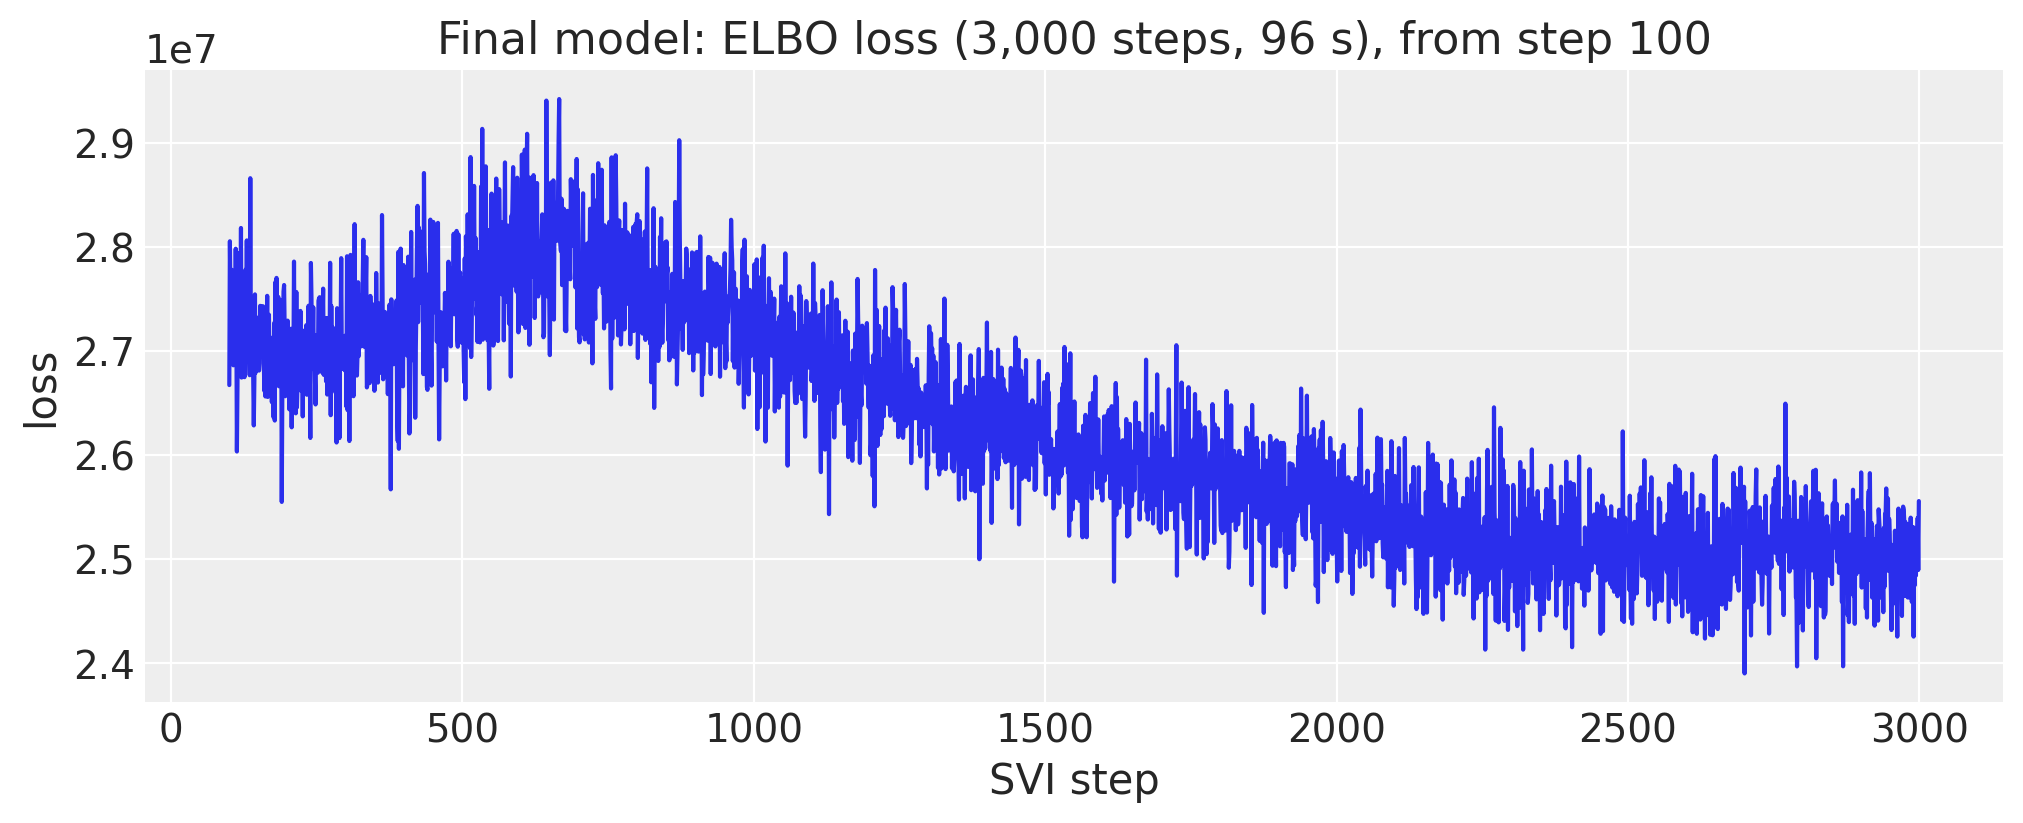

In [23]:
rng_key, key_fit = random.split(rng_key)
guide_final, svi_final, time_final = fit_model(
    key_fit, final_model, covariates_final[:, :HISTORY_DAYS], counts_final
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(100, NUM_STEPS), np.asarray(svi_final.losses[100:]), color="C0")
ax.set(
    title=f"Final model: ELBO loss ({NUM_STEPS:,} steps, {time_final:.0f} s), from step 100",
    xlabel="SVI step",
    ylabel="loss",
);

The loss rises during the warm-up of the one-cycle schedule (the peak learning rate is reached at step 600) and then falls for the rest of the run; it is still going down slowly at step 3,000, so a longer run would buy a little more, at a cost that the timing section puts in context. The curve is noisy for the same reason as the bottom-up model of the baselines notebook: every step scores a different random set of 1,500 series.

### Posterior of the shared parameters

The item-level sites are too many to look at one by one, so we export the shared sites (the population scales and the pooled effects) to ArviZ with named coordinates. The first forest plot shows the five population scales by department (or by store for the shock scale): how much each component moves on the log scale.

In [24]:
rng_key, key_post = random.split(rng_key)
posterior_final = draw_posterior(key_post, guide_final, svi_final.params, 500)

DOW_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
SHARED_DIMS = {
    "sigma_alpha": ["dept"],
    "tau_phi": ["dept"],
    "sigma_walk": ["dept"],
    "sigma_item_dow": ["dept"],
    "sigma_event": ["dept"],
    "w_fourier": ["dept", "harmonic"],
    "gamma_event": ["dept", "event"],
    "store_shock_scale": ["store"],
    "log_phi_group": ["group"],
    "seasonal_group": ["group", "day_of_week"],
    "snap_group": ["group"],
    "alpha_group": ["group"],
}
tree_final = az.from_dict(
    {"posterior": {name: np.asarray(posterior_final[name])[None] for name in SHARED_DIMS}},
    coords={
        "dept": dept_ids,
        "group": group_ids,
        "store": store_ids,
        "day_of_week": DOW_LABELS,
        "event": event_names,
        "harmonic": [f"{f}{k}" for f in ("sin", "cos") for k in range(1, N_HARMONICS + 1)],
    },
    dims=SHARED_DIMS,
)

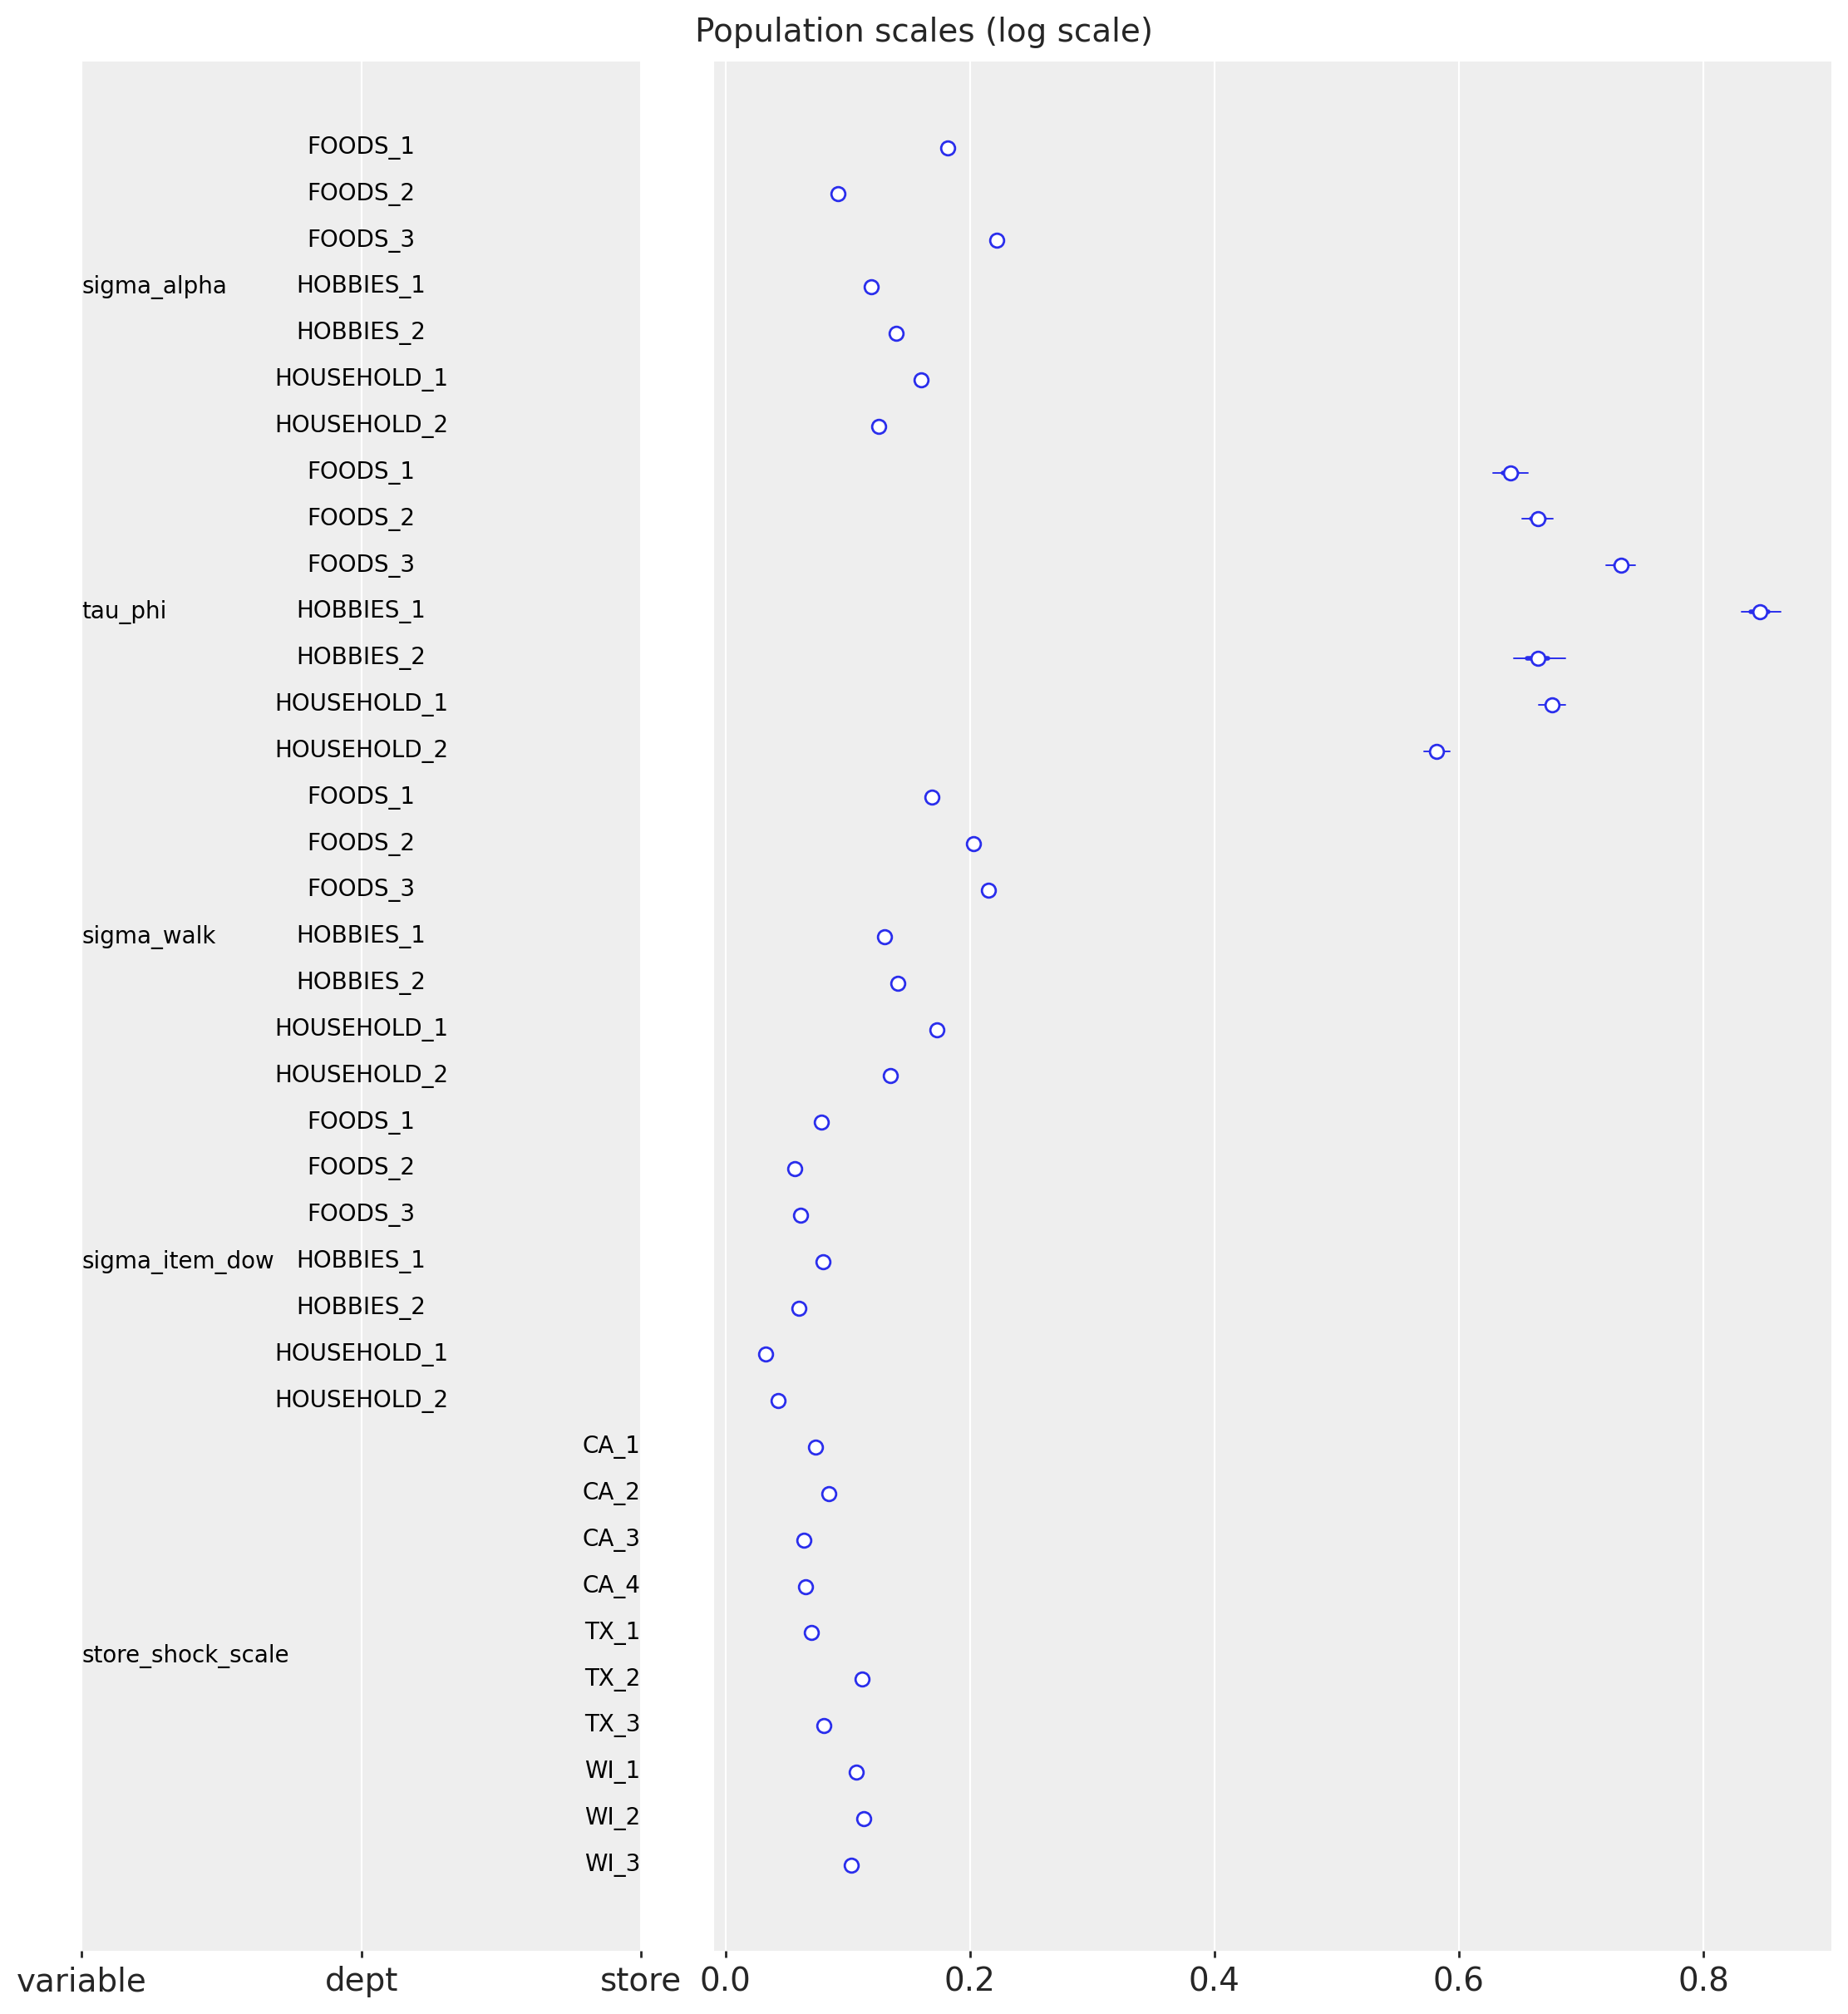

In [25]:
pc = az.plot_forest(
    tree_final,
    var_names=["sigma_alpha", "tau_phi", "sigma_walk", "sigma_item_dow", "store_shock_scale"],
    combined=True,
    figure_kwargs={"figsize": (11, 12)},
)
pc.viz["figure"].item().suptitle("Population scales (log scale)", fontsize=14);

The population scales tell how much each component moves. The intercept deviations $\sigma^{\alpha}$ are 0.09 to 0.22 on the log scale by department: the prior center, the last-28-day level, is close for most items. The item dispersion spreads $\tau$ are 0.58 to 0.85, large: item-level dispersion matters, two items of the same store-department can differ by a factor of two in dispersion. The block-walk innovation scales $\sigma^{u}$ are 0.13 to 0.22 per 28-day block, larger for the FOODS departments than for HOBBIES and HOUSEHOLD, so a food item's level moves by $15\%$ to $20\%$ from one block to the next. The item weekday deviations are 0.03 to 0.08, small next to the store-department pattern they refine, and the store shock scales are 0.06 to 0.11, highest for the Wisconsin stores and TX_2. The intervals are tiny: with 30,490 series behind each population parameter and a mean-field guide, these are effectively point estimates.

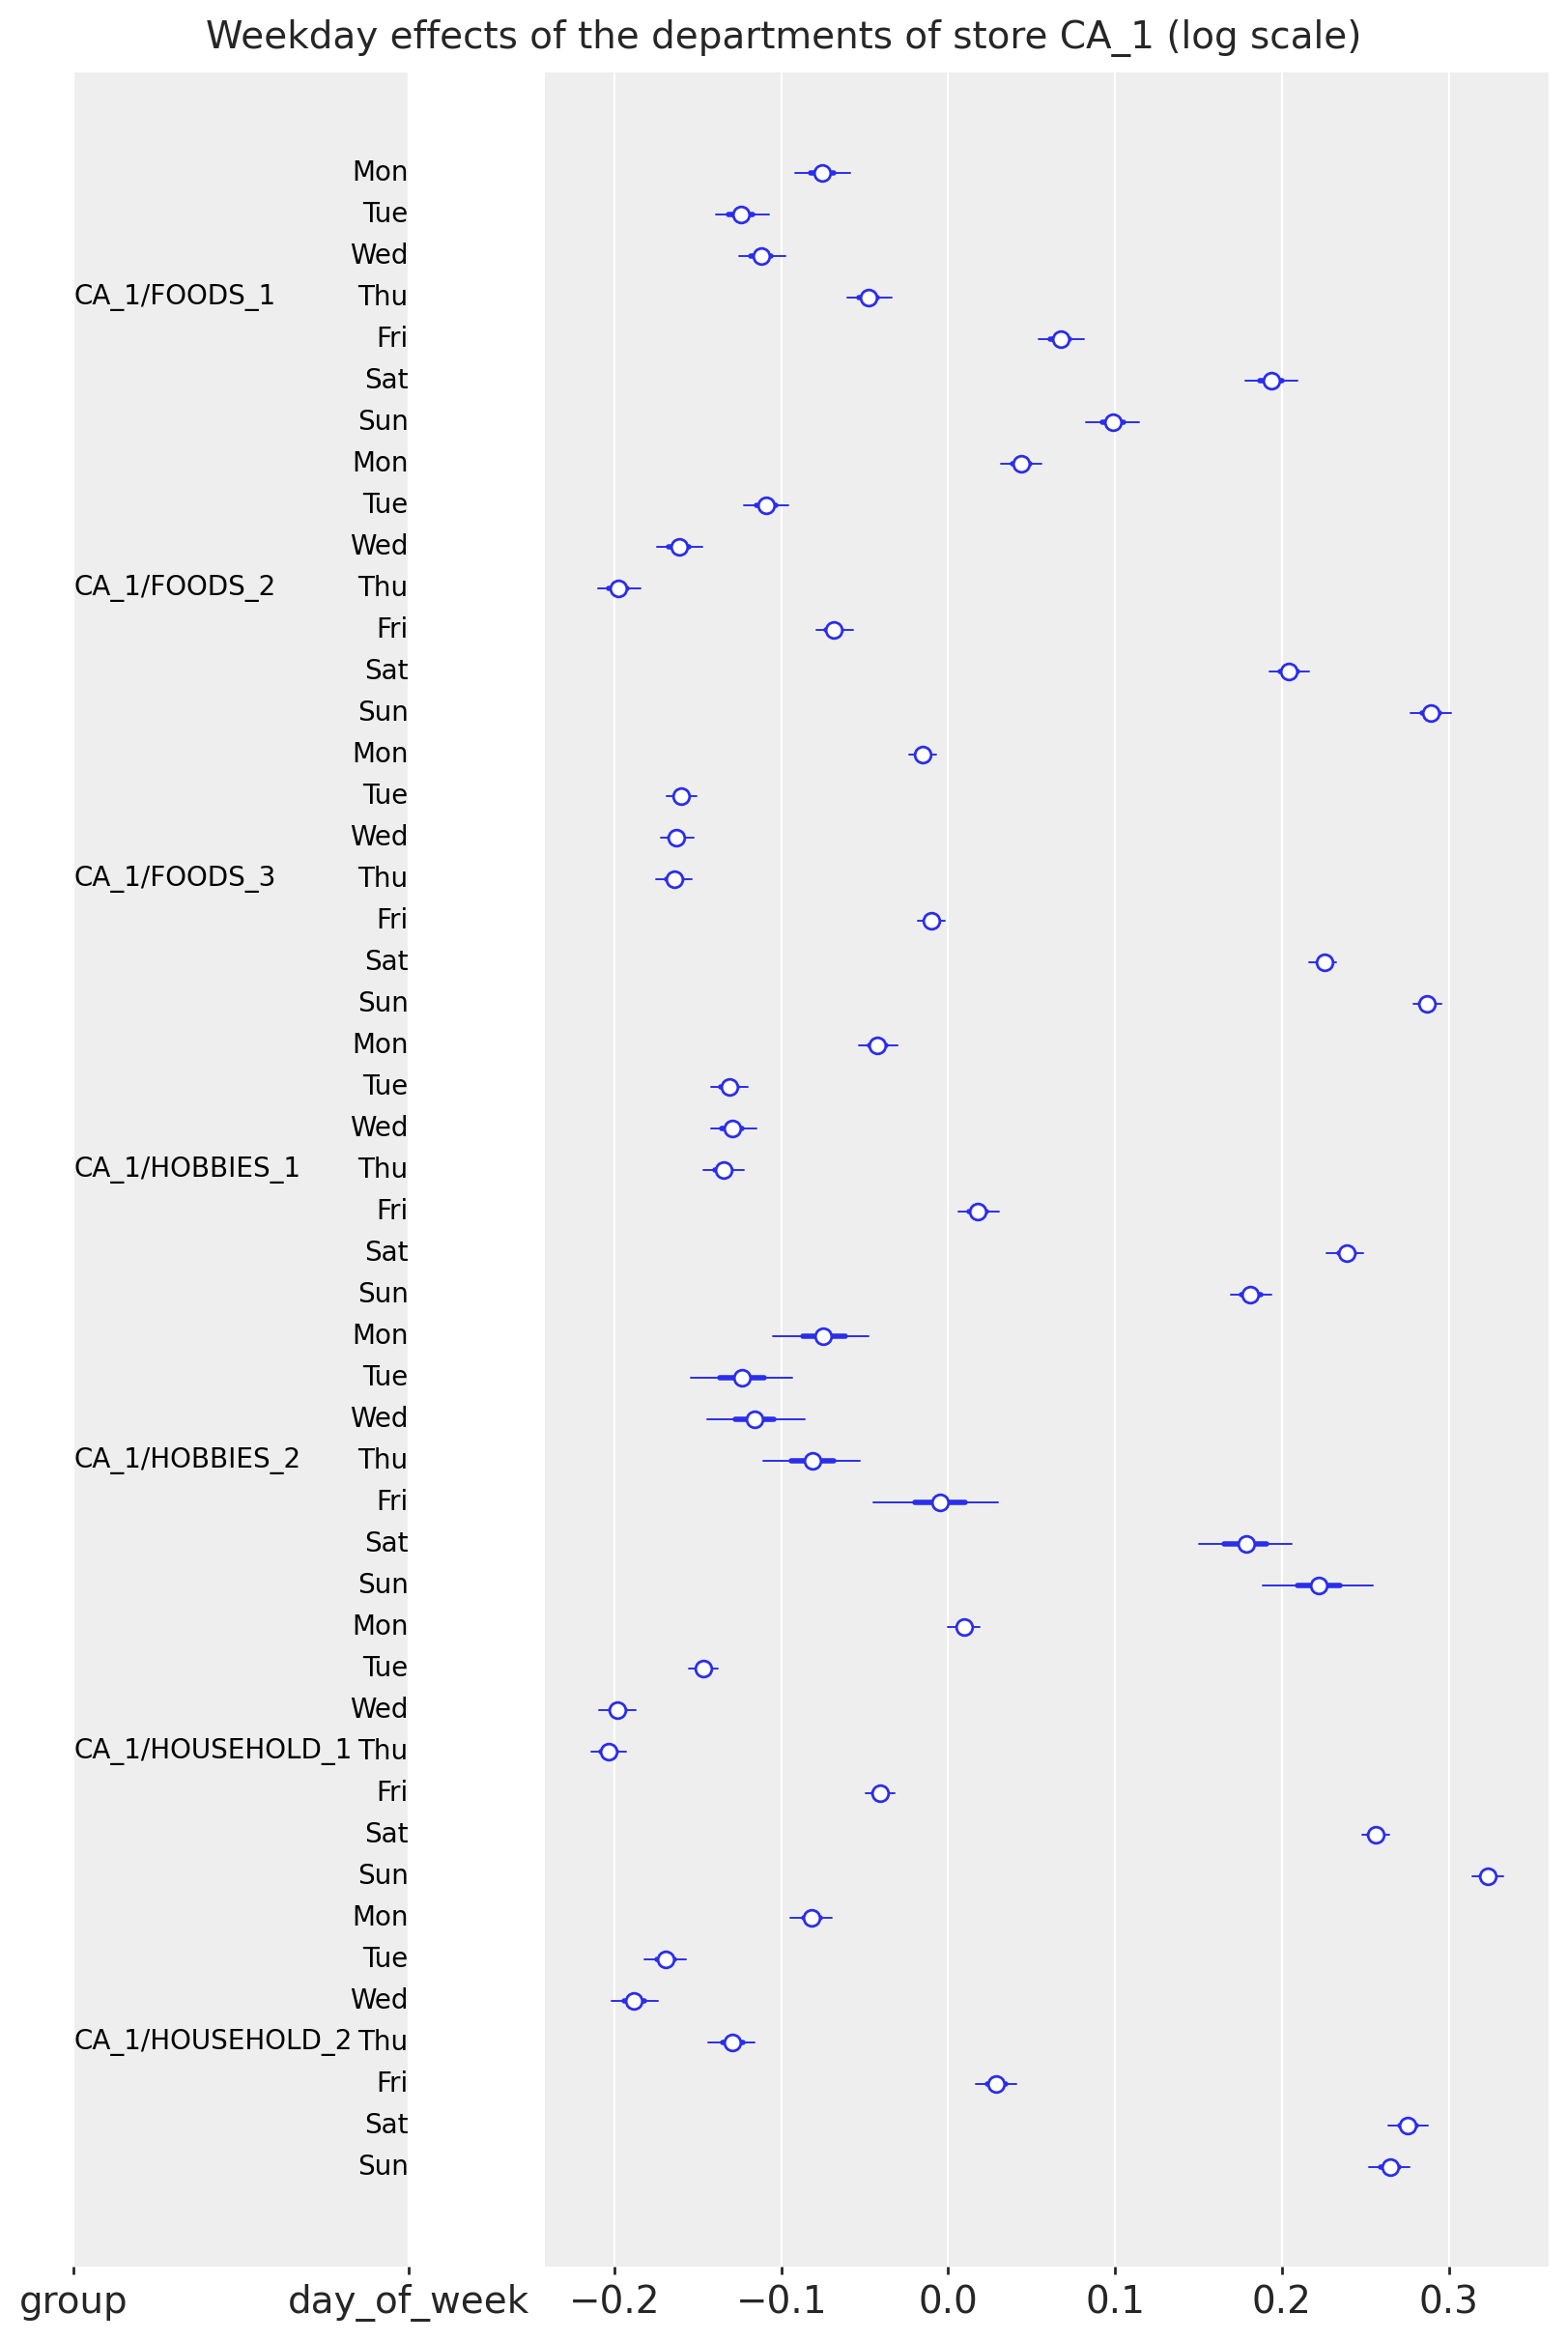

In [26]:
ca1_groups = [label for label in group_ids if label.startswith("CA_1/")]
pc = az.plot_forest(
    tree_final,
    var_names=["seasonal_group"],
    coords={"group": ca1_groups},
    combined=True,
    labels=["group", "day_of_week"],
    figure_kwargs={"figsize": (8, 12)},
)
pc.viz["figure"].item().suptitle(
    "Weekday effects of the departments of store CA_1 (log scale)", fontsize=14
);

The weekday effects of the departments of store CA_1 show the weekend peak of every department (Saturday and Sunday $+0.1$ to $+0.3$ on the log scale, Tuesday to Thursday $-0.05$ to $-0.2$), with the shape varying by department: the food departments peak on Sunday, the household departments on Saturday, and HOBBIES_2 is the flattest. These are the store-department patterns; the item deviations around them are an order of magnitude smaller.

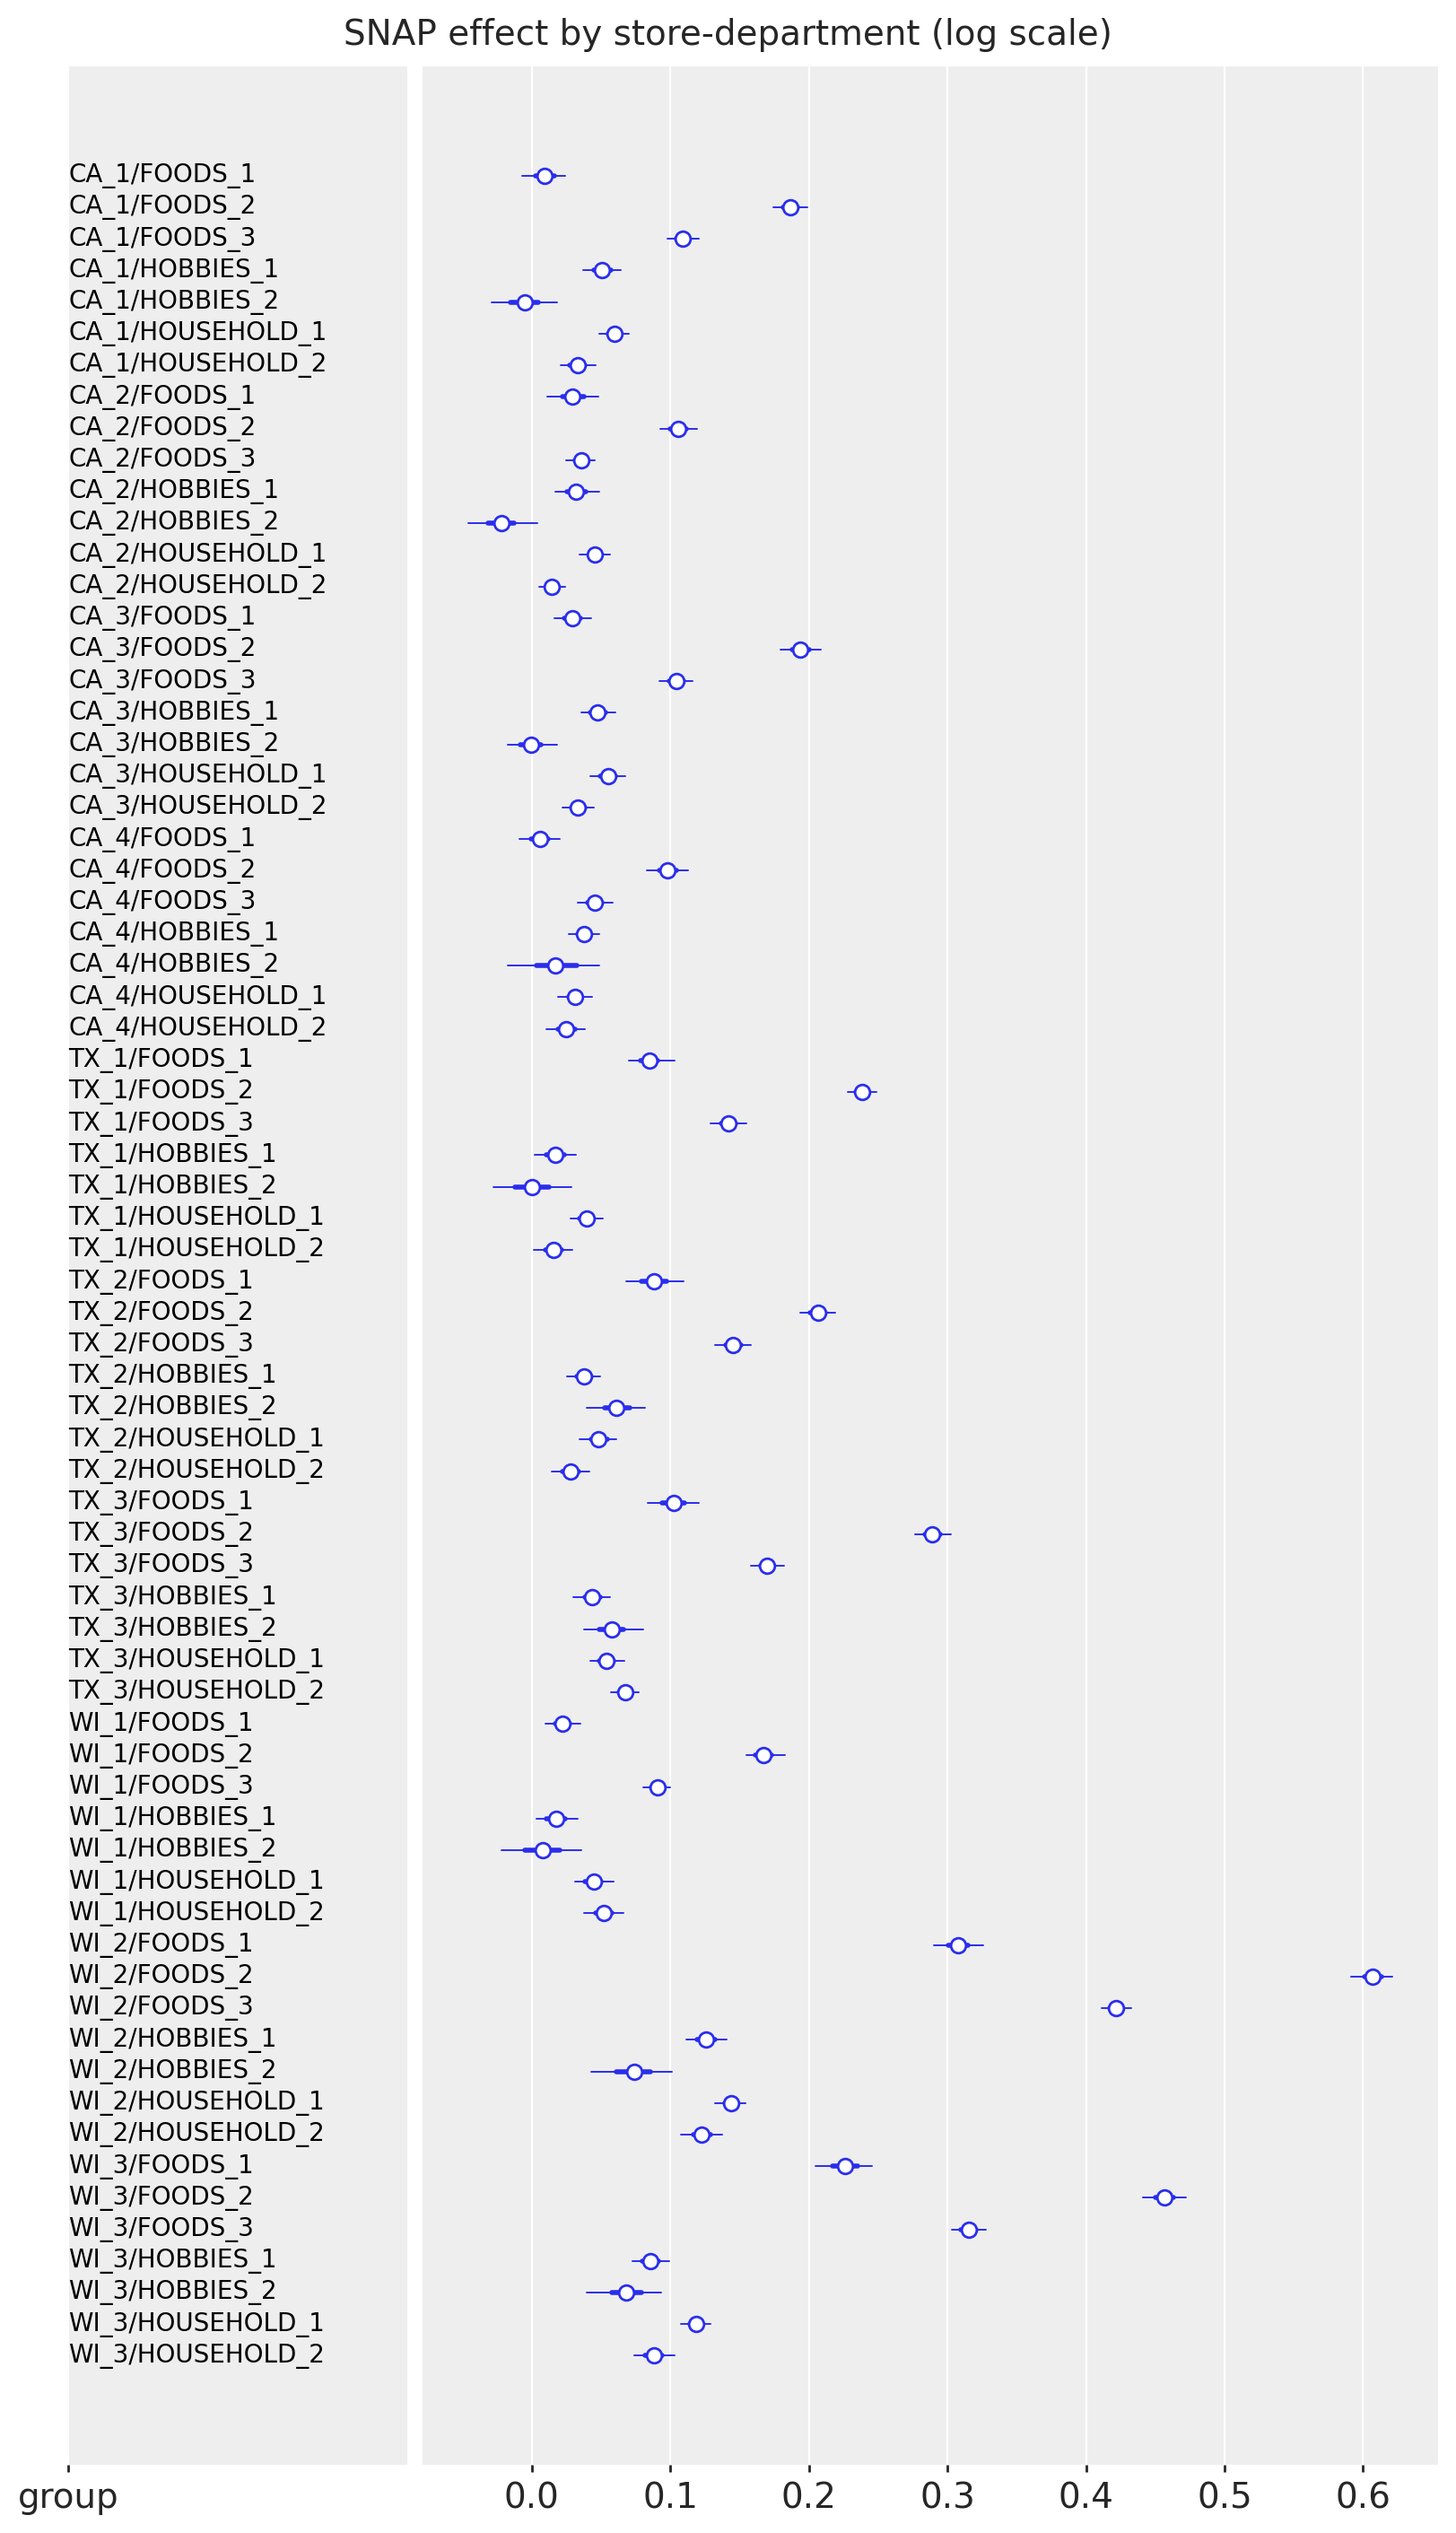

In [27]:
pc = az.plot_forest(
    tree_final,
    var_names=["snap_group"],
    combined=True,
    labels=["group"],
    figure_kwargs={"figsize": (8, 14)},
)
pc.viz["figure"].item().suptitle("SNAP effect by store-department (log scale)", fontsize=14);

The SNAP effect is strongest for the FOODS departments of the Wisconsin and Texas stores (up to $+0.6$ for WI_2/FOODS_2, that is $\times 1.8$ on SNAP days) and close to zero for HOBBIES and HOUSEHOLD, as expected of a food-stamp program; the pattern is the one the kit's bottom-up model found in the baselines notebook, now with a store-department resolution and intervals narrow enough to rank the stores.

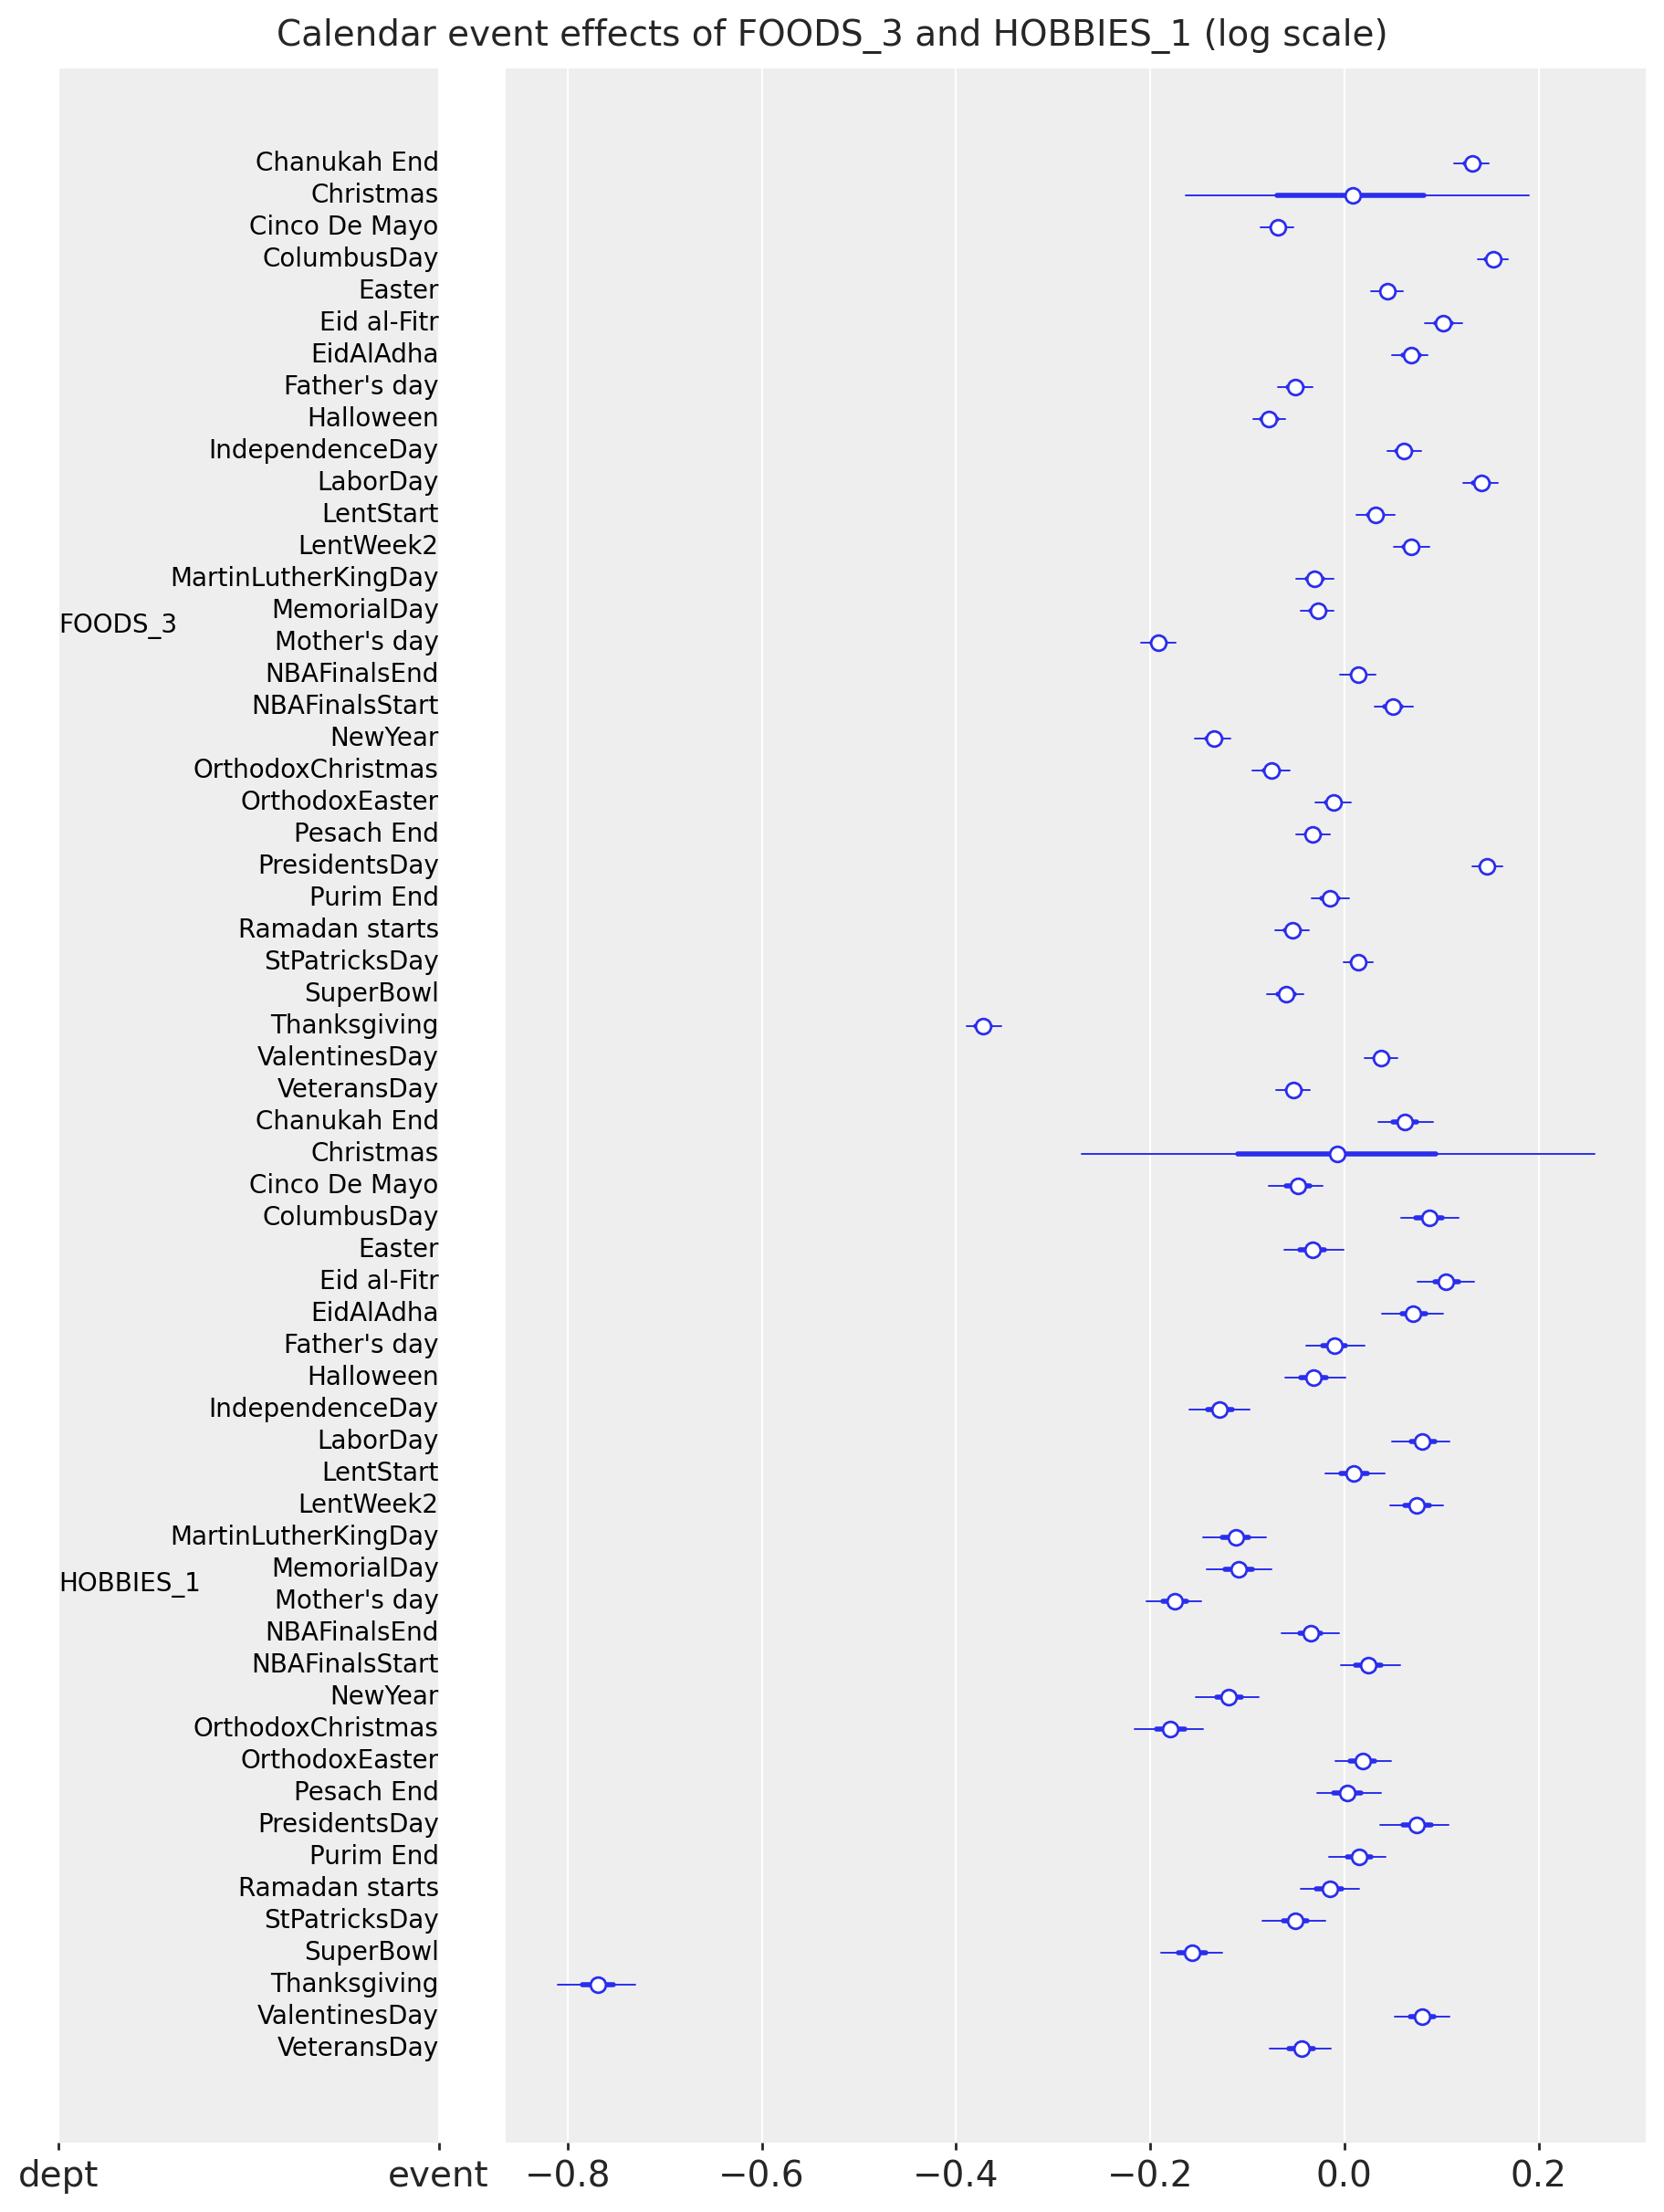

In [28]:
pc = az.plot_forest(
    tree_final,
    var_names=["gamma_event"],
    coords={"dept": ["FOODS_3", "HOBBIES_1"]},
    combined=True,
    labels=["dept", "event"],
    figure_kwargs={"figsize": (9, 12)},
)
pc.viz["figure"].item().suptitle(
    "Calendar event effects of FOODS_3 and HOBBIES_1 (log scale)", fontsize=14
);

The calendar events read as expected: every effect is the lift of the event over an ordinary day of the department. Thanksgiving is about $-0.4$ for FOODS_3 and $-0.8$ for HOBBIES_1 (the stores close early), Mother's Day and New Year are negative, Labor Day, Presidents' Day and Columbus Day are positive for FOODS_3. Christmas is the one event with a wide posterior: the stores are closed, `saled` is zero and the effect only sees its prior.

### In-sample fit and forecast of the focus items

The seven focus items of the prior predictive check, now with the posterior: `subset_posterior` picks the columns of these series out of the item-level draws, and the seven-series instance of the model gives the in-sample predictive and the forecast through `predict_in_sample()` and `forecast()`.

In [29]:
# The item-level sites and the axis of their series dimension.
ITEM_SITES = {"alpha": -1, "log_phi": -1, "item_walk": -1, "item_dow": -2}


def subset_posterior(posterior: dict, index: np.ndarray) -> dict:
    """Keep the draws of the series in ``index`` for the item-level sites, everything else as is."""
    out = {}

    for name, value in posterior.items():
        if name in ITEM_SITES:
            axis = ITEM_SITES[name] % value.ndim
            out[name] = jnp.take(value, jnp.asarray(index), axis=axis)
        else:
            out[name] = value

    return out


posterior_focus = subset_posterior(posterior_final, focus_index)

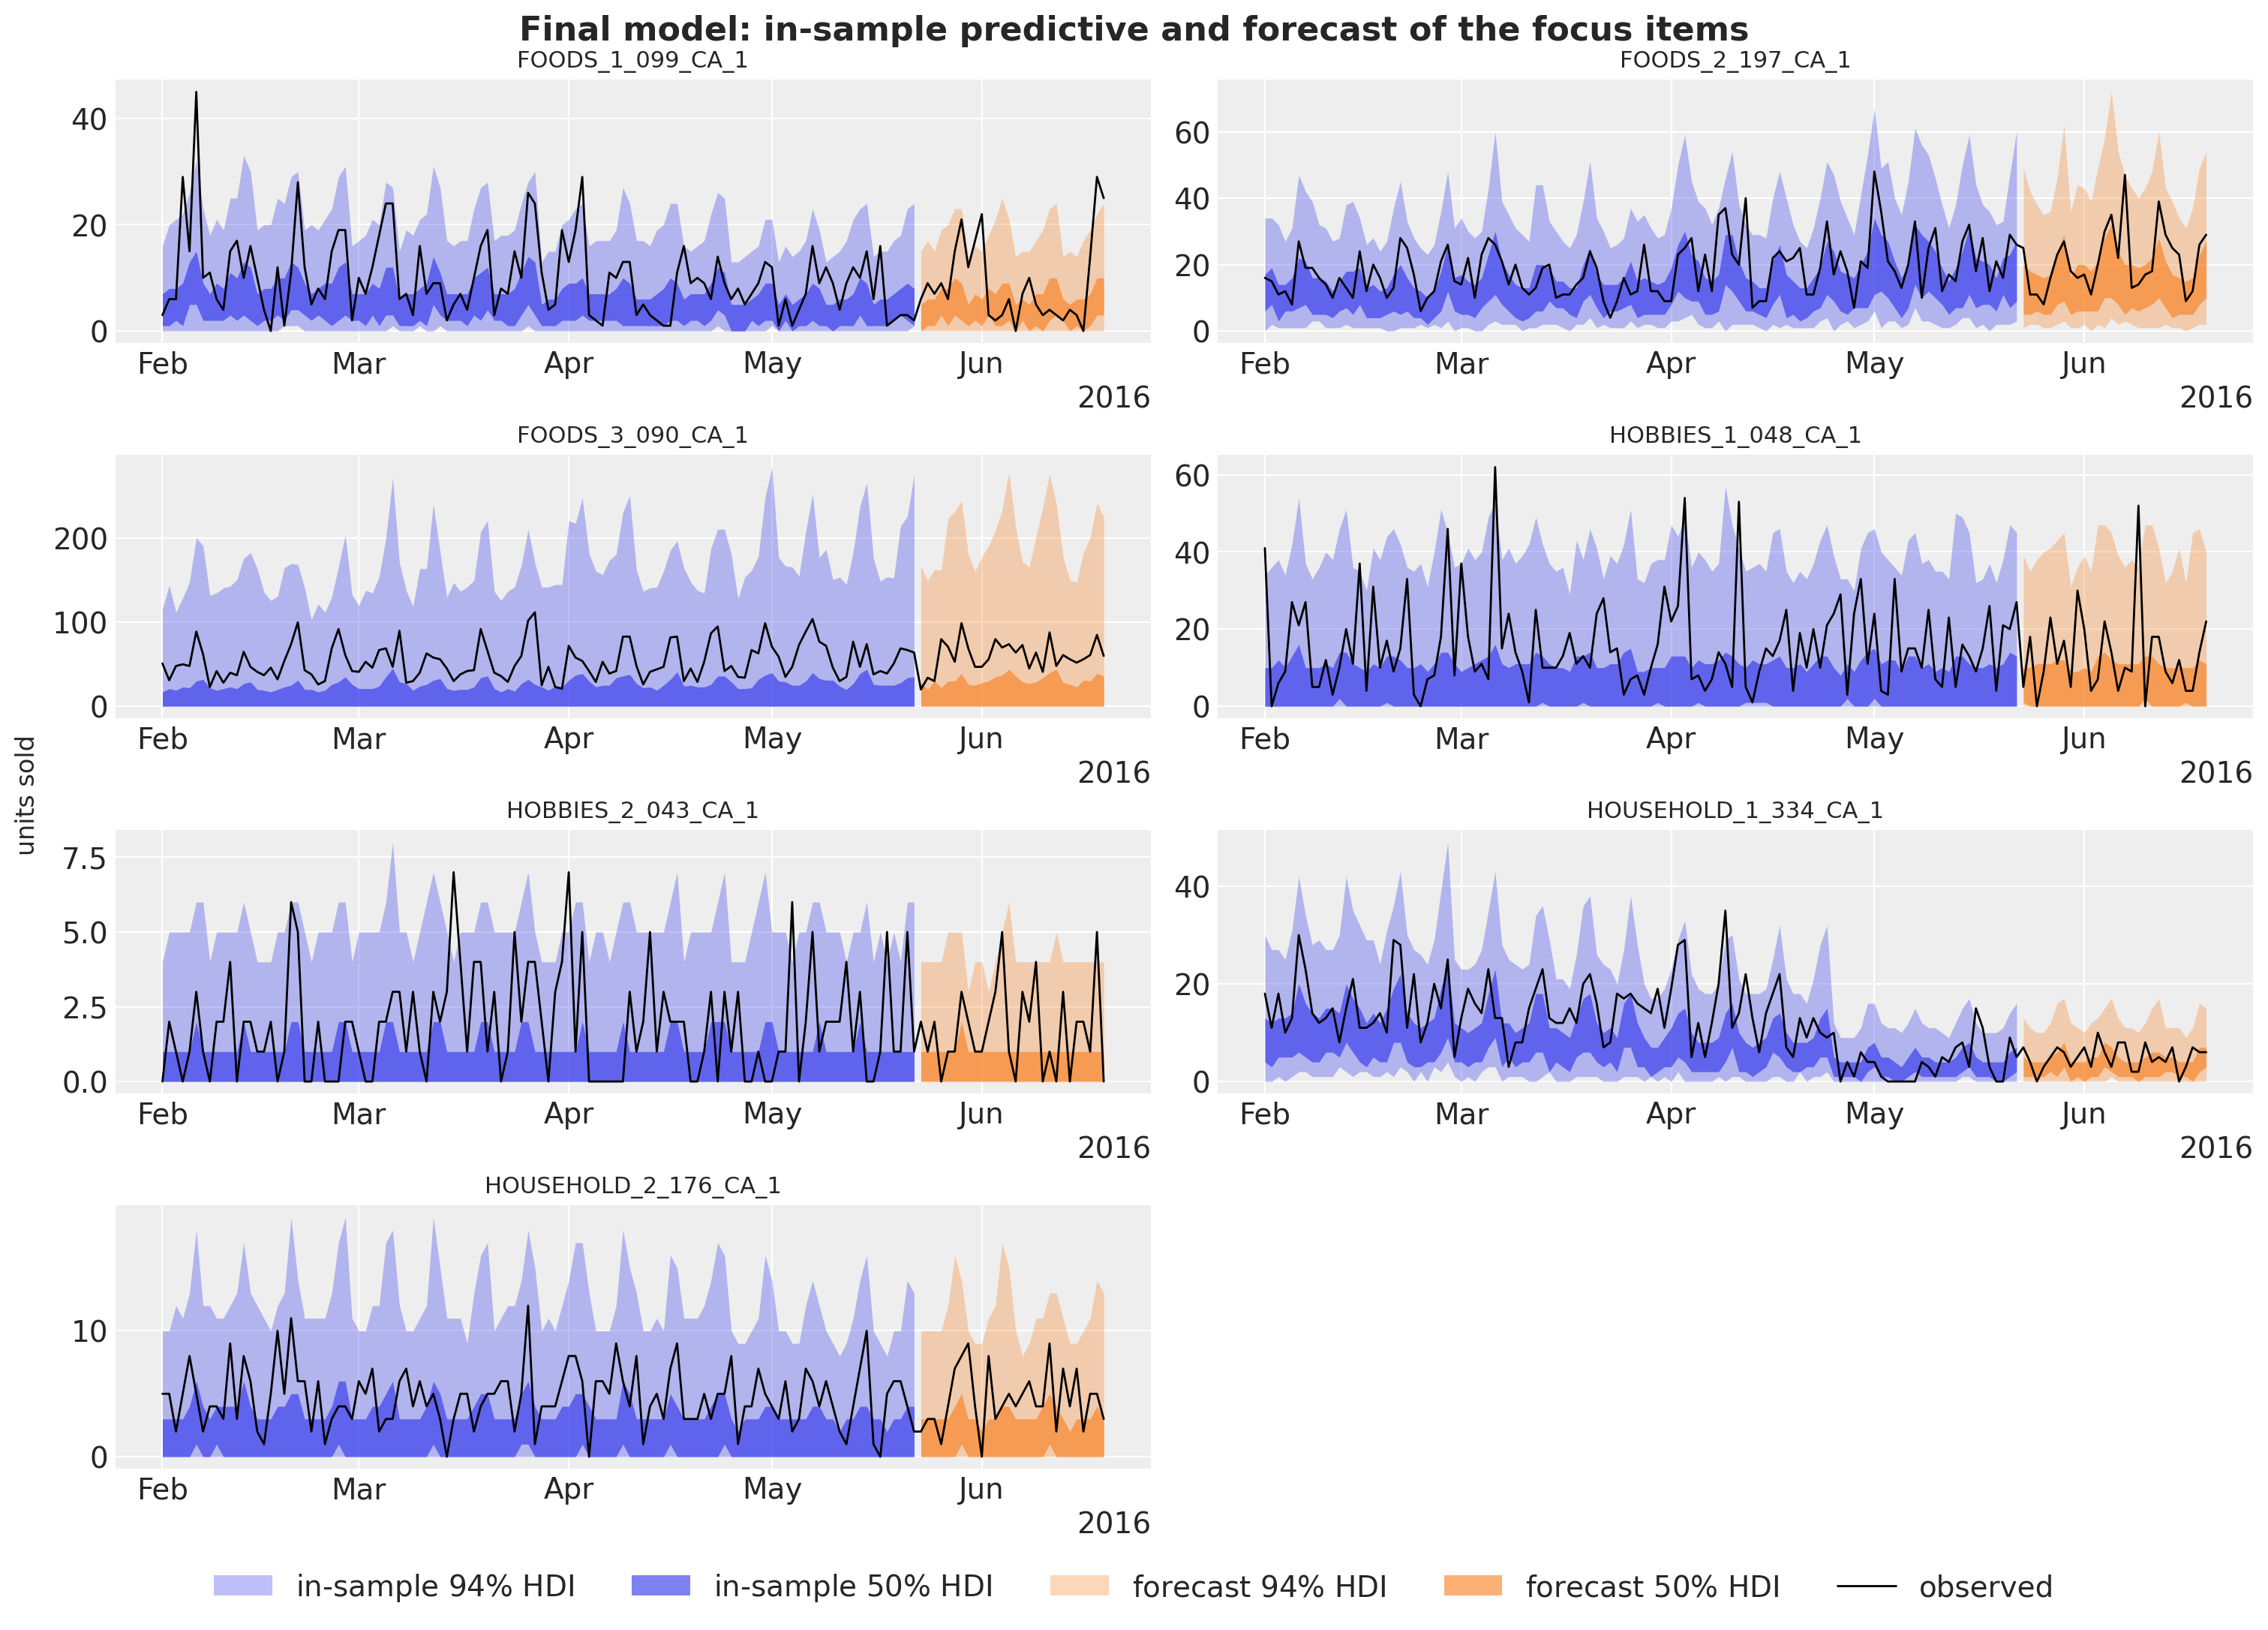

In [30]:
rng_key, key_pp, key_fc = random.split(rng_key, 3)
pp_focus = predict_in_sample(
    key_pp, focus_model, posterior_focus, covariates_focus[:, :HISTORY_DAYS]
)
fc_focus = forecast(
    key_fc, focus_model, posterior_focus, counts_final[:, focus_index], covariates_focus
)

plot_series_panel(
    np.asarray(pp_focus)[:, -16 * 7 :],
    fc_focus,
    sales[plot_start:N_DAYS, focus_index],
    focus_labels,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Final model: in-sample predictive and forecast of the focus items",
)

del pp_focus

Compared with the kit's bottom-up model on the same seven items, the level is right: the item intercept and the block walk put every band on the observed series, where the department regression of the baselines notebook forecast the best sellers at a fraction of their level. The wide upper tails of FOODS_3_090 are the negative binomial dispersion of a bursty series, and HOUSEHOLD_1_334 shows the block walk at work: its level dropped in May and the forecast follows the last block, not the two-year mean. The forecast bands are a little wider than the in-sample ones, by the one fresh block innovation and the fresh store weeks of the horizon.

## The evaluation window

The final model forecasts the 28 evaluation days (`d_1942` to `d_1969`) with 500 draws and is scored against the top-down baseline, re-run here with 500 draws as well; the middle-out and bottom-up baselines scored 0.634 and 0.728 on this window in the baselines notebook. The competition's own metric, the weighted scaled pinball loss (WSPL) at the nine competition quantiles, is computed here too, to place both models on the published leaderboard.

In [31]:
M5_INTERVALS = np.array([0.5, 0.67, 0.95, 0.99])
M5_QUANTILES = np.sort(
    np.concatenate([[0.5], (1 - M5_INTERVALS) / 2, (1 + M5_INTERVALS) / 2])
).astype(np.float32)


def ws_pinball(
    pred_levels: np.ndarray, truth_levels: np.ndarray, weights: np.ndarray, scales: np.ndarray
) -> float:
    """M5 WSPL: pinball loss at the nine competition quantiles, weighted, scaled, mean over levels."""
    quantiles = np.quantile(pred_levels, M5_QUANTILES, axis=0)
    error = quantiles - truth_levels[None]
    u = M5_QUANTILES[:, None, None]
    per_series = (np.where(error <= 0, -u, 1 - u) * error).mean(axis=(0, 1))
    level_scores = [
        np.sum(weights[level_slice] * per_series[level_slice] / scales[level_slice])
        for level_slice in level_slices.values()
    ]

    return float(np.mean(level_scores))


def ws_crps_mean(scores: dict) -> float:
    """Mean of the 12 level scores of an ``evaluate_forecast`` result."""
    return float(np.mean([scores[f"ws_crps_{level}"] for level in LEVELS]))

In [32]:
truth_holdout = sales[N_DAYS_TRAIN:N_DAYS]
holdout_metrics = m5_metrics(0, N_DAYS_TRAIN, N_DAYS)
weights_holdout = m5_weights(N_DAYS_TRAIN)
scales_holdout = m5_scales(sales_agg[:N_DAYS_TRAIN])

# The state space model: 500 bottom-level draws, summed to the levels and scored.
rng_key, key_fc = random.split(rng_key)
start = perf_counter()
bottom_final = forecast_bottom_level(
    key_fc, guide_final, svi_final.params, counts_final, covariates_final, 500
)
time_fc_final = perf_counter() - start

pred_levels, truth_levels = aggregate_transform(bottom_final, truth_holdout)
scores_final = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_final = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_final = pred_levels[..., 0]
level3_final = pred_levels[..., level_slices["Level3"]]
del bottom_final, pred_levels

# The top-down baseline, fitted and forecast the same way.
rng_key, key_top = random.split(rng_key)
start = perf_counter()
bottom_top = forecast_fn_top_down(
    key_top, top_down_model, sales_train, covariates_top[:N_DAYS_TRAIN], covariates_top, 500
)
time_top_fc = perf_counter() - start

pred_levels, _ = aggregate_transform(bottom_top, truth_holdout)
scores_top = evaluate_forecast(pred_levels, truth_levels, metrics=holdout_metrics)
wspl_top = ws_pinball(pred_levels, truth_levels, weights_holdout, scales_holdout)
level1_top = pred_levels[..., 0]
del bottom_top, pred_levels

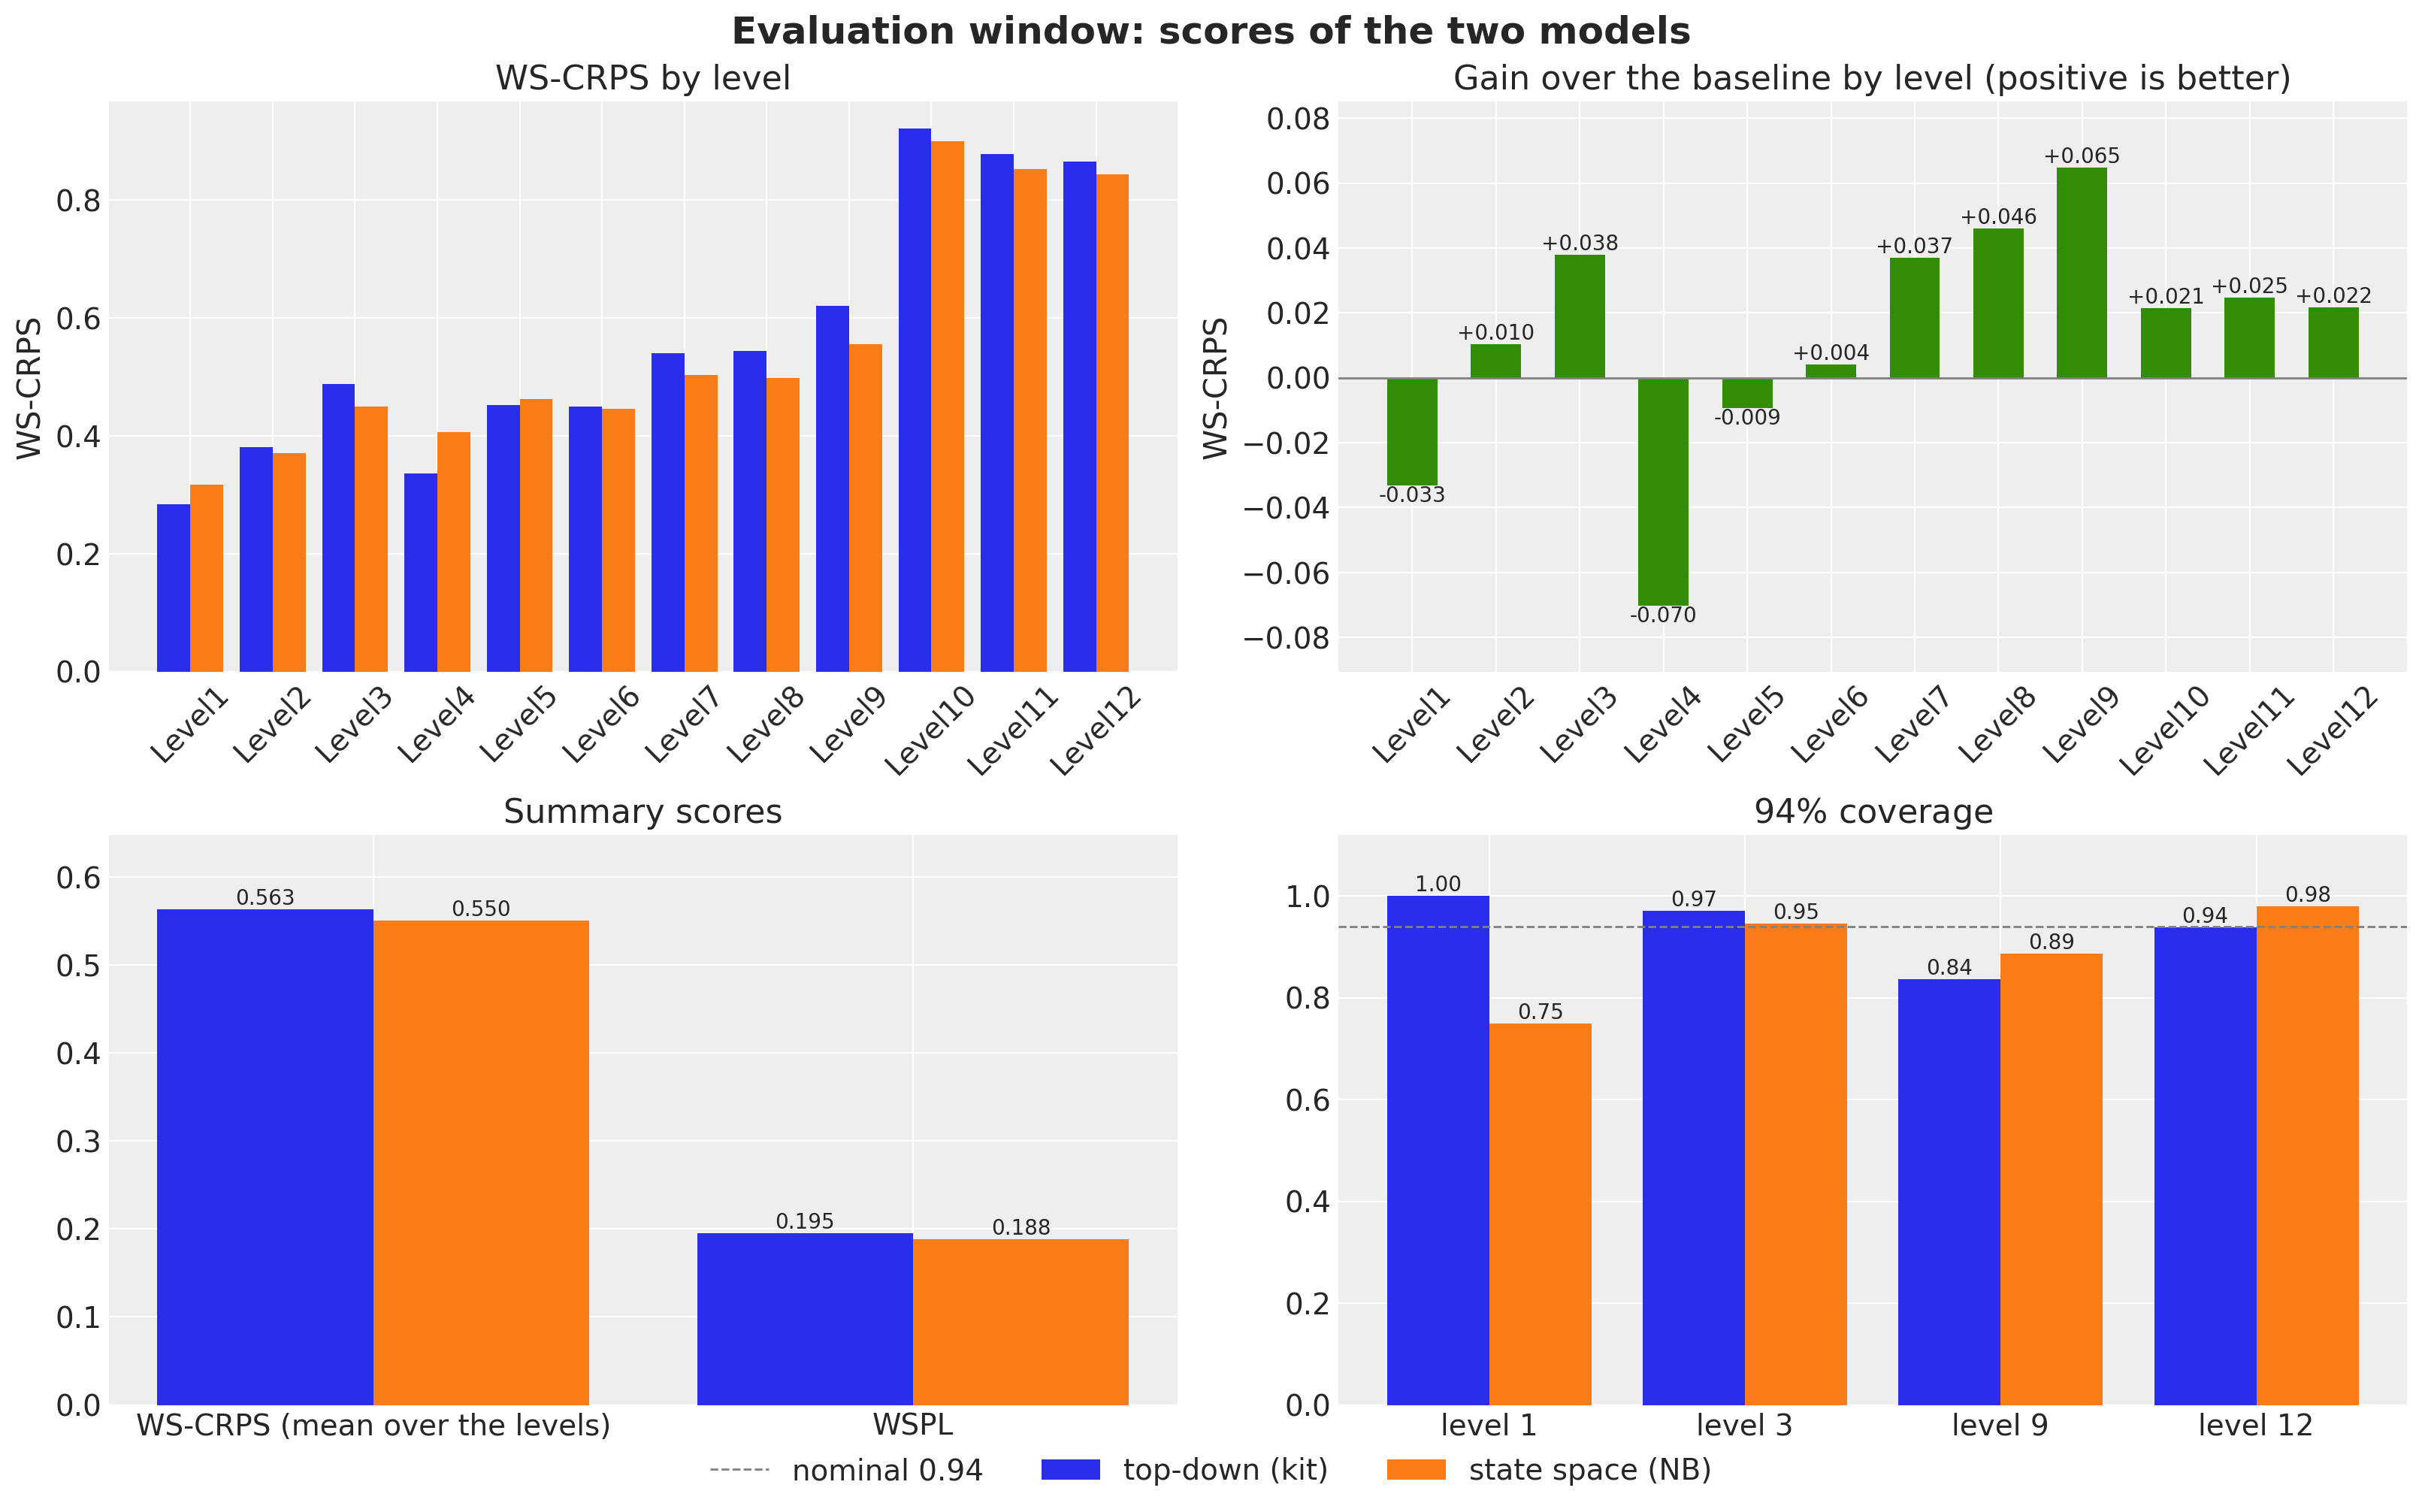

In [33]:
scores = {"top-down (kit)": (scores_top, wspl_top), "state space (NB)": (scores_final, wspl_final)}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), layout="constrained")
width = 0.4

# Top left: the per-level scores.
x = np.arange(len(LEVELS))

for k, (name, (level_scores, _)) in enumerate(scores.items()):
    values = [level_scores[f"ws_crps_{level}"] for level in LEVELS]
    axes[0, 0].bar(x + (k - 0.5) * width, values, width, label=name)

axes[0, 0].set_xticks(x, list(LEVELS), rotation=45)
axes[0, 0].set(title="WS-CRPS by level", ylabel="WS-CRPS")

# Top right: the gain of the state space model over the baseline, level by level.
gains = [
    float(scores_top[f"ws_crps_{level}"] - scores_final[f"ws_crps_{level}"]) for level in LEVELS
]
bars = axes[0, 1].bar(x, gains, 0.6, color="C2")
axes[0, 1].bar_label(bars, fmt="%+.3f", fontsize=10)
axes[0, 1].axhline(0.0, color="gray", lw=1)
axes[0, 1].set_xticks(x, list(LEVELS), rotation=45)
axes[0, 1].set(title="Gain over the baseline by level (positive is better)", ylabel="WS-CRPS")
axes[0, 1].margins(y=0.15)

# Bottom left: the mean over the levels and the competition's pinball loss.
x = np.arange(2)

for k, (name, (level_scores, wspl)) in enumerate(scores.items()):
    bars = axes[1, 0].bar(
        x + (k - 0.5) * width, [ws_crps_mean(level_scores), wspl], width, label=name
    )
    axes[1, 0].bar_label(bars, fmt="%.3f", fontsize=10)

axes[1, 0].set_xticks(x, ["WS-CRPS (mean over the levels)", "WSPL"])
axes[1, 0].set(title="Summary scores")
axes[1, 0].margins(y=0.15)

# Bottom right: the coverage of the central 94% interval at four levels.
x = np.arange(len(COVERAGE_LEVELS))

for k, (name, (level_scores, _)) in enumerate(scores.items()):
    values = [level_scores[f"coverage_{level}"] for level in COVERAGE_LEVELS]
    bars = axes[1, 1].bar(x + (k - 0.5) * width, values, width, label=name)
    axes[1, 1].bar_label(bars, fmt="%.2f", fontsize=10)

axes[1, 1].axhline(0.94, color="gray", ls="--", lw=1, label="nominal 0.94")
axes[1, 1].set_xticks(x, [level.replace("Level", "level ") for level in COVERAGE_LEVELS])
axes[1, 1].set(title=r"$94\%$ coverage", ylim=(0.0, 1.12))
handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=3)
fig.suptitle("Evaluation window: scores of the two models", fontsize=18, fontweight="bold");

### Reading the comparison

The evaluation window is one window, and the kit's model is sensitive to its SVI seed: it fits one 1,941-day series with a StudentT likelihood in 1,001 steps, and its noise scale and degrees of freedom move from seed to seed (it scored 0.569 in the baselines notebook, 0.563 here, and 0.605 in an earlier run of this notebook with a different key stream). The backtest windows are the robust evidence: 0.504, 0.513 and 0.502 against 0.553, 0.553 and 0.570, a mean of 0.506 against 0.558, about $10\%$ better on every window. On the evaluation window the state space model is ahead by less, 0.550 against 0.563, and the competition's WSPL follows, 0.188 against 0.195 (the winner of the uncertainty competition scored 0.154).

The gain by level tells where each model is strong. On the backtest windows the state space model wins every aggregate level (0.414 against 0.486 over levels 1 to 9) and the item levels are a draw (0.784 against 0.776: the top-down model's Poisson split of a well-fitted total is hard to beat for a single item). On the evaluation window the picture is mixed at the top: the baseline's total happens to be very good on these 28 days, so it wins the total (level 1, by 0.033) and the category level (level 4, by 0.070), while the state space model wins the store, store-category and store-department levels (3, 8 and 9, by 0.04 to 0.07) and all three item levels (by 0.02). The levels where the hierarchy is wide are the state space model's; the levels with one or three series depend on how well a single StudentT regression happens to land.

The calibration is the other half of the story, and the coverage panel tells it. The top-down model's total is right on average but its $94\%$ band at level 1 covers every day of every window: it is too wide, which the CRPS pays for on the backtest windows. The state space model's level-1 band covers 68 to 82 percent of the days on the backtest windows and 75 percent here: too narrow, because the only common uncertainty of the 30,490 items is the weekly store shocks and one block innovation, and a mean-field guide understates the posterior uncertainty of the origin level. At the store level (3) both are at 0.95 to 0.97, at the store-department level (9) the state space model is at 0.87 to 0.90 where the baseline is at 0.80 to 0.84, and at the item level (12) the negative binomial is a little wide at 0.98. The total-sales figure shows both bands on the evaluation window.

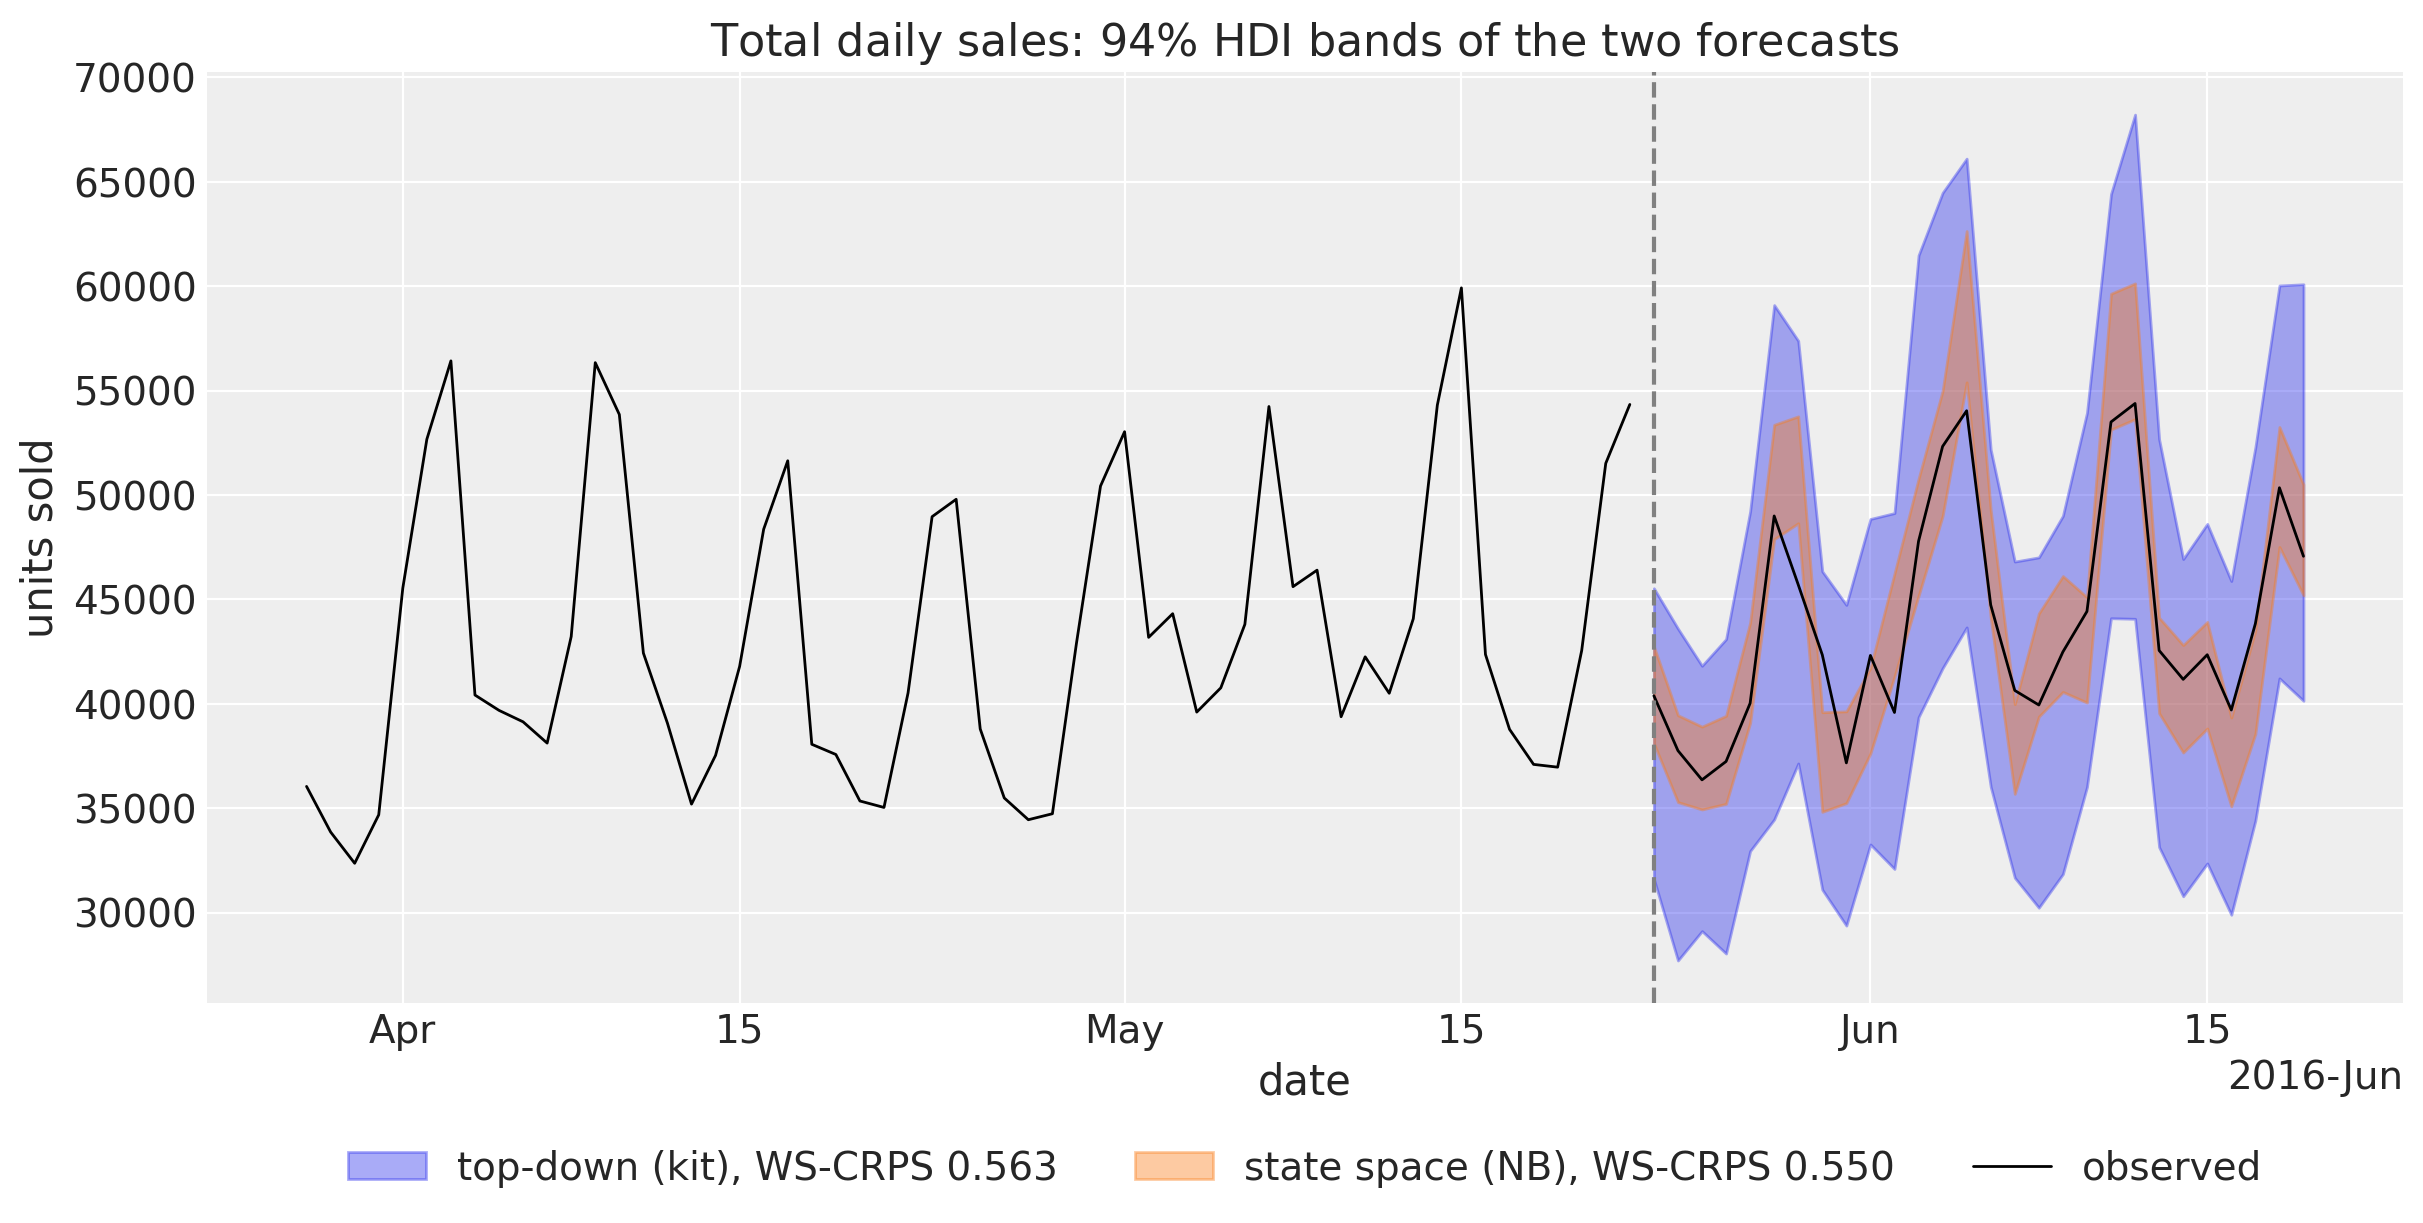

In [34]:
zoom_start = N_DAYS_TRAIN - 8 * 7  # the last eight training weeks
x_hist = date_num[zoom_start:N_DAYS_TRAIN]
x_test = date_num[N_DAYS_TRAIN:N_DAYS]
y_total = sales_agg[:, 0]

fig, ax = plt.subplots(figsize=(12, 6))

for k, (name, draws) in enumerate(
    [("top-down (kit)", level1_top), ("state space (NB)", level1_final)]
):
    hdi = az.hdi(draws.T, prob=0.94)
    ax.fill_between(
        x_test,
        hdi[:, 0],
        hdi[:, 1],
        color=f"C{k}",
        alpha=0.4,
        label=f"{name}, WS-CRPS {ws_crps_mean(scores[name][0]):.3f}",
    )

ax.plot(x_hist, y_total[zoom_start:N_DAYS_TRAIN], color="black", lw=1, label="observed")
ax.plot(x_test, y_total[N_DAYS_TRAIN:N_DAYS], color="black", lw=1)
ax.axvline(split_date, color="gray", ls="--")
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncols=3)
ax.set(
    title=rf"Total daily sales: {hdi_label(0.94)} bands of the two forecasts",
    xlabel="date",
    ylabel="units sold",
);

At the total level both bands follow the observed weekly pattern; the difference is their width. The top-down band is the StudentT noise of a single series fitted over five years, wide enough to hold every day with room to spare. The state space band is the sum of 30,490 negative binomial draws whose only common components are the store shocks and the block innovations, and it is too narrow: the observed total leaves it on the first days of the window and around the mid-June peak. A proper score rewards a narrow band only when it is right, and on this window the observed total sits far enough from the center of the narrow band for the wide band to win the level-1 CRPS by 0.03. A user of the total-level forecast should read the state space model's $94\%$ band as something closer to a $75\%$ band until a total-level shock is added.

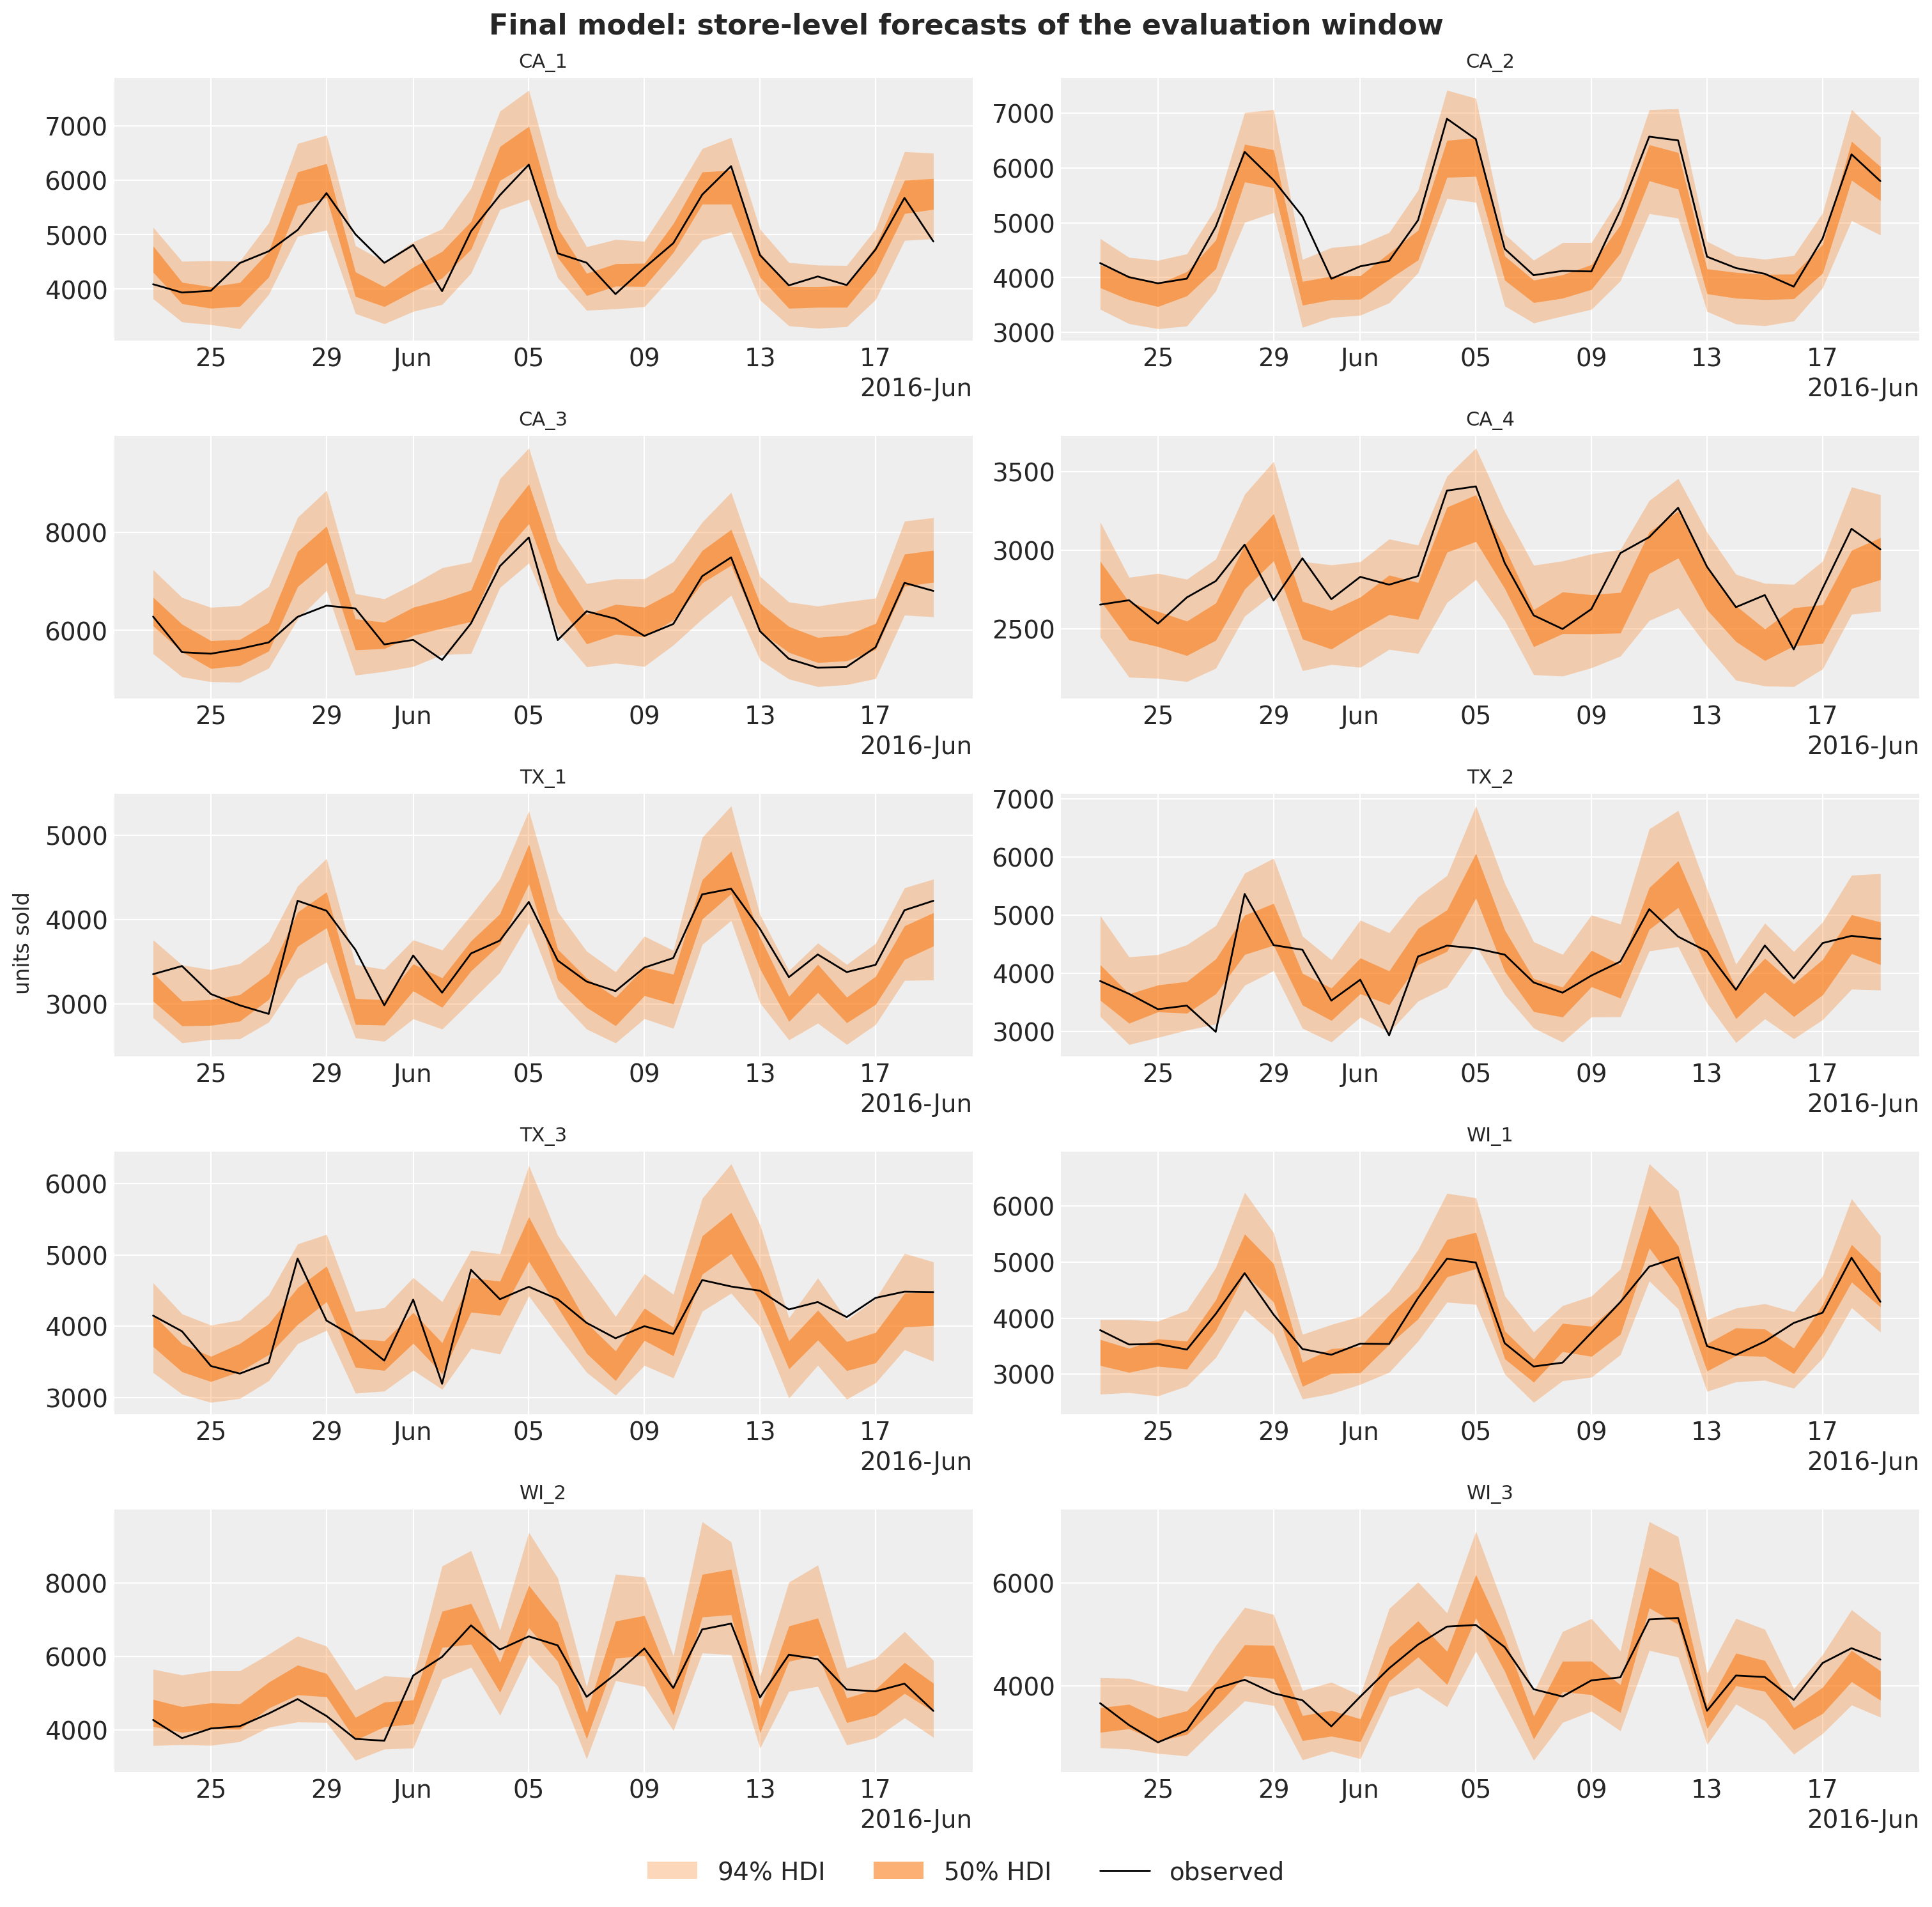

In [35]:
plot_series_panel(
    None,
    level3_final,
    sales_agg[N_DAYS_TRAIN:N_DAYS, level_slices["Level3"]],
    store_ids,
    date_num[plot_start:N_DAYS_TRAIN],
    date_num[N_DAYS_TRAIN:N_DAYS],
    ylabel="units sold",
    suptitle="Final model: store-level forecasts of the evaluation window",
    figsize=(15.0, 14.0),
)

At the store level the bands are calibrated, which the coverage of 0.95 at level 3 confirms: the weekly store shocks give the sum of a store's items the common day-to-day variation that a sum of independent item draws lacks (compare the narrow store bands of the kit's bottom-up model in the baselines notebook), and the fresh future weeks widen the forecast bands by the right amount. WI_2 is the store with the strongest SNAP effects, and the rise of its sales in the first half of June, the SNAP days of Wisconsin, is in the forecast because the calendar is known in advance.

## Cost

The state space model costs about two and a half minutes per window on a 14-core M4 Pro CPU: 110 seconds for 3,000 SVI steps over 1,500-series minibatches of two years of daily data (the number a full-batch model of 30,490 series would not reach) and 25 to 40 seconds to draw 250 to 500 bottom-level forecasts, against about ten seconds for the top-down model. The figure compares the wall times of a fit plus forecast on a backtest window (mean over the three) and on the evaluation window. The whole notebook runs in about 12 minutes.

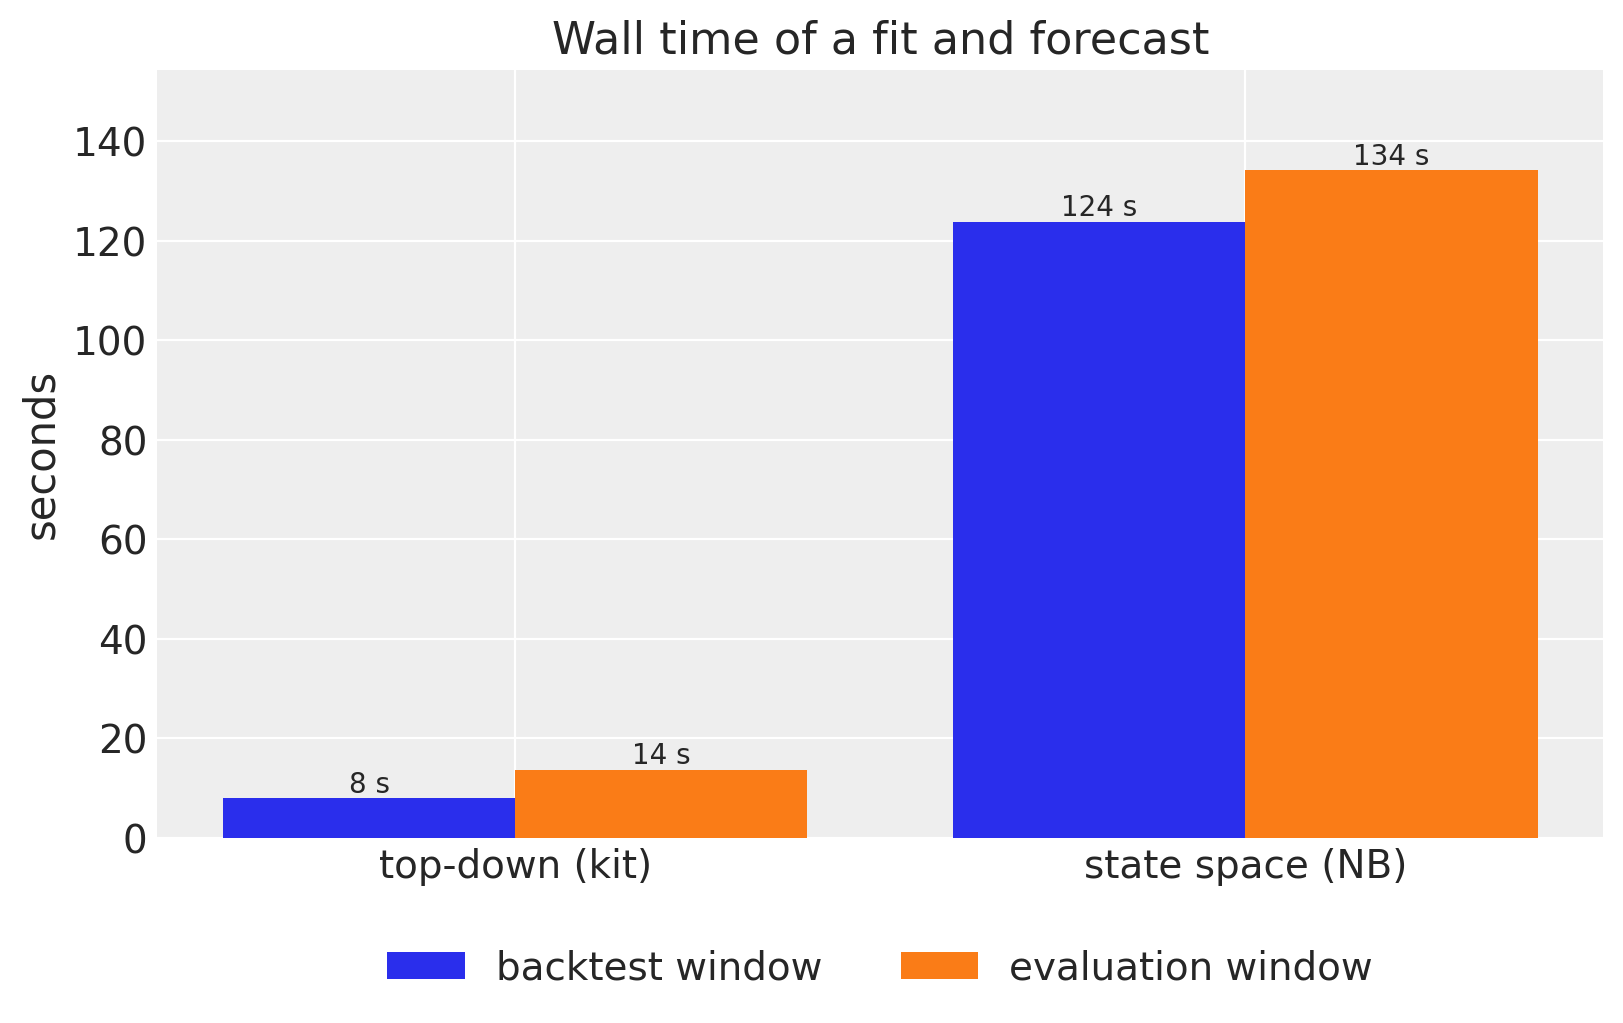

In [36]:
timing = pl.DataFrame(
    {
        "model": MODELS,
        "backtest window": [
            backtest_df.filter(pl.col("model").eq(pl.lit(name)))["walltime"].mean()
            for name in MODELS
        ],
        "evaluation window": [time_top_fc, time_final + time_fc_final],
    }
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(MODELS))
width = 0.4

for k, column in enumerate(["backtest window", "evaluation window"]):
    bars = ax.bar(x + (k - 0.5) * width, timing[column].to_numpy(), width, label=column)
    ax.bar_label(bars, fmt="%.0f s", fontsize=10)

ax.set_xticks(x, MODELS)
ax.set(title="Wall time of a fit and forecast", ylabel="seconds")
ax.margins(y=0.15)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncols=2);

## Discussion

The result is a single hierarchical model of all 30,490 M5 series that beats the best starter-kit baseline by about $10\%$ in WS-CRPS on each of the three backtest windows, is ahead on the evaluation window (0.550 against 0.563, where the baseline draws a favorable SVI seed), improves the competition's pinball loss from 0.195 to 0.188 and, unlike the baseline, carries calibrated uncertainty at the store and store-department levels. It does so with plain NumPyro and the `numpyro_forecast` building blocks: `Horizon.from_data` and `predict()` for the train-and-forecast bookkeeping, explicit block and week plates for the state space components, `AutoNormal` with `create_plates` and `numpyro.subsample` for the minibatching, `backtest()` with a `transform` and `per_window_metrics` for the hierarchy-wide score, and `forecast()`, `predict_in_sample()` and `predictions_to_datatree()` for the plots.

What the model selection and the backtest say about modeling this kind of data:

- **The level process is the model.** Centering the intercepts on the last-28-day level and letting an end-anchored block walk explain the past is what makes 30,490 independent item models competitive; every other component is a refinement. The block resolution matters: daily item walks and daily shared walks were tried during development and lost to the baseline, because a mean-field SVI fit lets a daily latent absorb noise as level and then projects it over the horizon.
- **Common shocks are for calibration, not for the score.** The weekly store shocks leave the CRPS unchanged and move the store-level $94\%$ coverage from 0.70 to 0.95. A score that mixes twelve levels does not reward them much; a user of store-level forecasts does.
- **Level 1 is still too narrow.** The total of the M5 data has day-to-day variation that is neither an item's nor a store's; a state-level or total-level shock (or a non-mean-field guide over the origin levels) is the next component to try, and the coverage metric is the way to judge it.
- **The item levels are where the baseline holds.** A share of a well-fitted total with Poisson noise is a strong item forecast for the competition's weights, which put $23\%$ of the level-12 weight on the 7,772 series that sold on fewer than one day in five of the last training year; a hurdle or zero-inflated likelihood for those series is the other open item.

Two fairness notes. The model uses the `saled` flag over the horizon, that is, it knows which items are listed during the evaluation days, as the kit models do through their shares; and the calendar (weekdays, SNAP days, events) is known in advance, so nothing else leaks.

## References

- [Pyro M5 Starter Kit](https://github.com/pyro-ppl/Pyro-M5-Starter-Kit): the three baseline models and the WS-CRPS harness ported in the [M5 baselines notebook](m5_forecasting.html).
- [Makridakis, Spiliotis and Assimakopoulos (2022), *The M5 uncertainty competition: results, findings and conclusions*](https://doi.org/10.1016/j.ijforecast.2021.10.009), for the WSPL metric and the competition results.
- [NumPyro: stochastic variational inference with subsampling](https://num.pyro.ai/en/stable/svi.html), the `subsample` and `create_plates` mechanics used here.